# TFG: Emerging Competitor Detection Model
## 1. Environment Setup
This section initializes the environment by importing the necessary Python libraries.

In [1]:
import redshift_connector
import pandas as pd
import numpy as np
import getpass
import warnings
import unicodedata
import difflib
import matplotlib.pyplot as plt
from math import sqrt
import math
import seaborn as sns
from scipy.stats import linregress
import re
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.outliers_influence import OLSInfluence
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings('ignore') 
pd.set_option('display.max_columns', None) 

## 2. Data Reading 
A sample of the `fact_opportunity_eu_kyr` table is retrieved to verify the schema and identify the necessary column names.

In [2]:
file_path = r'/Users/chiarabugallaolive/Documents/TFG/tfg_data.csv'

df1 = pd.read_csv(file_path, sep=';', encoding='utf-8-sig')

print(f"{df1.shape[0]} rows and {df1.shape[1]} columns have been loaded.")

1433199 rows and 118 columns have been loaded.


## 3. Data Extraction
We select the relevant fields for competitive analysis. The query filters for lost opportunities and excludes records without a designated competitor. 

In [3]:
df1 = df1[[
    'id_', 
    'opp_line_id_', 
    'close_date', 
    'close_month',
    'close_date_quarter',
    'close_date_year',
    'close_date_quarter_year',
    'close_prev_year',
    'std_oplin_status', 
    'winner_name',
    'comp_name',
    'comp_other_name',
    'opp_market_segment_label',
    'pm0_plcode_label', 
    'plg_top_bu_label',
    'plg_division_label',
    'zone', 
    'reason', 
    'customer_classification',
    'opp_country_destination_label',
    'std_line_amount',
    'won_amount',
    'won_amount_ytd',
    'won_amount_pytd',
    'lost_amount',
    'lost_amount_ytd',
    'lost_amount_pytd'
]]

# Rename Columns 
df1 = df1.rename(columns={
    'std_oplin_status': 'status',
    'winner_name': 'winner',
    'comp_name': 'competitor',
    'comp_other_name': 'other_competitor',
    'opp_market_segment_label': 'market_segment',
    'pm0_plcode_label': 'product_line',
    'plg_top_bu_label': 'business_unit',
    'plg_division_label': 'division',
    'opp_country_destination_label': 'country',
    'std_line_amount': 'total_amount'
})

display(df1.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433199 entries, 0 to 1433198
Data columns (total 27 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   id_                      1433199 non-null  object 
 1   opp_line_id_             1433199 non-null  object 
 2   close_date               1433199 non-null  object 
 3   close_month              1433199 non-null  object 
 4   close_date_quarter       1433199 non-null  object 
 5   close_date_year          1433199 non-null  int64  
 6   close_date_quarter_year  1433199 non-null  object 
 7   close_prev_year          1433199 non-null  object 
 8   status                   1433199 non-null  object 
 9   winner                   831735 non-null   object 
 10  competitor               318877 non-null   object 
 11  other_competitor         26044 non-null    object 
 12  market_segment           1433199 non-null  object 
 13  product_line             1431464 non-null 

None

## 4. Data Cleaning
In this section, the raw data is transformed into a consistent format.

### 4.1. Data Type Optimization & Time Features
We extract time variables directly from the datetime column, and convert text columns into 'category' types.

In [4]:
df_clean = df1.copy()

df_clean['close_date'] = pd.to_datetime(df_clean['close_date']) 
df_clean['close_prev_year'] = pd.to_datetime(df_clean['close_prev_year'])

df_clean['close_date_year'] = df_clean['close_date_year'].astype(str)

df_clean['close_month'] = df_clean['close_date'].dt.month_name()

months_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

df_clean['close_month'] = pd.Categorical(
    df_clean['close_month'],
    categories=months_order,
    ordered=True
)

cols_to_category = [
    'status', 'market_segment', 'zone', 'customer_classification',
    'country', 'reason', 'close_date_quarter', 'close_date_quarter_year', 'close_date_year'
]

for col in cols_to_category:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

object_cols = df_clean.select_dtypes(include=['object']).columns
for col in object_cols:
    df_clean[col] = df_clean[col].astype('string')

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433199 entries, 0 to 1433198
Data columns (total 27 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   id_                      1433199 non-null  string        
 1   opp_line_id_             1433199 non-null  string        
 2   close_date               1433199 non-null  datetime64[ns]
 3   close_month              1433199 non-null  category      
 4   close_date_quarter       1433199 non-null  category      
 5   close_date_year          1433199 non-null  category      
 6   close_date_quarter_year  1433199 non-null  category      
 7   close_prev_year          1433199 non-null  datetime64[ns]
 8   status                   1433199 non-null  category      
 9   winner                   831735 non-null   string        
 10  competitor               318877 non-null   string        
 11  other_competitor         26044 non-null    string        
 12  

### 4.2. Text Normalization and Cleaning
We convert all categorical text to uppercase, removes hidden blank spaces, and replaces text-based "NAN"s with actual mathematical nulls to ensure perfect data consistency.

In [ ]:
# Text Normalization

text_cols = [
    'status', 'winner', 'competitor', 'other_competitor',
    'market_segment', 'product_line', 'business_unit',
    'division', 'zone', 'reason', 'customer_classification', 'country'
]

def normalize_text(s):
    if s is None or pd.isna(s):
        return np.nan
    s = str(s).upper().strip()
    s = unicodedata.normalize('NFKD', s).encode('ASCII', 'ignore').decode('utf-8')
    s = " ".join(s.split())  
    return s

for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(normalize_text)

# Detect Similar Competitor Names 

def find_similar_pairs(series, threshold=0.85):
    vals = list(series.dropna().unique())
    similar_pairs = []
    for i in range(len(vals)):
        for j in range(i+1, len(vals)):
            sim = difflib.SequenceMatcher(None, vals[i], vals[j]).ratio()
            if sim >= threshold:
                similar_pairs.append((vals[i], vals[j], sim))
    return similar_pairs

print("\n Similar competitor names detected (similarity ≥ 0.85)")
similar_pairs = find_similar_pairs(df_clean["competitor"], threshold=0.85)

for a, b, sim in similar_pairs:
    print(f"{a}  <-->  {b}   | similarity={sim:.2f}")

# Manual Correction Mapping 

manual_mapping = {
    "******": "******",
    "******": "******",
    "******": "******",
    "******": "******",
    "******": "******",
    "******": "******",
    "******": "******",
    "******": "******",
    "******": "******"
}

print("\n Manual mapping applied (normalizing competitor names)")
for k, v in manual_mapping.items():
    print(f"{k}  →  {v}")

# Apply Mapping To Competitor Columns

cols_to_fix = ["competitor", "other_competitor"]

for col in cols_to_fix:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace(manual_mapping)

print("\n Final sample of unique competitor names")
print(df_clean["competitor"].dropna().unique()[:20])

print("\nTotal unique competitors AFTER cleaning:")
print(df_clean["competitor"].nunique())

### 4.3. Competitor Name Unification
The competitor name is unified by prioritizing the manually entered name when the standard field is marked as 'OTHER'.

In [ ]:
df_clean['final_competitor'] = df_clean.apply(lambda x: x['other_competitor'] if x['competitor'] == 'OTHER' else x['competitor'], axis=1)

print(df_clean[df_clean['competitor'] == 'OTHER'][['competitor', 'other_competitor', 'final_competitor']].head())

### 4.4. Finding Duplicates
First thing to do is to drop rows that are exact duplicates across all columns.

In [7]:
key_columns = ['id_', 'opp_line_id_', 'final_competitor']

# Counting duplicates
duplicates_before = df_clean.duplicated(subset=key_columns, keep=False).sum()
print(f"Duplicates found BEFORE cleaning: {duplicates_before}")

# Drop the duplicates
if duplicates_before > 0:
    df_clean = df_clean.drop_duplicates(subset=key_columns, keep='last')
    print("Duplicates successfully removed.")
else:
    print("No duplicates needed to be removed.")

duplicates_after = df_clean.duplicated(subset=key_columns, keep=False).sum()
print(f"Duplicates remaining AFTER cleaning: {duplicates_after}")
print(f"Total rows in df_clean now: {len(df_clean)}")

Duplicates found BEFORE cleaning: 236
Duplicates successfully removed.
Duplicates remaining AFTER cleaning: 0
Total rows in df_clean now: 1433081


### 4.5. Finding Missings Values 
Analyzes the presence and distribution of missing values (NaNs) across the dataset to understand their patterns before applying any treatment strategy.

In [8]:
# Removing the columns
df_clean = df_clean.drop(columns=['competitor', 'other_competitor'])

# Rename 
df_clean = df_clean.rename(columns={'final_competitor': 'competitor'})

print("Does the dataset contain any missing values?")
print(df_clean.isna().any().any())

print("\n Total number of missing values in the dataset:")
print(df_clean.isna().sum().sum())

print("\n Percentage of missing values in the dataset:")
print(df_clean.isna().mean().mean())

print("\n Missing values per column (count):")
display(df_clean.isna().sum().sort_values(ascending=False))

print("\n Missing values per column (%):")
display((df_clean.isna().mean().sort_values(ascending=False) * 100).round(2).astype(str) + "%")

Does the dataset contain any missing values?
True

 Total number of missing values in the dataset:
2001772

 Percentage of missing values in the dataset:
0.053724270134926616

 Missing values per column (count):


competitor                 1114360
winner                      601457
reason                      280750
business_unit                 1735
product_line                  1735
division                      1735
close_date_quarter_year          0
close_prev_year                  0
lost_amount_pytd                 0
lost_amount_ytd                  0
lost_amount                      0
won_amount_pytd                  0
won_amount_ytd                   0
won_amount                       0
total_amount                     0
country                          0
customer_classification          0
close_date                       0
zone                             0
opp_line_id_                     0
close_month                      0
close_date_quarter               0
market_segment                   0
close_date_year                  0
status                           0
id_                              0
dtype: int64


 Missing values per column (%):


competitor                 77.76%
winner                     41.97%
reason                     19.59%
business_unit               0.12%
product_line                0.12%
division                    0.12%
close_date_quarter_year      0.0%
close_prev_year              0.0%
lost_amount_pytd             0.0%
lost_amount_ytd              0.0%
lost_amount                  0.0%
won_amount_pytd              0.0%
won_amount_ytd               0.0%
won_amount                   0.0%
total_amount                 0.0%
country                      0.0%
customer_classification      0.0%
close_date                   0.0%
zone                         0.0%
opp_line_id_                 0.0%
close_month                  0.0%
close_date_quarter           0.0%
market_segment               0.0%
close_date_year              0.0%
status                       0.0%
id_                          0.0%
dtype: object

## 5. Business Logic & Filtering
Filters the dataset based on business rules to isolate relevant records.

### 5.1. Business Logic Anomaly Detection
Scans the dataset for human data-entry errors and business logic contradictions.

In [ ]:
# Lost Opportunities with Won Amount > 0
anomalies_lost = df_clean[(df_clean['status'] == 'LOST') & (df_clean['won_amount'] > 0)]
print(f"1. Anomalies (Status LOST with won_amount > 0): {len(anomalies_lost)} rows")

# Won Opportunities with Total Amount = 0
anomalies_won = df_clean[(df_clean['status'] == 'WON') & (df_clean['total_amount'] == 0)]
print(f"2. Anomalies (Status WON with total_amount = 0): {len(anomalies_won)} rows")

# Lost Opportunities with Total Amount = 0
anomalies_lost = df_clean[(df_clean['status'] == 'LOST') & (df_clean['total_amount'] == 0)]
print(f"3. Anomalies (Status LOST with total_amount = 0): {len(anomalies_lost)} rows")

# Negative amounts 
anomalies_negative = df_clean[(df_clean['total_amount'] < 0) | (df_clean['won_amount'] < 0)]
print(f"4. Anomalies (Negative financial amounts): {len(anomalies_negative)} rows")

if len(anomalies_won) > 0:
    print("Here is a sample of 5 rows to investigate:")
    display(anomalies_won[['id_', 'status', 'total_amount', 'won_amount', 'reason', 'product_line', 'competitor']].head())

if len(anomalies_lost) > 0:
    print("Here is a sample of 5 rows to investigate:")
    display(anomalies_lost[['id_', 'status', 'total_amount', 'lost_amount', 'reason', 'product_line', 'competitor']].head())

# Dropping the anomalies 
df_clean = df_clean.drop(anomalies_won.index)    
print(f"{len(anomalies_won)} anomalous rows dropped.")

df_clean = df_clean.drop(anomalies_lost.index)    
print(f"{len(anomalies_lost)} anomalous rows dropped.")

### 5.2. Removing Not Specified Competitors
Filters out rows where the 'competitor' or 'winner' is unknown.

In [10]:
# Define the search patterns 
pattern_ghosts = r"unknown|other|descon|identif|shared|know|info|hay dato|especifica|n/a|n/d|n\.n\.|n\.c\.|none|ningun|aucun|no competi.*|no hay competi.*|sin competi.*|sabe|otra.* causa.*|lugar|haran|mention|comment|disclose"
pattern_symbols = r"[\?\.\-\/]+" 
pattern_schneider = r"schneider|(?:\bse\b)"

combined_pattern = f"({pattern_ghosts}|{pattern_symbols}|{pattern_schneider})"

rows_before = len(df_clean)

# Apply cleaning to both columns
mask_competitor = df_clean['competitor'].astype(str).str.contains(combined_pattern, case=False, na=False, regex=True)
mask_winner = df_clean['winner'].astype(str).str.contains(combined_pattern, case=False, na=False, regex=True)

df_clean = df_clean[~(mask_competitor | mask_winner)]

rows_after = len(df_clean)
dropped = rows_before - rows_after

print(f"Rows dropped: {dropped}")
print(f"Remaining rows: {rows_after}")

Rows dropped: 715293
Remaining rows: 680693


### 5.3. Reason Grouping
Multiple detailed reasons are grouped into new categories.

In [11]:
reason_mapping = {
    # Pricing
    'PRICING': 'PRICING ISSUE',
    'PRICING ISSUE': 'PRICING ISSUE',

    # Customer Issues
    'CUSTOMER BUDGET ISSUE': 'CUSTOMER ISSUE',
    'CUSTOMER CHANGED MIND AND PROJECT CANCELLED': 'CUSTOMER ISSUE',
    'CUSTOMER RESOURCE ISSUE': 'CUSTOMER ISSUE',
    'ABILITY TO DELIVER': 'CUSTOMER ISSUE',
    'COMPANY CLOSED/RELATIONSHIP TERMINATED': 'CUSTOMER ISSUE',

    # SE Internal Issues
    'SE RESOURCE ISSUE': 'SE INTERNAL ISSUE',
    'NO ACTION ON LEAD': 'SE INTERNAL ISSUE',
    'OPEN CASE/ISSUE NOT RESOLVED': 'SE INTERNAL ISSUE',
    'DELAY IN QUOTE SUBMISSION': 'SE INTERNAL ISSUE',
    'SERVICE EXECUTION ISSUE': 'SE INTERNAL ISSUE',
    'NO ACCEPTABLE OFFER FROM SE': 'SE INTERNAL ISSUE',
    'SOLUTION/OFFER FROM SE': 'SE INTERNAL ISSUE',
    'NO REAL OPPORTUNITY / OUT OF SE STRATEGY': 'SE INTERNAL ISSUE',

    # Relationship
    'RELATIONSHIP ISSUE WITH SE': 'RELATIONSHIP ISSUE',
    'RELATIONSHIP WITH PARTNER': 'RELATIONSHIP ISSUE',
    'RELATIONSHIP WITH SE': 'RELATIONSHIP ISSUE',

    # Technical / Asset
    'ASSET ISSUE - ASSET MOVED FROM LOCATION': 'TECHNICAL ISSUE',
    'ASSET ISSUE - WRONG LIFECYCLE STATUS': 'TECHNICAL ISSUE',
    'PRODUCT NO LONGER AVAILABLE': 'TECHNICAL ISSUE',

    # Project Status / No Go
    'NO BID DECISION (S1)': 'NO GO / PROJECT STOPPED',
    'NO GO DECISION (S0)': 'NO GO / PROJECT STOPPED',
    'MULTIYEAR SERVICE CONTRACT RENEWAL NOT DUE': 'NO GO / PROJECT STOPPED',
    'RECURRING CONTRACT': 'NO GO / PROJECT STOPPED',
    'REPLACED WITH MASTER PROJECT': 'NO GO / PROJECT STOPPED',

    # Supply
    'SUPPLY CONSTRAINT': 'SUPPLY ISSUE',
    'COVID19': 'SUPPLY ISSUE',

    # Contract
    'T&C ISSUE': 'CONTRACT ISSUE',

    # Not Specified
    'NOT SPECIFIED': 'NOT SPECIFIED',
    'nan': 'NOT SPECIFIED', 
    
    'DUPLICATE': 'OTHER', 
    'RELATIONSHIP - OTHER': 'RELATIONSHIP ISSUE' 
}

# Convert to string 
df_clean["reason"] = df_clean["reason"].astype(str)

# Apply reason mapping 
df_clean["reason_grouped"] = df_clean["reason"].replace(reason_mapping)

print(df_clean[["reason", "reason_grouped"]].head(10))
print(df_clean["reason_grouped"].value_counts())

                         reason     reason_grouped
0         CUSTOMER BUDGET ISSUE     CUSTOMER ISSUE
1         CUSTOMER BUDGET ISSUE     CUSTOMER ISSUE
2         CUSTOMER BUDGET ISSUE     CUSTOMER ISSUE
3         CUSTOMER BUDGET ISSUE     CUSTOMER ISSUE
4         CUSTOMER BUDGET ISSUE     CUSTOMER ISSUE
5         CUSTOMER BUDGET ISSUE     CUSTOMER ISSUE
6         CUSTOMER BUDGET ISSUE     CUSTOMER ISSUE
7         CUSTOMER BUDGET ISSUE     CUSTOMER ISSUE
25  NO ACCEPTABLE OFFER FROM SE  SE INTERNAL ISSUE
26  NO ACCEPTABLE OFFER FROM SE  SE INTERNAL ISSUE
reason_grouped
CUSTOMER ISSUE             201991
SE INTERNAL ISSUE          148307
PRICING ISSUE              123786
COURTESY OFFER              96080
NO GO / PROJECT STOPPED     52109
RELATIONSHIP ISSUE          23159
NOT SPECIFIED               12637
TECHNICAL ISSUE             10500
CONTRACT ISSUE               8869
SUPPLY ISSUE                 3185
OTHER                          69
PROJECT CANCELLED               1
Name: count, dty

### 5.4. Filtering Target Opportunities
Filters the dataset to keep exclusively 'LOST' opportunities and removes redundant columns that no longer add analytical value.

In [12]:
# Keep only the target 'LOST' opportunities
df_clean = df_clean[df_clean['status'] == 'LOST']

# Drop columns 
cols_to_drop = ['status', 'won_amount', 'won_amount_ytd', 'won_amount_pytd', 'total_amount','winner']
df_clean = df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns])

print(f"Dataset successfully filtered. Remaining target rows: {len(df_clean)}")
print(f"Current columns: {df_clean.columns.tolist()}")

Dataset successfully filtered. Remaining target rows: 214769
Current columns: ['id_', 'opp_line_id_', 'close_date', 'close_month', 'close_date_quarter', 'close_date_year', 'close_date_quarter_year', 'close_prev_year', 'market_segment', 'product_line', 'business_unit', 'division', 'zone', 'reason', 'customer_classification', 'country', 'lost_amount', 'lost_amount_ytd', 'lost_amount_pytd', 'competitor', 'reason_grouped']


### 5.5. Anonymizing competitors 
To comply with corporate confidentiality policies, the real names of the competing companies have been anonymized.

In [13]:
real_competitors = df_clean['competitor'].dropna().unique()

anonymization_dict = {
    name: f"Competitor {i+1}" 
    for i, name in enumerate(real_competitors)
}
df_clean['competitor'] = df_clean['competitor'].map(anonymization_dict)

print(f"Successfully anonymized {len(real_competitors)} competitors for EDA.")

Successfully anonymized 621 competitors for EDA.


## 6. Exploratory Data Analysis
Uses visual graphs to spot trends, extreme values (outliers), and competitor behavior in our lost deals.

### 6.1. Univariate Analysis

#### 6.1.1. Numerical Variables 
Analyzes the distribution, central tendencies, and dispersion of continuous variables using statistical summaries, histograms, and boxplots.

##### 6.1.1.1. Lost Amount

In [ ]:
df_clean['lost_amount'].describe()

The lost_amount variable shows a strongly right‑skewed distribution, where most lost opportunities involve relatively low amounts, while a small number of very large losses explain the high maximum and standard deviation.

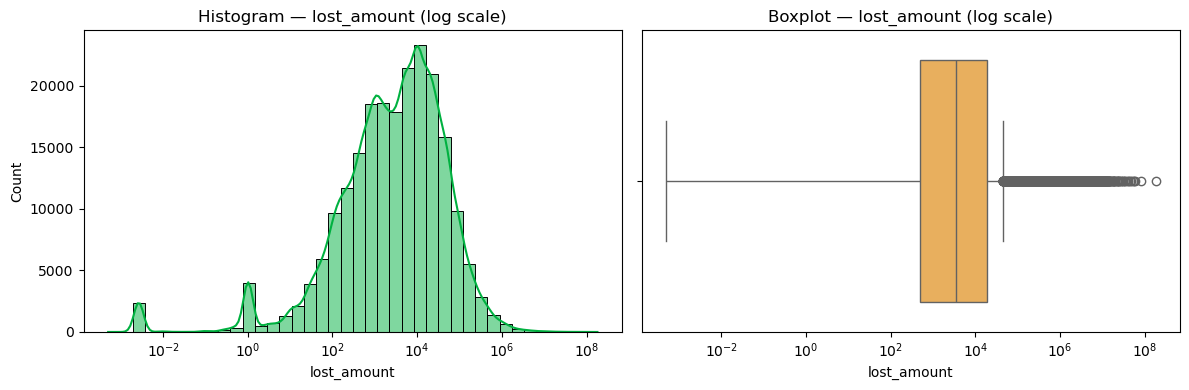

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df_clean["lost_amount"], bins=40, kde=True, ax=axes[0], color="#00B140", log_scale=True)
axes[0].set_title("Histogram — lost_amount (log scale)")
axes[0].set_xlabel("lost_amount")

sns.boxplot(x=df_clean["lost_amount"], ax=axes[1], color="#FFB347")
axes[1].set_xscale("log")
axes[1].set_title("Boxplot — lost_amount (log scale)")

plt.tight_layout()
plt.show()

**Histogram**

The histogram of lost_amount on a logarithmic scale reveals a highly right‑skewed distribution with several distinct peaks. Most observations are concentrated in the lower and mid‑value ranges, while the long right tail reflects the presence of occasional very large losses. This heavy‑tailed pattern is typical for financial variables, where a small number of high‑value cases represent significant business events rather than noise.

**Boxplot**

The log‑scaled boxplot confirms the strong asymmetry in lost_amount, with a compact interquartile range and a substantial number of extreme values on the upper tail. These high‑value points correspond to exceptionally large losses, which should be interpreted as meaningful competitive events rather than statistical anomalies.

##### 6.1.1.2. Lost Amount YTD

In [ ]:
df_clean['lost_amount_ytd'].describe()

The lost_amount_ytd distribution is highly right‑skewed, with the majority of observations equal to zero and only a few records showing very large accumulated losses, which strongly influence the mean and maximum values.

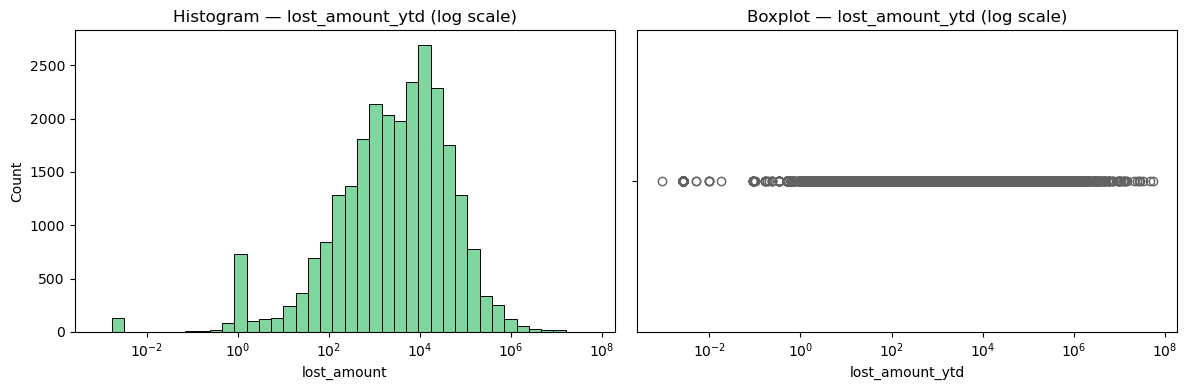

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df_clean["lost_amount_ytd"], bins=40, kde=True, ax=axes[0], color="#00B140", log_scale=True)
axes[0].set_title("Histogram — lost_amount_ytd (log scale)")
axes[0].set_xlabel("lost_amount")

sns.boxplot(x=df_clean["lost_amount_ytd"], ax=axes[1], color="#FFB347")
axes[1].set_xscale("log")
axes[1].set_title("Boxplot — lost_amount_ytd (log scale)")

plt.tight_layout()
plt.show()

**Histogram** 

The distribution of lost_amount_ytd displays a similar right‑skewed structure, with most observations falling between mid‑range values and a pronounced heavy tail of larger losses. The log transformation makes the underlying shape visible, showing a continuous progression rather than a single peak.

**Boxplot**

The boxplot shows an extremely large upper‑tail spread, with a dense cluster of high‑value points. This confirms that lost_amount_ytd contains a considerable number of large one‑off events. In the context of competitive analysis, such cases may correspond to large opportunities lost to dominant or emerging competitors.

##### 6.1.1.3. Lost Amount PYTD

In [ ]:
df_clean['lost_amount_pytd'].describe()

The lost_amount_pytd variable also shows a strongly right‑skewed distribution, with most values equal to zero and only a small number of very large losses explaining the high maximum and standard deviation.

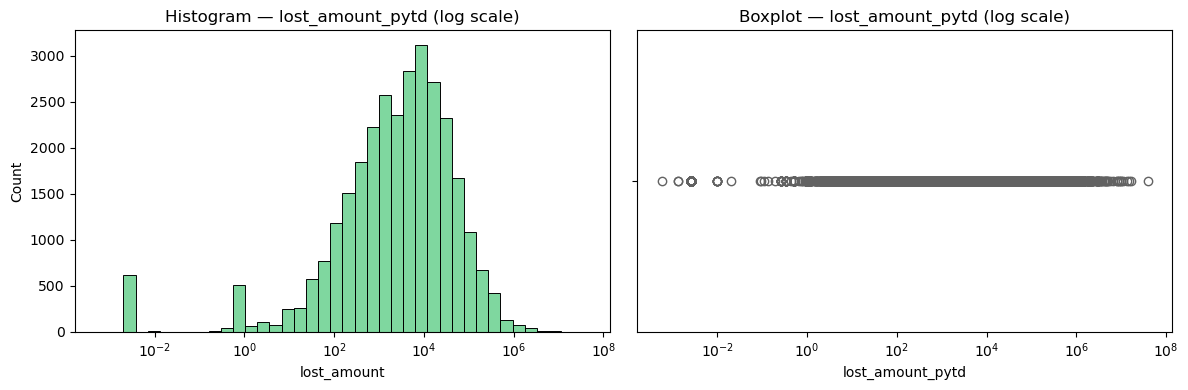

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df_clean["lost_amount_pytd"], bins=40, kde=True, ax=axes[0], color="#00B140", log_scale=True)
axes[0].set_title("Histogram — lost_amount_pytd (log scale)")
axes[0].set_xlabel("lost_amount")

sns.boxplot(x=df_clean["lost_amount_pytd"], ax=axes[1], color="#FFB347")
axes[1].set_xscale("log")
axes[1].set_title("Boxplot — lost_amount_pytd (log scale)")

plt.tight_layout()
plt.show()

**Histogram** 

Lost_amount_pytd presents a heavy‑tailed, positively skewed pattern similar to the current year distribution. The bulk of observations lies in the medium range, but the long right tail indicates persistent high‑value losses across different periods.

**Boxplot**

The log‑scaled boxplot highlights an extensive spread of upper‑tail values, reflecting the recurrence of exceptionally large losses in previous periods. This reinforces the presence of structurally heavy‑tailed behaviour in the dataset, where large losses are rare but strategically significant events.

We can see through the histograms that there are values < 1, we're going to delete them.   

In [ ]:
df_clean[df_clean['lost_amount'] < 1].shape[0]

In [21]:
df_clean[df_clean['lost_amount'] < 1].groupby('country').size().head()

country
ALBANIA    0
ANDORRA    0
ARMENIA    0
AUSTRIA    0
BELGIUM    2
dtype: int64

In [22]:
df_clean = df_clean[df_clean['lost_amount'] >= 100]

#### 6.1.2. Categorical Variables
Analyzes the distribution of qualitative data by generating frequency tables, bar plots, and pie plots to visualize the proportions of each category.

In [23]:
cat_cols = df_clean.select_dtypes(include=['category', 'object']).columns

# Number of categories for each variable
unique_counts = []
for col in cat_cols:
    unique_counts.append({
        'Variable': col,
        'Number of Categories': df_clean[col].nunique()
    })

df_unique_counts = pd.DataFrame(unique_counts)
df_unique_counts = df_unique_counts.sort_values(by='Number of Categories', ascending=False).reset_index(drop=True)

display(df_unique_counts)

,Variable,Number of Categories
0,competitor,612
1,product_line,69
2,customer_classification,67
3,country,48
4,reason,31
5,market_segment,20
6,division,15
7,close_month,12
8,reason_grouped,11
9,close_date_quarter_year,10


In [24]:
cols_to_exclude = ['id_', 'opp_line_id_', 'reason', 'winner', 'close_date']
vertical_cols = ['close_month', 'close_date_year', 'close_date_quarter_year']

cat_cols_clean = [col for col in df_clean.select_dtypes(include=['object', 'category']).columns 
                  if col not in cols_to_exclude]

sns.set_theme(style="whitegrid")

def plot_categorical_clean(col):
    print(f"\n FEATURE: {col.upper()}")
    
    # Calculate relative frequencies
    counts = df_clean[col].value_counts()
    freq_table = pd.DataFrame({
        'Percentage (%)': (df_clean[col].value_counts(normalize=True) * 100).round(2)
    })
    
    # Sort categories
    freq_table = freq_table.sort_index() if col in vertical_cols else freq_table.sort_values(by='Percentage (%)', ascending=False)
    
    unique_cats = df_clean[col].nunique()
    is_vertical = col in vertical_cols 
    cat_labels = freq_table.index.astype(str) 
    
    # Configure relative axis labels
    labels_dict = {
        'xlabel': 'Percentage (%)' if not is_vertical else col,
        'ylabel': col if not is_vertical else 'Percentage (%)'
    }
    
    # Low cardinality distributions
    if unique_cats <= 5:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        if is_vertical:
            sns.barplot(x=cat_labels, y=freq_table['Percentage (%)'], ax=axes[0], palette='viridis')
            axes[0].tick_params(axis='x', rotation=45)
        else:
            sns.barplot(x=freq_table['Percentage (%)'], y=cat_labels, ax=axes[0], palette='viridis')
            
        axes[0].set(title=f'{col} - Distribution', **labels_dict)
        axes[1].pie(counts, labels=cat_labels, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
        axes[1].set_title(f'{col} - Share')
        
    # High cardinality distributions
    else:
        fig, ax = plt.subplots(figsize=(10, 6))
        data_plot = freq_table.head(15) if unique_cats > 20 else freq_table
        labels_plot = data_plot.index.astype(str)
        palette = 'magma' if unique_cats > 20 else 'viridis'
        
        if is_vertical:
            sns.barplot(x=labels_plot, y=data_plot['Percentage (%)'], ax=ax, palette=palette)
            ax.tick_params(axis='x', rotation=45)
        else:
            sns.barplot(x=data_plot['Percentage (%)'], y=labels_plot, ax=ax, palette=palette)
            
        title_text = f'Top 15 {col}' if unique_cats > 20 else f'{col} - All Categories'
        ax.set(title=title_text, **labels_dict)
        
    plt.tight_layout()
    plt.show()

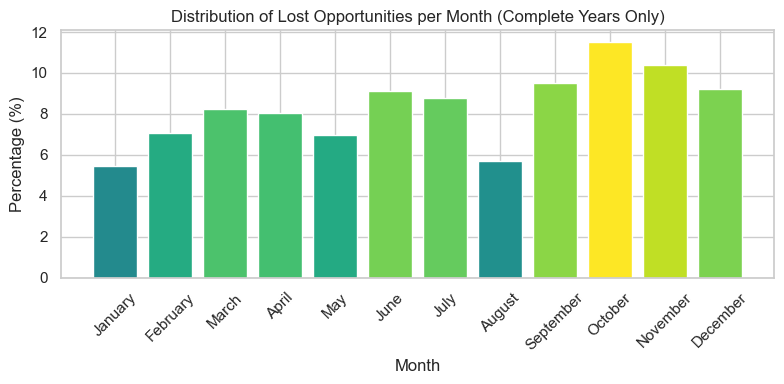

In [25]:
df_clean['close_month'] = df_clean['close_date'].dt.month_name().astype('category')
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

# Filter complete years
months_per_year = df_clean.groupby("close_date_year")["close_month"].nunique()
complete_years = months_per_year[months_per_year == 12].index

if len(complete_years) == 0:
    print("Error.")
else:
    # Compute monthly averages
    monthly_avg = (
        df_clean[df_clean["close_date_year"].isin(complete_years)]
        .groupby(["close_date_year", "close_month"], observed=True)
        .size()
        .reset_index(name="count")
        .groupby("close_month", observed=True)["count"]
        .mean()
        .reindex(month_order)
        .fillna(0)
    )
    
    # Calculate percentage distribution
    monthly_pct = (monthly_avg / monthly_avg.sum()) * 100

    plt.figure(figsize=(8, 4))
    colors = plt.cm.viridis(monthly_pct / monthly_pct.max())
    
    plt.bar(monthly_pct.index.astype(str), monthly_pct.values, color=colors)
    plt.xticks(rotation=45)
    
    plt.title("Distribution of Lost Opportunities per Month (Complete Years Only)")
    plt.xlabel("Month")
    plt.ylabel("Percentage (%)")
    plt.tight_layout()
    plt.show()

This figure shows the average number of lost opportunities per month, computed using only complete years to avoid bias caused by uneven time coverage. The distribution reveals a clear seasonal pattern, with lower activity during the summer months, particularly in August, and higher levels towards the end of the year.


 FEATURE: CLOSE_DATE_YEAR


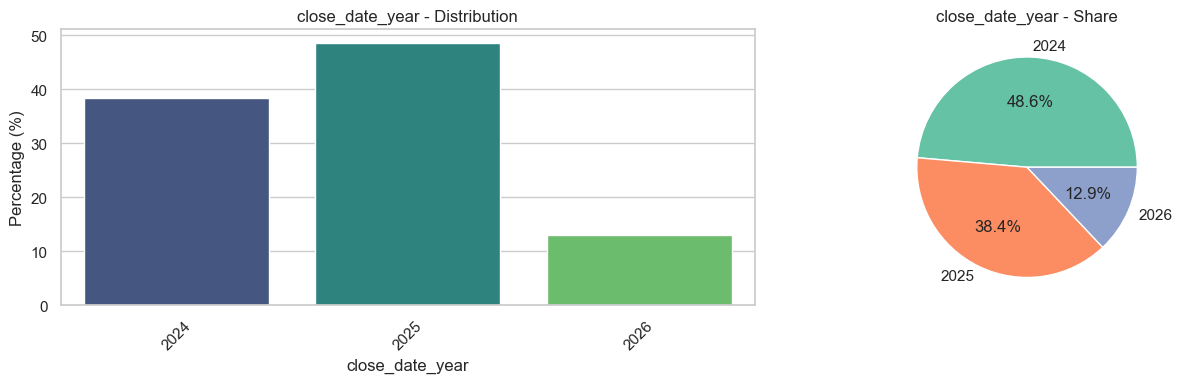

In [26]:
plot_categorical_clean('close_date_year')

The distribution of lost opportunities by year shows that 2025 accounts for the largest share of records, followed by 2024, while 2026 represents a much smaller proportion. This pattern mainly reflects differences in data coverage across years rather than an underlying temporal trend, as the most recent year is only partially observed.


 FEATURE: CLOSE_DATE_QUARTER_YEAR


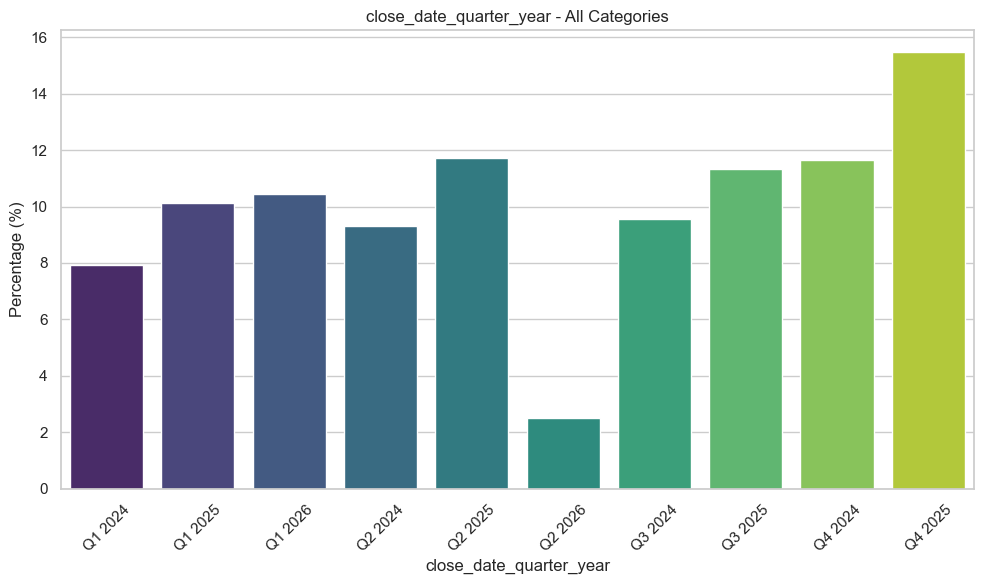

In [27]:
plot_categorical_clean('close_date_quarter_year')

The distribution of lost opportunities by quarter and year shows higher counts in recent quarters, particularly in Q4 2025 and Q2–Q4 2024. However, this pattern is strongly influenced by uneven data coverage, as some quarters are only partially observed, especially in the most recent year.


 FEATURE: MARKET_SEGMENT


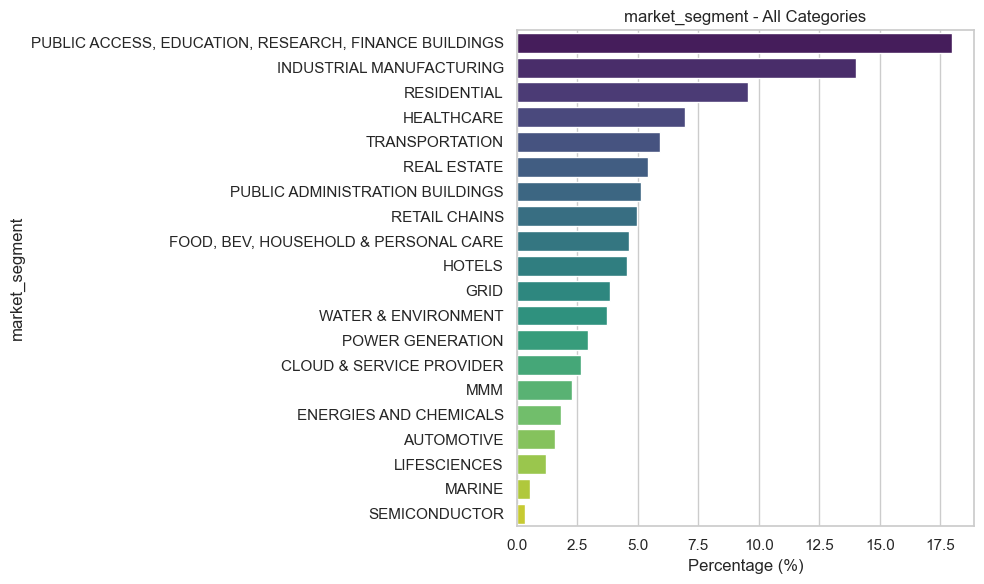

In [28]:
plot_categorical_clean('market_segment')

The distribution of lost opportunities by market segment shows a strong concentration in Public Access, Education, Research and Finance buildings, followed by Industrial Manufacturing and Residential segments. This suggests that competitive pressure is particularly high in large‑scale and public‑oriented projects, while losses in niche segments remain comparatively limited.


 FEATURE: PRODUCT_LINE


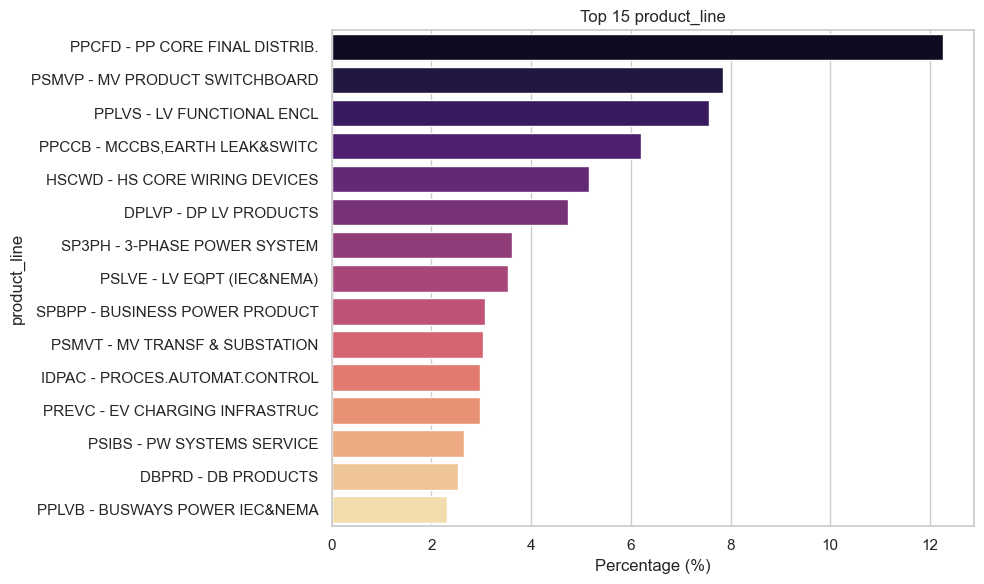

In [29]:
plot_categorical_clean('product_line')

Lost opportunities are highly concentrated in a small number of product lines, with PP Core Final Distribution and LV Functional Enclosures accounting for the highest number of losses. This indicates that competitive pressure is strongest in core power distribution and enclosure products, while losses in other product lines remain more fragmented.


 FEATURE: BUSINESS_UNIT


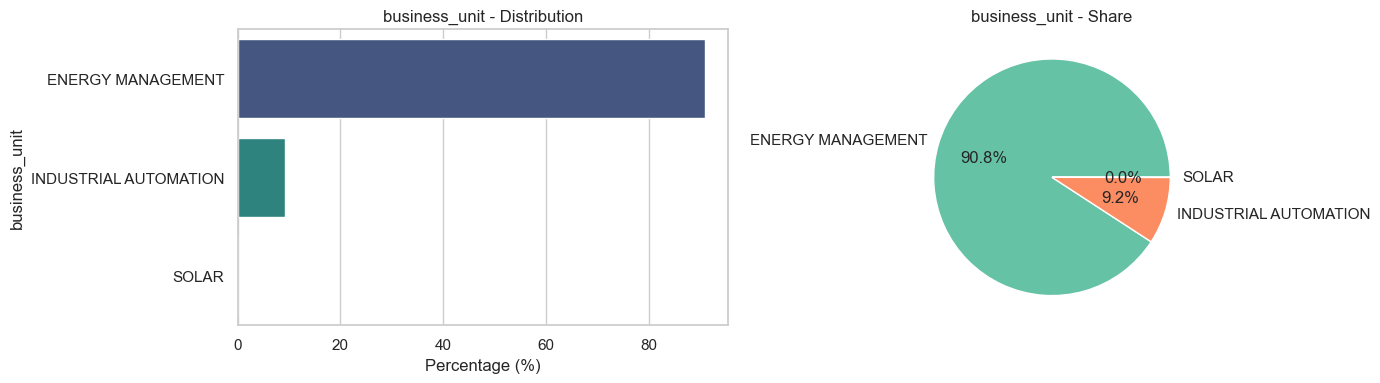

In [30]:
plot_categorical_clean('business_unit')

Lost opportunities are overwhelmingly concentrated in the Energy Management business unit, which accounts for almost 90% of all losses. Industrial Automation represents a much smaller share, while Solar has a negligible impact.


 FEATURE: DIVISION


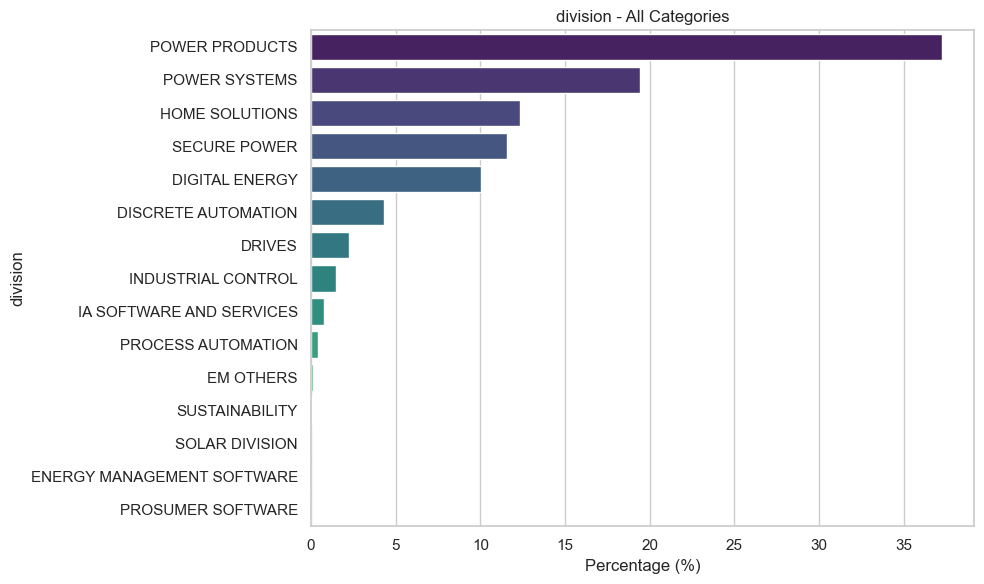

In [31]:
plot_categorical_clean('division')

Most lost opportunities occur in the Power Products and Power Systems divisions, followed by Home Solutions and Secure Power. Losses in the remaining divisions are significantly lower, indicating that competitive pressure is strongest in core power-related activities.


 FEATURE: ZONE


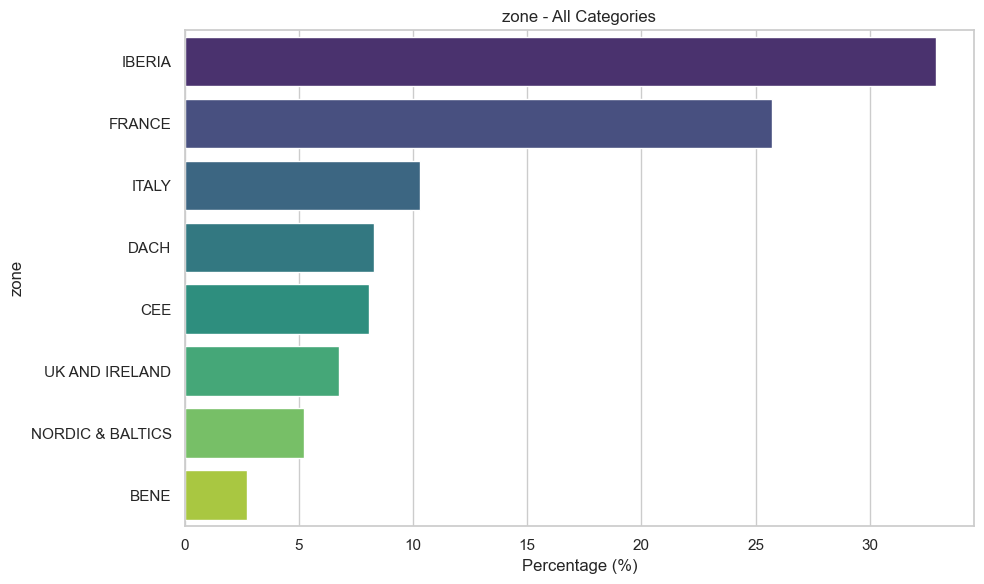

In [32]:
plot_categorical_clean('zone')

Lost opportunities are mainly concentrated in Iberia and France, which together represent the largest share of losses. Other regions show notably lower frequencies, suggesting more limited competitive activity or lower deal volumes.


 FEATURE: CUSTOMER_CLASSIFICATION


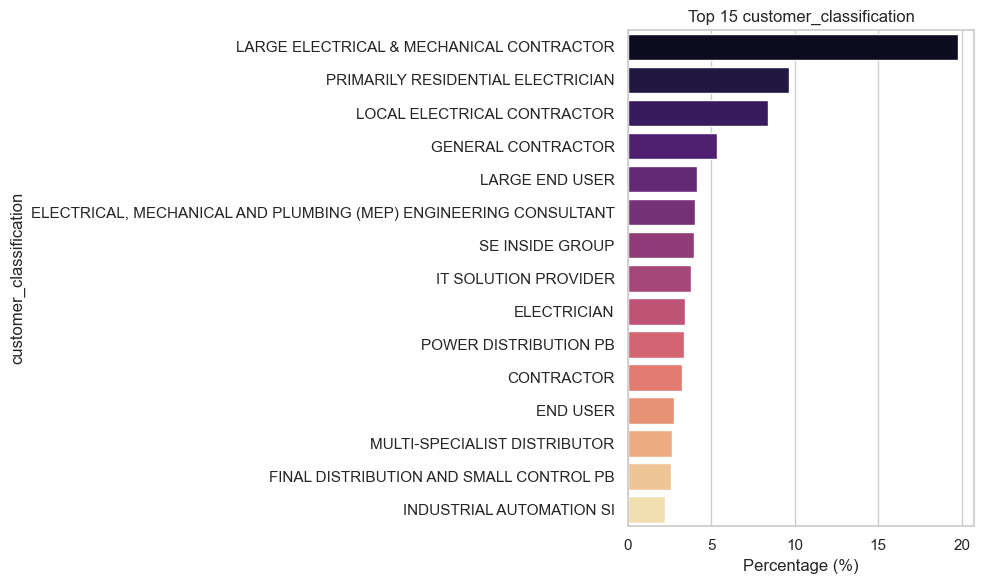

In [33]:
plot_categorical_clean('customer_classification')

The majority of lost opportunities involve large electrical and mechanical contractors, followed by residential electricians and local electrical contractors. This indicates that competitive pressure is highest among professional installers and large contracting customers.


 FEATURE: COUNTRY


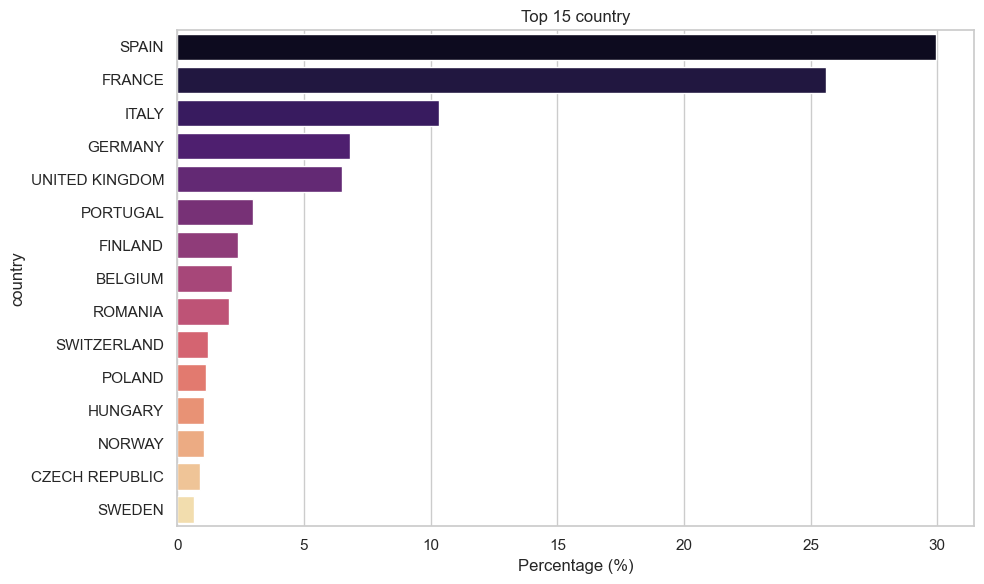

In [34]:
plot_categorical_clean('country')

Lost opportunities are dominated by Spain and France, with a significant gap compared to other countries. Italy, the United Kingdom and Germany form a secondary group, while losses in the remaining countries are relatively limited.


 FEATURE: COMPETITOR


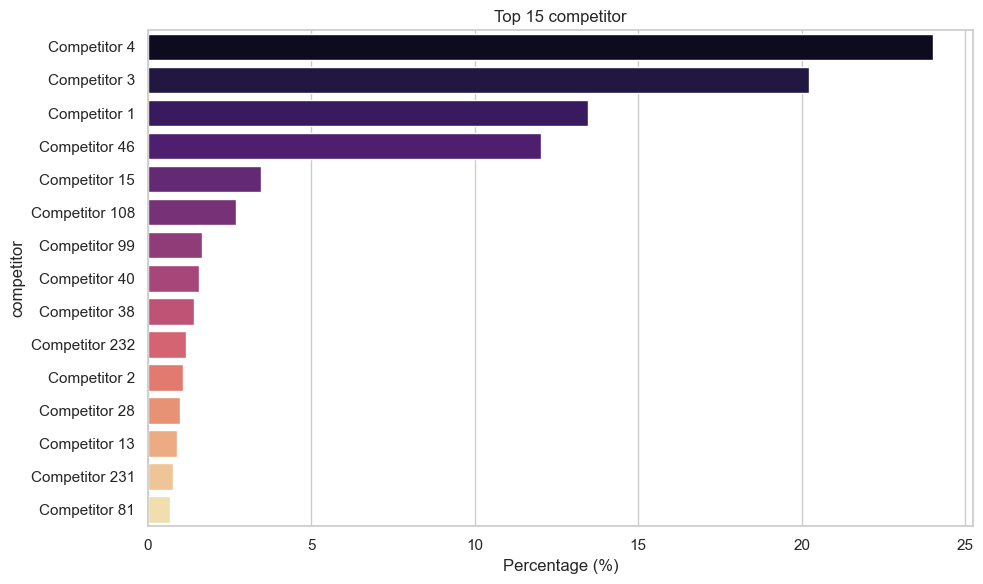

In [35]:
plot_categorical_clean('competitor')

Lost opportunities are mainly driven by a small group of major competitors. Other competitors appear less frequently.


 FEATURE: REASON_GROUPED


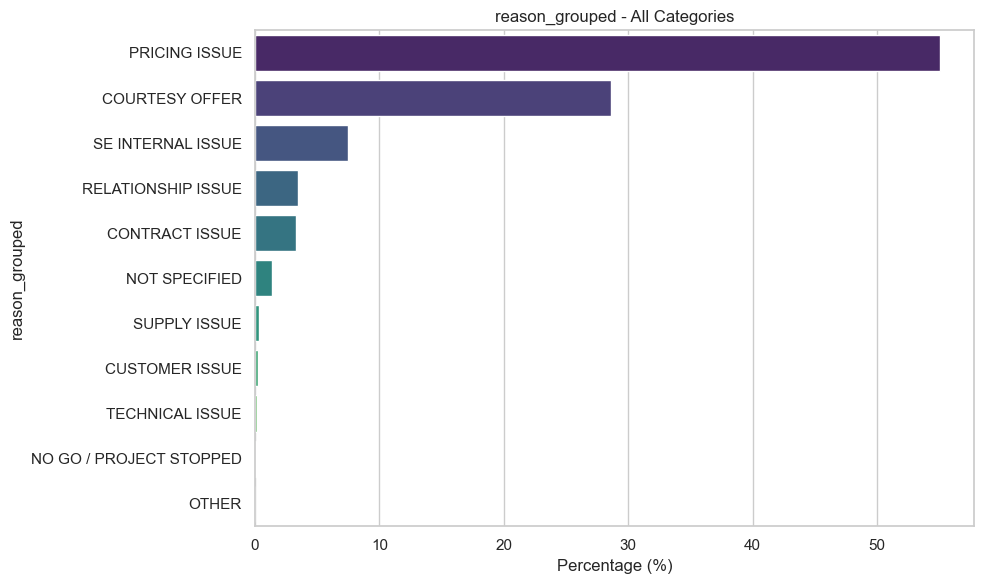

In [36]:
plot_categorical_clean('reason_grouped')

Pricing issues are by far the main reason for lost opportunities, followed by courtesy offers. Other reasons such as internal, contract, or relationship issues occur much less frequently.

### 6.2. Data Pre-Processing 
Cleans and prepares the dataset by handling missing values through targeted deletion and imputation, and addresses numerical outliers to ensure statistical reliability.

#### 6.2.1. Missing Values
Removes rows containing missing values (NaNs) from the dataset to ensure the final analysis is performed exclusively on fully populated and verifiable records.

In [37]:
# Rows before 
rows_before = len(df_clean)
print(f"Rows BEFORE handling NaNs: {rows_before}")

# Drop 
cols_to_drop_nans = ['competitor', 'division', 'product_line', 'business_unit']
df_clean = df_clean.dropna(subset=cols_to_drop_nans)

# Filling the missings
df_clean['reason'] = df_clean['reason'].fillna('NOT SPECIFIED')

rows_after = len(df_clean)
rows_dropped = rows_before - rows_after

print(f"Rows AFTER handling NaNs: {rows_after}")
print(f"{rows_dropped} rows were deleted.")

print("\nRemaining nulls:")
print(df_clean[['competitor', 'division', 'reason']].isnull().sum())

Rows BEFORE handling NaNs: 190503
Rows AFTER handling NaNs: 88030
102473 rows were deleted.

Remaining nulls:
competitor    0
division      0
reason        0
dtype: int64


#### 6.2.2. Outliers

##### 6.2.2.1. Numerical Variables
The objective of this step is to determine the most appropriate outlier‑detection method for the lost_amount variable based on its skewness and kurtosis characteristics.

In [38]:
# Normality metrics
skew_val = df_clean['lost_amount'].skew()
kurt_val = df_clean['lost_amount'].kurt() + 3  # Excess to standard kurtosis

print(f"Skewness: {skew_val:.2f} (Target: [-0.75, 0.75])")
print(f"Kurtosis: {kurt_val:.2f} (Target: [2.5, 3.5])")

is_symmetric = (-0.75 <= skew_val <= 0.75)
is_mesokurtic = (2.5 <= kurt_val <= 3.5)

df_clean['is_outlier_amount'] = False 

# Dynamic outlier detection mapping
if is_symmetric and is_mesokurtic:
    print("Method selected: Z-SCORES")
    z_scores = (df_clean['lost_amount'] - df_clean['lost_amount'].mean()) / df_clean['lost_amount'].std()
    df_clean.loc[np.abs(z_scores) > 3, 'is_outlier_amount'] = True

elif not is_symmetric:
    print("Method selected: IQR")
    q1, q3 = df_clean['lost_amount'].quantile([0.25, 0.75])
    iqr = q3 - q1
    df_clean.loc[(df_clean['lost_amount'] < q1 - 1.5 * iqr) | (df_clean['lost_amount'] > q3 + 1.5 * iqr), 'is_outlier_amount'] = True

else:
    print("Method selected: HAMPEL IDENTIFIER")
    median_val = df_clean['lost_amount'].median()
    mad = np.median(np.abs(df_clean['lost_amount'].dropna() - median_val))
    threshold = 3 * (1.4826 * mad) 
    df_clean.loc[np.abs(df_clean['lost_amount'] - median_val) > threshold, 'is_outlier_amount'] = True

# Results summary
outliers_count = df_clean['is_outlier_amount'].sum()
print(f"\nExecution success: {outliers_count} outliers flagged in 'is_outlier_amount'.")

Skewness: 117.89 (Target: [-0.75, 0.75])
Kurtosis: 20744.98 (Target: [2.5, 3.5])
Method selected: IQR

Execution success: 11605 outliers flagged in 'is_outlier_amount'.



We want to take a look to the detected outliers. 

In [39]:
df_clean["is_outlier_amount"].value_counts()

is_outlier_amount
False    76425
True     11605
Name: count, dtype: int64

In [ ]:
outliers_df = df_clean[df_clean["is_outlier_amount"]]
outliers_df.head(20)

##### 6.2.2.2. Categorical Variables
The objective of this step is to quantify the competitive landscape, identify dominant competitors through Pareto analysis, detect low‑presence competitors that may represent noise in the dataset and drop them. 

 TOP COMPETITORS


,competitor,count,percentage (%),cumulative (%)
0,Competitor 4,21158,24.03,24.03
1,Competitor 3,17798,20.22,44.25
2,Competitor 1,11852,13.46,57.71
3,Competitor 46,10589,12.03,69.74
4,Competitor 15,3055,3.47,73.21
5,Competitor 108,2362,2.68,75.89
6,Competitor 99,1440,1.64,77.53
7,Competitor 40,1376,1.56,79.09
8,Competitor 38,1232,1.40,80.49
9,Competitor 232,1025,1.16,81.65



 BOTTOM COMPETITORS


,competitor,count,percentage (%),cumulative (%)
602,Competitor 409,1,0.0,99.51
603,Competitor 410,1,0.0,99.51
604,Competitor 411,1,0.0,99.51
605,Competitor 414,1,0.0,99.51
606,Competitor 417,1,0.0,99.51
607,Competitor 429,1,0.0,99.51
608,Competitor 431,1,0.0,99.51
609,Competitor 432,1,0.0,99.51
610,Competitor 441,1,0.0,99.51
611,Competitor 621,1,0.0,99.51



Single-win competitors detected: 143


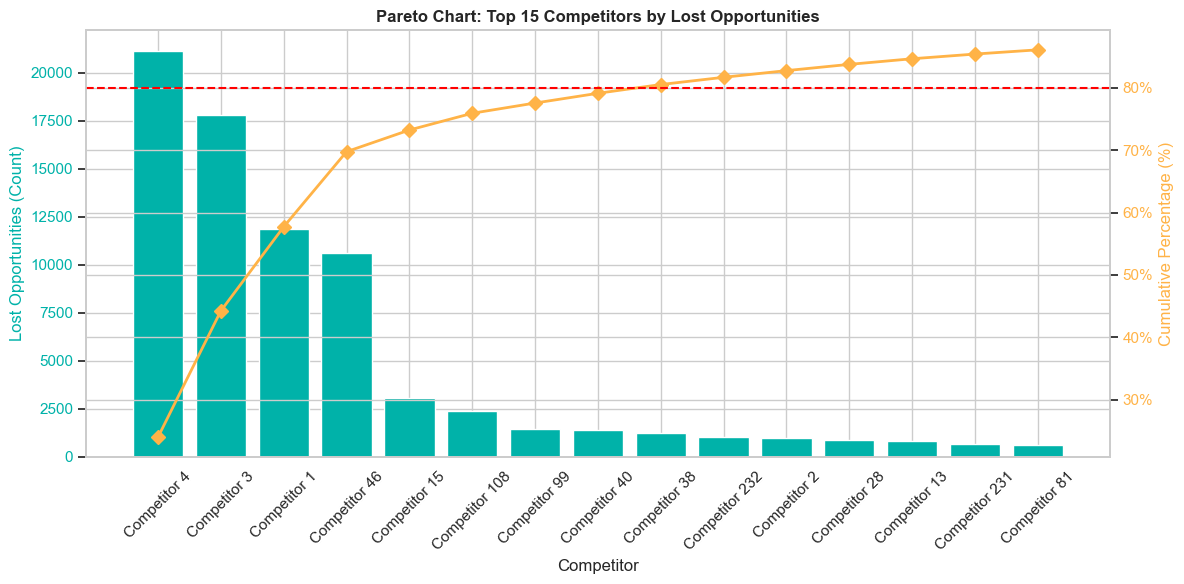

In [41]:
# Pareto metrics
comp_stats = df_clean['competitor'].value_counts().reset_index()
comp_stats.columns = ['competitor', 'count']
comp_stats['percentage (%)'] = (comp_stats['count'] / len(df_clean) * 100).round(2)
comp_stats['cumulative (%)'] = comp_stats['percentage (%)'].cumsum().round(2)

pareto_threshold = 80.0
cutoff_index = comp_stats[comp_stats['cumulative (%)'] >= pareto_threshold].index[0]
top_giants_list = comp_stats.loc[:cutoff_index, 'competitor'].tolist()

print(" TOP COMPETITORS")
display(comp_stats.head(15))

print("\n BOTTOM COMPETITORS")
display(comp_stats.tail(10))

# Single wins
noise_comps_list = comp_stats[comp_stats['count'] == 1]['competitor'].tolist()
print(f"\nSingle-win competitors detected: {len(noise_comps_list)}")

# Pareto plot
df_pareto = comp_stats.head(15)
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(df_pareto['competitor'], df_pareto['count'], color='#00b2a9')
ax1.set_xlabel('Competitor')
ax1.set_ylabel('Lost Opportunities (Count)', color='#00b2a9')
ax1.tick_params(axis='y', labelcolor='#00b2a9')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(df_pareto['competitor'], df_pareto['cumulative (%)'], color='#FFB347', marker='D', ms=7, linewidth=2)
ax2.axhline(pareto_threshold, color='red', linestyle='dashed', linewidth=1.5, label='80% Threshold')
ax2.set_ylabel('Cumulative Percentage (%)', color='#FFB347')
ax2.tick_params(axis='y', labelcolor='#FFB347')
ax2.yaxis.set_major_formatter(PercentFormatter())

plt.title('Pareto Chart: Top 15 Competitors by Lost Opportunities', fontweight='bold')
plt.tight_layout()
plt.show()

Now they can be eliminated, we're going to create a new dataset, in order to not lose information. 

In [42]:
rows_before = len(df_clean)
df_emerging = df_clean.copy()

# Remove 
df_emerging = df_emerging[~df_emerging['competitor'].isin(top_giants_list)]
df_emerging = df_emerging[~df_emerging['competitor'].isin(noise_comps_list)]

rows_after = len(df_emerging)

print(f"{len(top_giants_list)} GIANTS DETECTED & REMOVED")
print(top_giants_list)

print(f"\nNOISE REMOVED")
print(f"Competitors appearing only once: {len(noise_comps_list)}")

print(f"Rows removed: {rows_before - rows_after}")
print(f"Remaining rows for EMERGING competitors analysis: {rows_after}")

9 GIANTS DETECTED & REMOVED
['Competitor 4', 'Competitor 3', 'Competitor 1', 'Competitor 46', 'Competitor 15', 'Competitor 108', 'Competitor 99', 'Competitor 40', 'Competitor 38']

NOISE REMOVED
Competitors appearing only once: 143
Rows removed: 71005
Remaining rows for EMERGING competitors analysis: 17025


Also we want to know the number of distinct competitors after cleaning top competitors. 

In [43]:
# Number of distinct competitors BEFORE cleaning
distinct_before = df_clean['competitor'].nunique()

# Number of distinct competitors AFTER cleaning top competitors and noise
distinct_after = df_emerging['competitor'].nunique()

print("Number of distinct competitors BEFORE cleaning:", distinct_before)
print("Number of distinct competitors AFTER cleaning top competitors:", distinct_after)

Number of distinct competitors BEFORE cleaning: 612
Number of distinct competitors AFTER cleaning top competitors: 460


### 6.3. Univariate Analysis With Pre-Processed Data

#### 6.3.1. Categorical Variables

In [44]:
cols_to_exclude = ['id_', 'opp_line_id_', 'reason', 'winner', 'close_date']
vertical_cols = ['close_month', 'close_date_year', 'close_date_quarter_year']

cat_cols_emerging = [col for col in df_emerging.select_dtypes(include=['object', 'category']).columns 
                     if col not in cols_to_exclude]

sns.set_theme(style="whitegrid")

def plot_categorical_emerging(col):
    print(f"\n FEATURE: {col.upper()}")
    
    # Calculate relative frequencies
    counts = df_emerging[col].value_counts()
    freq_table = pd.DataFrame({
        'Percentage (%)': (df_emerging[col].value_counts(normalize=True) * 100).round(2)
    })
    
    # Sort categories
    freq_table = freq_table.sort_index() if col in vertical_cols else freq_table.sort_values(by='Percentage (%)', ascending=False)
    
    unique_cats = df_emerging[col].nunique()
    is_vertical = col in vertical_cols 
    cat_labels = freq_table.index.astype(str) 
    
    # Configure relative axis labels
    labels_dict = {
        'xlabel': 'Percentage (%)' if not is_vertical else col,
        'ylabel': col if not is_vertical else 'Percentage (%)'
    }
    
    # Low cardinality distributions
    if unique_cats <= 5:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        if is_vertical:
            sns.barplot(x=cat_labels, y=freq_table['Percentage (%)'], ax=axes[0], palette='viridis')
            axes[0].tick_params(axis='x', rotation=45)
        else:
            sns.barplot(x=freq_table['Percentage (%)'], y=cat_labels, ax=axes[0], palette='viridis')
            
        axes[0].set(title=f'{col} - Distribution', **labels_dict)
        axes[1].pie(counts, labels=cat_labels, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
        axes[1].set_title(f'{col} - Share')
        
    # High cardinality distributions
    else:
        fig, ax = plt.subplots(figsize=(10, 6))
        data_plot = freq_table.head(15) if unique_cats > 20 else freq_table
        labels_plot = data_plot.index.astype(str)
        palette = 'magma' if unique_cats > 20 else 'viridis'
        
        if is_vertical:
            sns.barplot(x=labels_plot, y=data_plot['Percentage (%)'], ax=ax, palette=palette)
            ax.tick_params(axis='x', rotation=45)
        else:
            sns.barplot(x=data_plot['Percentage (%)'], y=labels_plot, ax=ax, palette=palette)
            
        title_text = f'Top 15 {col}' if unique_cats > 20 else f'{col} - All Categories'
        ax.set(title=title_text, **labels_dict)
        
    plt.tight_layout()
    plt.show()

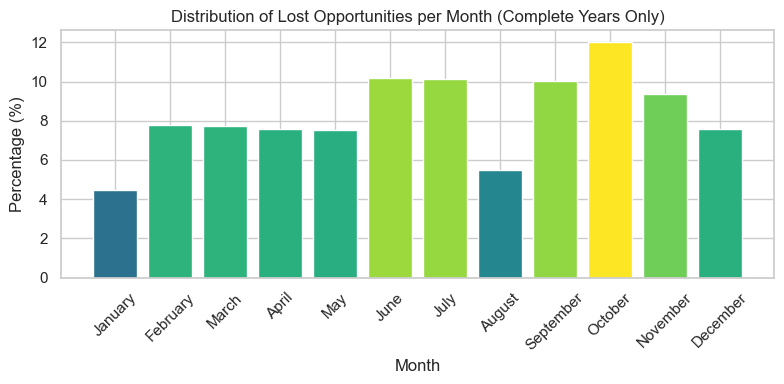

In [45]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

# Filter complete years
months_per_year = df_clean.groupby("close_date_year")["close_month"].nunique()
complete_years = months_per_year[months_per_year == 12].index

if len(complete_years) == 0:
    print("Error: No complete years available.")
else:
    # Compute monthly averages
    monthly_avg = (
        df_emerging[df_emerging["close_date_year"].isin(complete_years)]
        .groupby(["close_date_year", "close_month"], observed=True)
        .size()
        .reset_index(name="count")
        .groupby("close_month", observed=True)["count"]
        .mean()
        .reindex(month_order)
        .fillna(0)
    )
    
    # Calculate percentage distribution
    monthly_pct = (monthly_avg / monthly_avg.sum()) * 100

    plt.figure(figsize=(8, 4))
    colors = plt.cm.viridis(monthly_pct / monthly_pct.max())
    
    plt.bar(monthly_pct.index.astype(str), monthly_pct.values, color=colors)
    plt.xticks(rotation=45)
    
    plt.title("Distribution of Lost Opportunities per Month (Complete Years Only)")
    plt.xlabel("Month")
    plt.ylabel("Percentage (%)")
    plt.tight_layout()
    plt.show()

Compared to the full dataset, the emerging‑competitor distribution shows lower values across all months, while the seasonal pattern remains similar. This suggests that dominant competitors mainly affect the volume of losses, but not the overall seasonality.


 FEATURE: CLOSE_DATE_YEAR


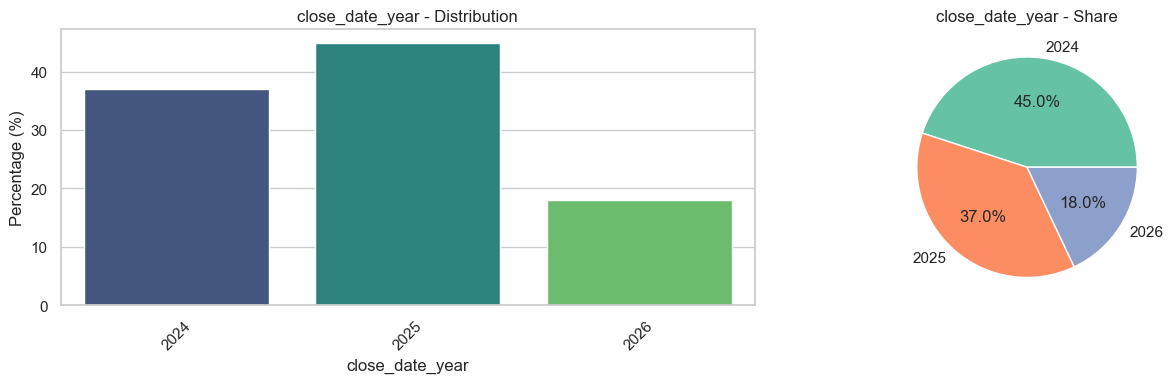

In [46]:
plot_categorical_emerging('close_date_year')

The year‑by‑year distribution is similar to the full dataset, but with lower volumes after removing dominant competitors. This suggests that top competitors affect the magnitude of losses rather than their temporal distribution.


 FEATURE: CLOSE_DATE_QUARTER_YEAR


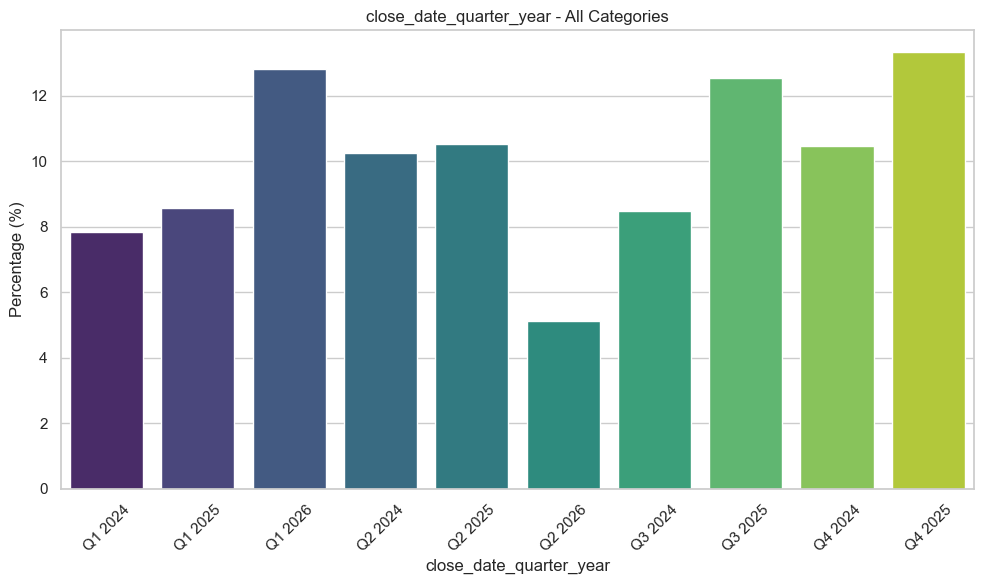

In [47]:
plot_categorical_emerging('close_date_quarter_year')

After removing dominant competitors, the distribution of lost opportunities by quarter and year shows lower volumes across all periods while preserving a similar overall structure. Recent quarters, particularly Q3 and Q4 2025, continue to concentrate more observations, whereas heavily incomplete quarters such as Q2 2026 display very low values.


 FEATURE: MARKET_SEGMENT


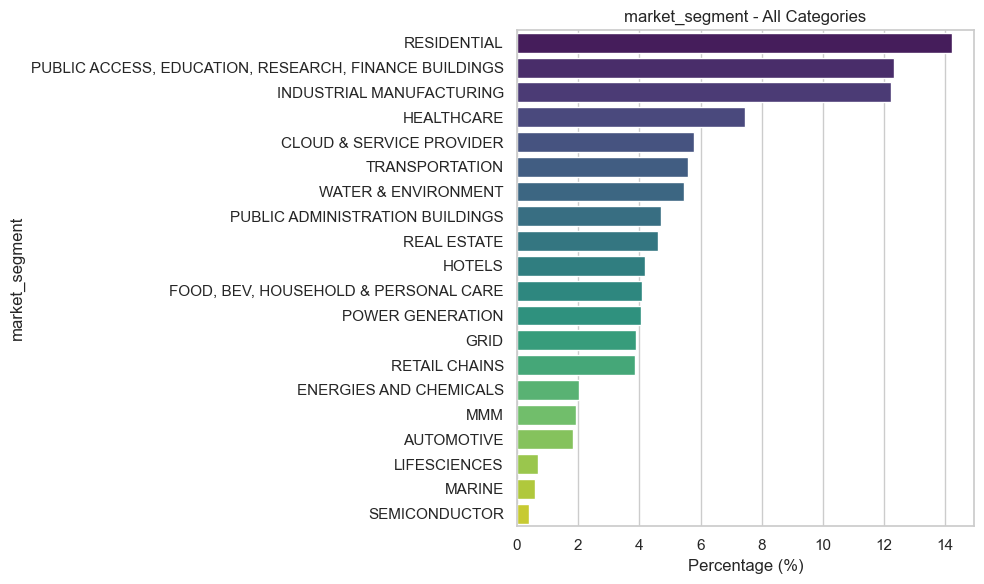

In [48]:
plot_categorical_emerging('market_segment')

After excluding dominant competitors, Residential and Industrial Manufacturing segments become relatively more prominent. In contrast to the original distribution, the Public Access and large institutional segments lose relative weight, indicating that these segments were previously dominated by some of the top competitors.


 FEATURE: PRODUCT_LINE


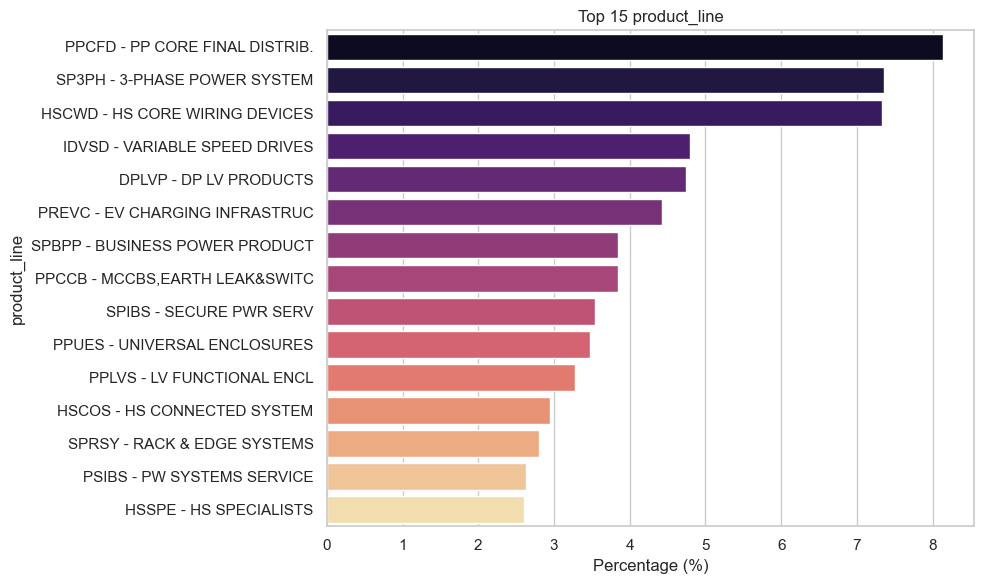

In [49]:
plot_categorical_emerging('product_line')

Lost opportunities remain concentrated in a limited number of product lines, mainly related to power distribution and electrical infrastructure. Compared to the original dataset, the distribution is less dominated by a few lines, showing a more balanced presence of medium‑importance products.


 FEATURE: BUSINESS_UNIT


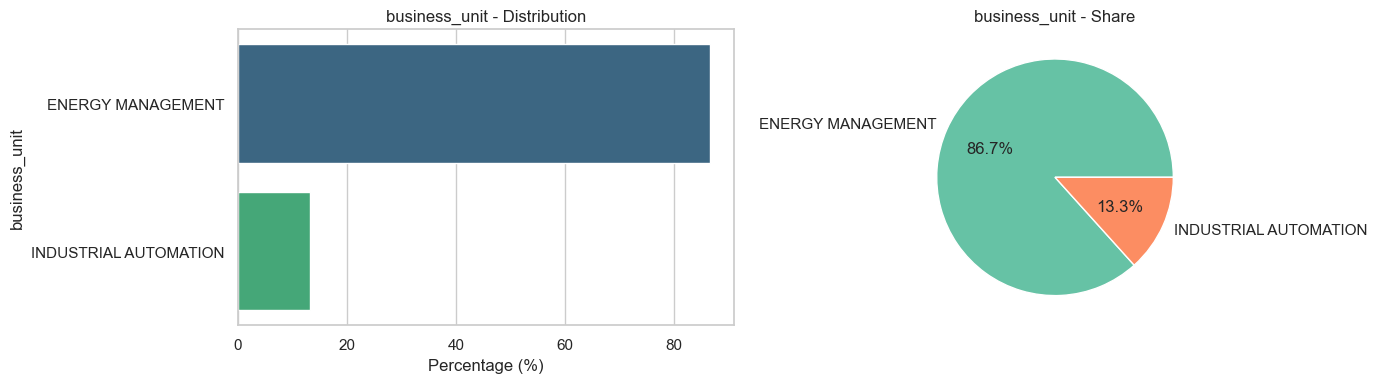

In [50]:
plot_categorical_emerging('business_unit')

After removing the dominant competitors, most lost opportunities are still concentrated in the Energy Management business unit. Industrial Automation represents a much smaller share, indicating that losses continue to occur mainly in energy‑related activities even among non‑dominant competitors.


 FEATURE: DIVISION


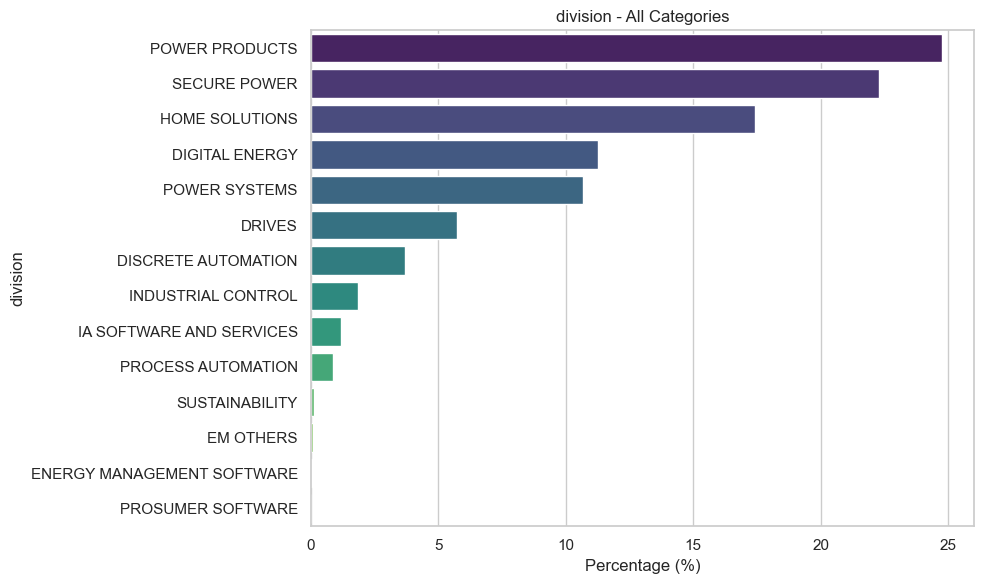

In [51]:
plot_categorical_emerging('division')

Power Products and Secure Power continue to account for most lost opportunities after cleaning, followed by Home Solutions and Digital Energy. Compared to the original analysis, losses are more evenly distributed across divisions, highlighting the role of mid‑tier divisions in the remaining competitive landscape.


 FEATURE: ZONE


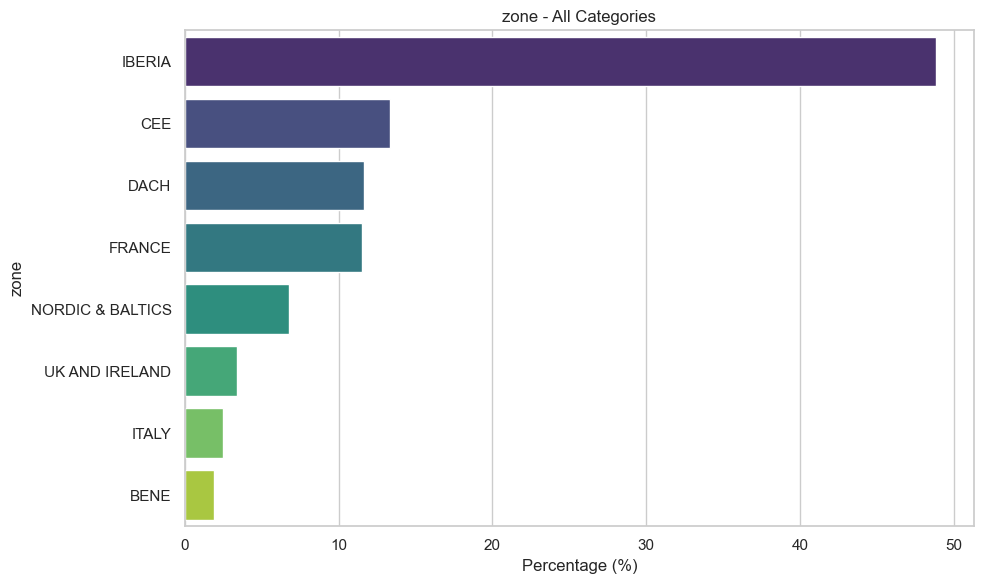

In [52]:
plot_categorical_emerging('zone')

Iberia remains the most affected zone even after removing dominant competitors, while the relative contribution of France decreases compared to the original dataset. This suggests that losses in Iberia are more widely distributed across medium‑sized and emerging competitors.


 FEATURE: CUSTOMER_CLASSIFICATION


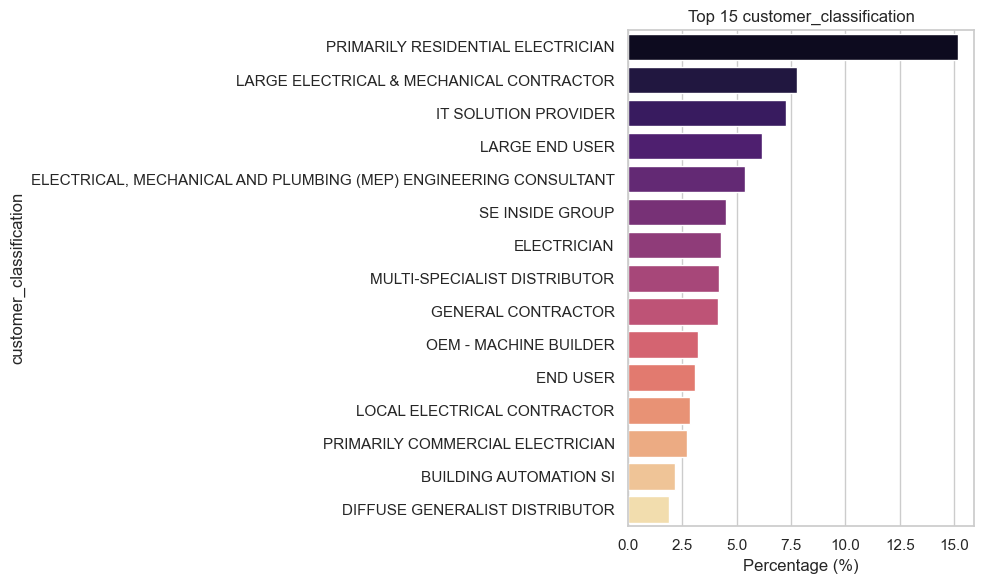

In [53]:
plot_categorical_emerging('customer_classification')

Following the removal of top competitors, lost opportunities are more evenly distributed across customer types, with residential electricians and mid‑sized contractors gaining relative importance. This contrasts with the original analysis, where large contractors were clearly dominant.


 FEATURE: COUNTRY


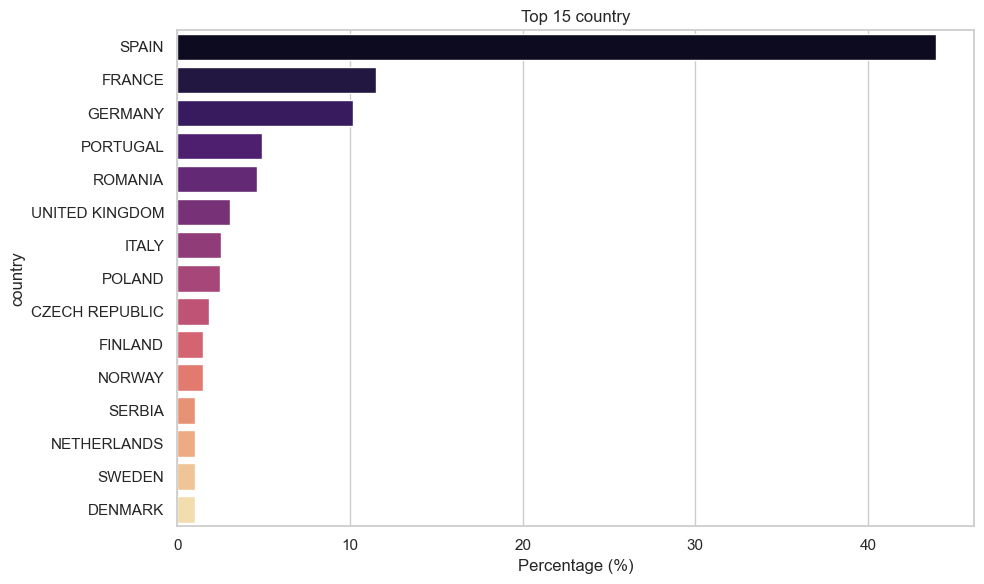

In [54]:
plot_categorical_emerging('country')

Spain continues to lead in lost opportunities after cleaning, but the gap with other countries is reduced compared to the original distribution. This indicates that a significant share of losses in Spain is associated with non‑dominant competitors.


 FEATURE: COMPETITOR


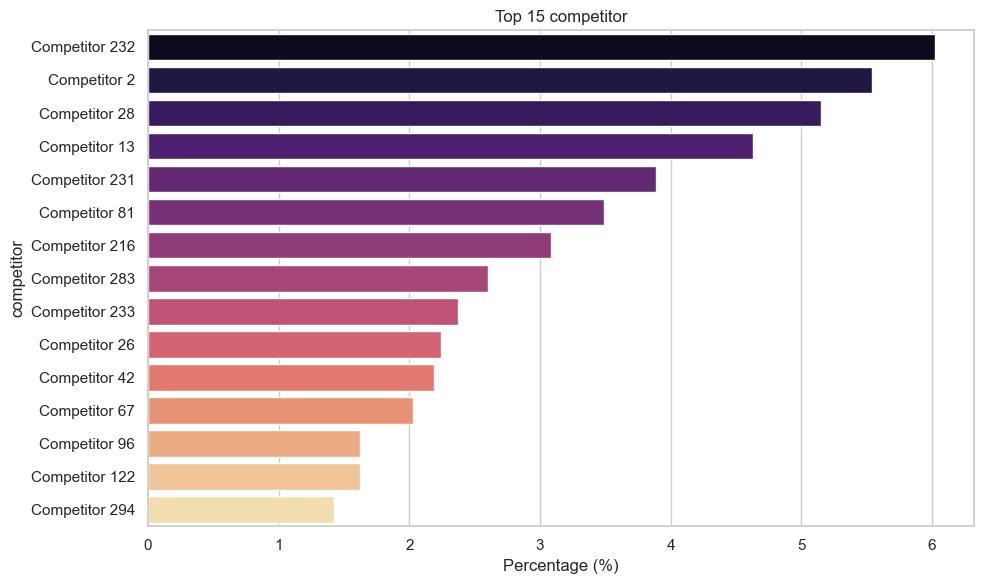

In [55]:
plot_categorical_emerging('competitor')

After removing the top competitors, lost opportunities are spread across several medium‑sized competitors instead of being dominated by a few large players. This suggests a more competitive and fragmented market among the remaining competitors.


 FEATURE: REASON_GROUPED


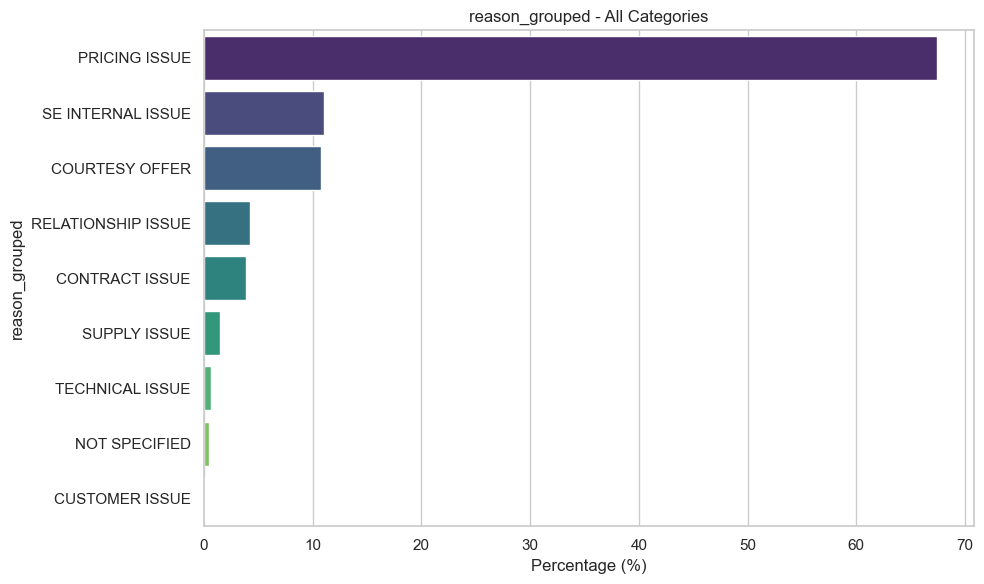

In [56]:
plot_categorical_emerging('reason_grouped')

Pricing issues remain the primary reason for lost opportunities even after excluding dominant competitors. However, the relative importance of internal and contractual reasons slightly increases, suggesting a broader variety of loss drivers among emerging competitors.

### 6.4. Bivariate Analysis

For the bivariate analysis, we first examine relationships using the full preprocessed dataset. We then compare the results with the emerging‑competitor dataset, highlighting how relationships change after removing dominant competitors.

#### 6.4.1. Numerical vs Numerical

In this section, we analyze the relationships between numerical variables using correlation measures and correlation plots, in order to understand how different loss‑related metrics are associated with each other.

##### 6.4.1.1. Full Dataset

Correlation matrix (Spearman) – Full dataset


,lost_amount,lost_amount_ytd,lost_amount_pytd
lost_amount,1.000,0.038,0.005
lost_amount_ytd,0.038,1.000,-0.158
lost_amount_pytd,0.005,-0.158,1.000


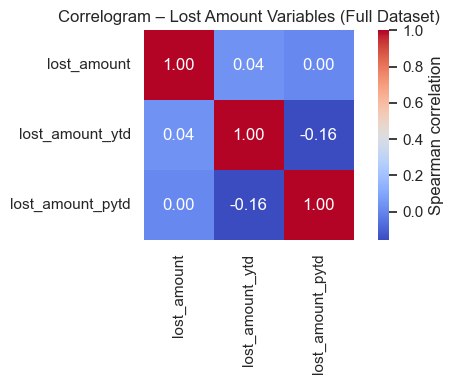

In [57]:
num_cols = [
    "lost_amount",
    "lost_amount_ytd",
    "lost_amount_pytd"
]

# Correlation matrix (Spearman)
corr_matrix = df_clean[num_cols].corr(method="spearman") # We use Spearman because we don't suppose normality

print("Correlation matrix (Spearman) – Full dataset")
display(corr_matrix.round(3))

# Correlogram 
plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Spearman correlation"}
)

plt.title("Correlogram – Lost Amount Variables (Full Dataset)")
plt.tight_layout()
plt.show()

The correlation matrix and correlogram show very weak relationships between lost_amount, lost_amount_ytd and lost_amount_pytd. The Spearman correlation values are close to zero, indicating that current losses are largely independent from year‑to‑date and previous year‑to‑date loss measures. This suggests that large loss events tend to occur as isolated cases rather than following a cumulative or persistent pattern over time.

##### 6.4.1.2. Emerging Competitors Dataset

Correlation matrix (Spearman) – Emerging competitors dataset


,lost_amount,lost_amount_ytd,lost_amount_pytd
lost_amount,1.000,-0.002,0.059
lost_amount_ytd,-0.002,1.000,-0.157
lost_amount_pytd,0.059,-0.157,1.000


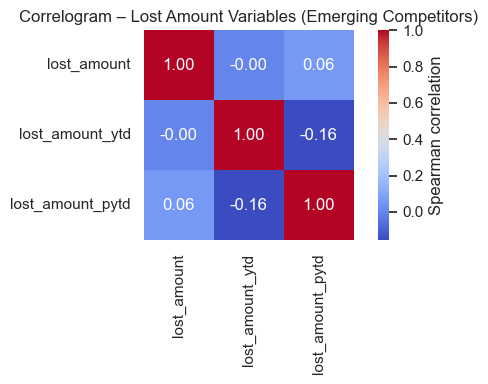

In [58]:
# Correlation Matrix only with Emerging Competitors
corr_matrix_em = df_emerging[num_cols].corr(method="spearman")

print("Correlation matrix (Spearman) – Emerging competitors dataset")
display(corr_matrix_em.round(3))

# Correlogram only with Emerging Competitors
plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix_em,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Spearman correlation"}
)

plt.title("Correlogram – Lost Amount Variables (Emerging Competitors)")
plt.tight_layout()
plt.show()

The correlation matrix and correlogram for the emerging competitors dataset show very weak relationships between lost_amount, lost_amount_ytd and lost_amount_pytd. All Spearman correlation coefficients are close to zero, indicating that loss values at the opportunity level remain largely independent from accumulated losses, even after removing dominant competitors.

The correlations observed in the emerging competitors dataset are very similar to those in the full dataset, indicating that removing dominant competitors does not significantly alter the relationships between loss variables.

#### 6.4.2 Categorical vs Categorical

Here, we study the relationships between categorical variables through contingency tables, independency tests and comparative visualizations, allowing us to identify patterns and associations across market, geographical, and organizational dimensions.

##### 6.4.2.1. Market Segment × Zone

In [ ]:
# Contingency Table
ct_seg_zone = pd.crosstab(
    df_clean["market_segment"],
    df_clean["zone"]
)

display(ct_seg_zone)

The contingency table shows that lost opportunities are unevenly distributed across zones, with Iberia clearly concentrating the highest number of losses across almost all market segments. In contrast, other zones such as BENE, Italy, and the UK & Ireland present lower and more segment‑specific loss patterns, indicating strong geographical differences in market activity and competitive pressure.

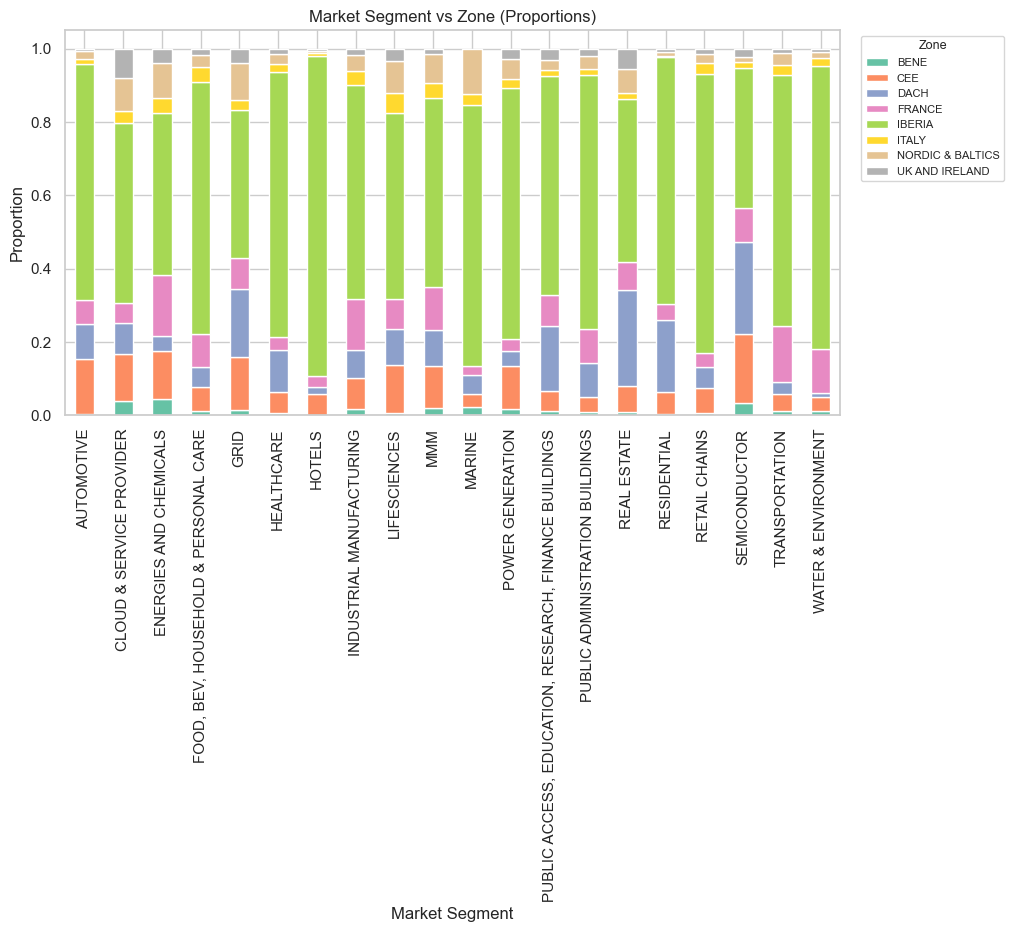

In [60]:
# Barplot
ct_seg_zone_norm = ct_seg_zone.div(ct_seg_zone.sum(axis=1), axis=0)

ct_seg_zone_norm.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5),
    colormap="Set2"
)

# Legend 
plt.legend(
    title="Zone",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9
)

plt.title("Market Segment vs Zone (Proportions)")
plt.ylabel("Proportion")
plt.xlabel("Market Segment")
plt.tight_layout()
plt.show()

Lost opportunities are strongly concentrated in Iberia across most market segments, while other zones show more diversified distributions.

In [61]:
# Chi-square test
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(ct_seg_zone)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")

Chi-square statistic: 11894.25
Degrees of freedom: 133
p-value: 0.0000


The chi‑square test confirms a statistically significant association between market segment and zone (p < 0.001), indicating that market segment distribution is not independent across geographical regions.

**Comparison with Emerging Competitors**

We now compare these results with the emerging‑competitor dataset to assess how the market structure changes after removing dominant competitors.

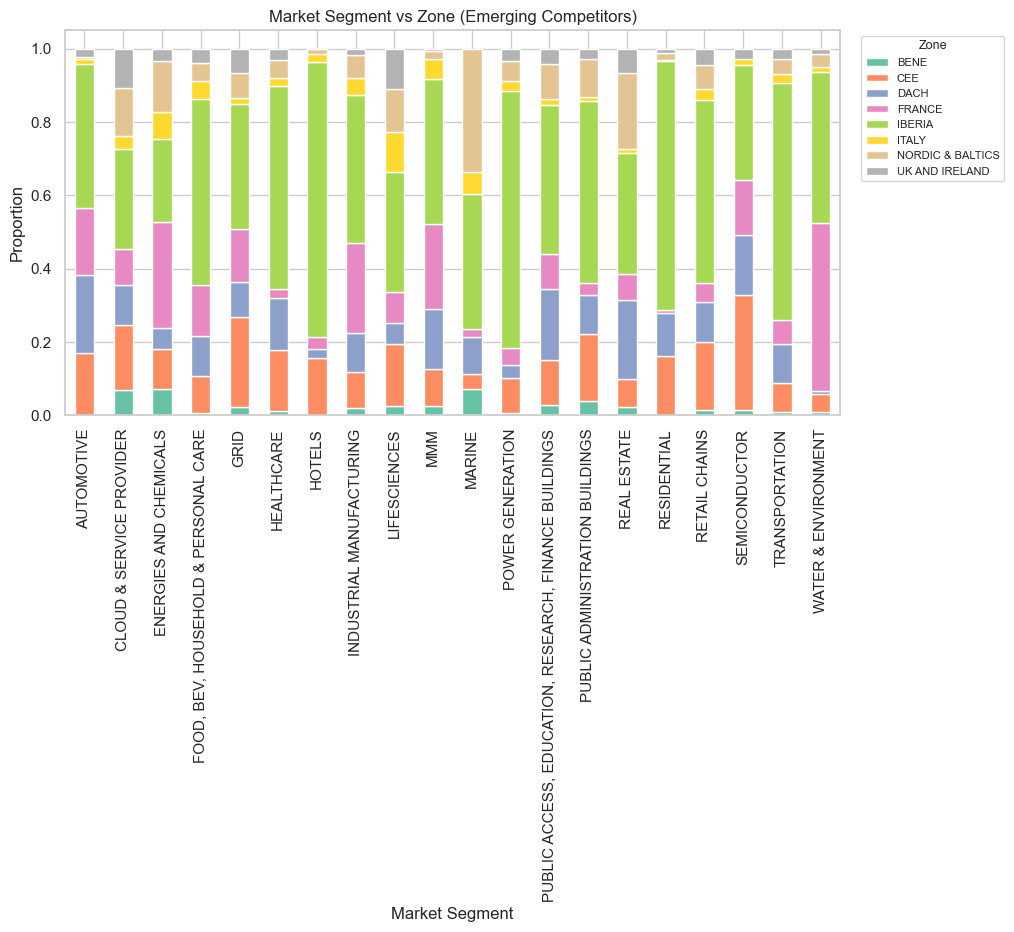

In [62]:
# Barplot - Emerging Competitors

ct_seg_zone_em = pd.crosstab(
    df_emerging["market_segment"],
    df_emerging["zone"]
)

ct_seg_zone_em_norm = ct_seg_zone_em.div(ct_seg_zone_em.sum(axis=1), axis=0)

ct_seg_zone_em_norm.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5),
    colormap="Set2"
)

# Legend 
plt.legend(
    title="Zone",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9
)

plt.title("Market Segment vs Zone (Emerging Competitors)")
plt.ylabel("Proportion")
plt.xlabel("Market Segment")
plt.tight_layout()
plt.show()

In [63]:
# Chi-square test
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(ct_seg_zone_em)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")

Chi-square statistic: 4835.13
Degrees of freedom: 133
p-value: 0.0000


After removing dominant competitors, the distribution of market segments across zones becomes more balanced. Although Iberia remains the most prominent zone in most segments, the concentration is less pronounced than in the full dataset, suggesting that emerging competitors are more evenly distributed across geographical regions.

##### 6.4.2.2. Division × Zone 

In [ ]:
# Contingency Table

ct_div_zone = pd.crosstab(
    df_clean["division"],
    df_clean["zone"]
)

display(ct_div_zone)

The contingency table shows that lost opportunities are unevenly distributed across divisions and zones. Iberia clearly concentrates the largest number of losses in almost all divisions, particularly in Power Products, Secure Power, Home Solutions, and Power Systems, while other zones display more moderate and division‑specific patterns.

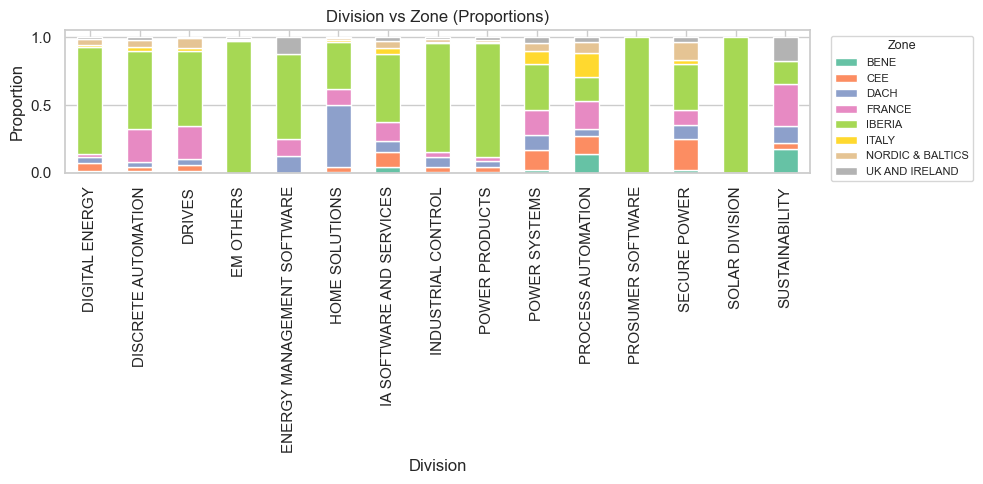

In [65]:
# Barplot 
ct_div_zone_norm = ct_div_zone.div(ct_div_zone.sum(axis=1), axis=0)

ct_div_zone_norm.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5),
    colormap="Set2"
)

# Legend 
plt.legend(
    title="Zone",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9
)

plt.title("Division vs Zone (Proportions)")
plt.ylabel("Proportion")
plt.xlabel("Division")
plt.tight_layout()
plt.show()

The proportional bar plot highlights clear geographical differences in the composition of lost opportunities by division. While Iberia dominates most divisions, zones such as DACH, France, and the Nordic & Baltics show relatively higher contributions in specific divisions, indicating regional specialization in business activities.

In [66]:
# Chi-square test
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(ct_div_zone)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")

Chi-square statistic: 40127.97
Degrees of freedom: 98
p-value: 0.0000


The chi‑square test confirms a statistically significant association between division and zone (p < 0.001), indicating that the distribution of business divisions is not independent across geographical regions.

**Comparison with Emerging Competitors**

We now compare these results with the emerging‑competitor dataset to assess how the distribution of business divisions changes after removing dominant competitors.

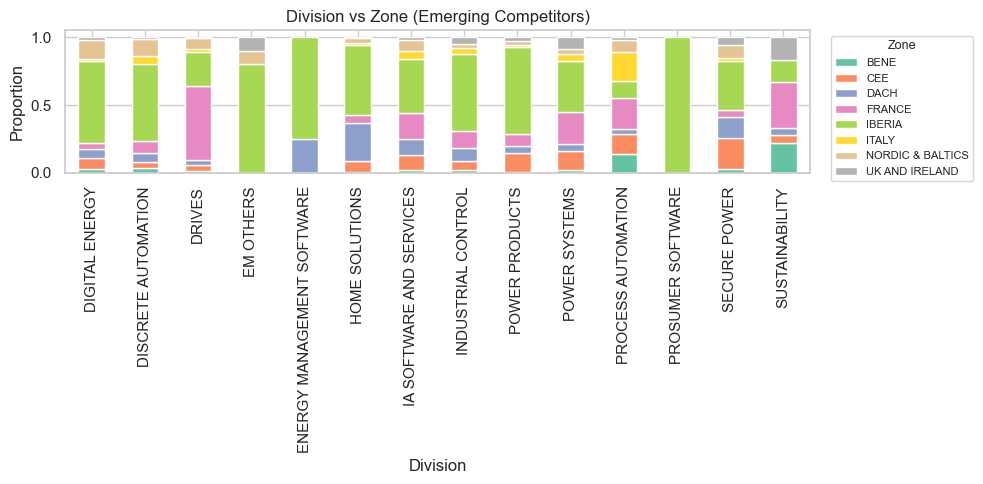

In [67]:
# Barplot - Emerging Competitors

ct_div_zone_em = pd.crosstab(
    df_emerging["division"],
    df_emerging["zone"]
)

ct_div_zone_em_norm = ct_div_zone_em.div(ct_div_zone_em.sum(axis=1), axis=0)

ct_div_zone_em_norm.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5),
    colormap="Set2"
)

# Legend 
plt.legend(
    title="Zone",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9
)

plt.title("Division vs Zone (Emerging Competitors)")
plt.ylabel("Proportion")
plt.xlabel("Division")
plt.tight_layout()
plt.show()

In [68]:
# Chi-square test
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(ct_div_zone_em)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")

Chi-square statistic: 5577.76
Degrees of freedom: 91
p-value: 0.0000


When comparing this distribution with the full dataset, the division‑by‑zone structure remains broadly similar, with Iberia continuing to play a dominant role across most divisions. However, after removing dominant competitors, the proportions become more balanced, and the relative contribution of other zones such as DACH, France, and the Nordic & Baltics increases in several divisions.

#### 6.4.3 Categorical vs Numerical

In this section, we analyze how numerical loss variables vary across selected categorical groups using boxplots, distribution plots, and grouped summary statistics.

##### 6.4.3.1. Market Segment × Lost Amount

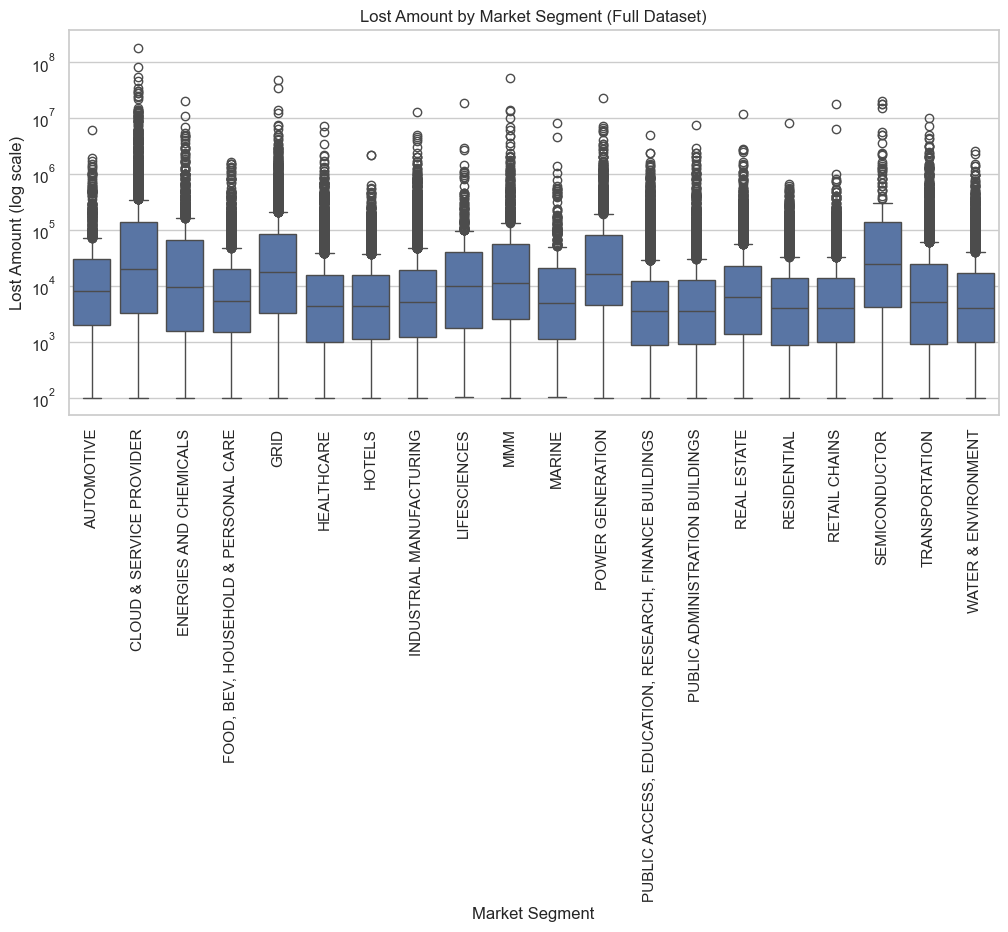

In [69]:
plt.figure(figsize=(12,5))
sns.boxplot(
    x="market_segment",
    y="lost_amount",
    data=df_clean
)

plt.yscale("log")
plt.xticks(rotation=90)
plt.title("Lost Amount by Market Segment (Full Dataset)")
plt.xlabel("Market Segment")
plt.ylabel("Lost Amount (log scale)")
plt.tight_layout()
plt.show()

The boxplot shows substantial variability in lost amounts across market segments, with all distributions exhibiting strong right skewness and long upper tails. Several segments, such as Public Access, Education, Research & Finance Buildings, Industrial Manufacturing, Residential, and Healthcare, present higher medians and a larger number of extreme values, indicating the presence of high‑value lost opportunities.

In [ ]:
summary_segment = (
    df_clean
    .groupby("market_segment")["lost_amount"]
    .describe()
)

display(summary_segment)

##### 6.4.3.2. Zone × Lost Amount

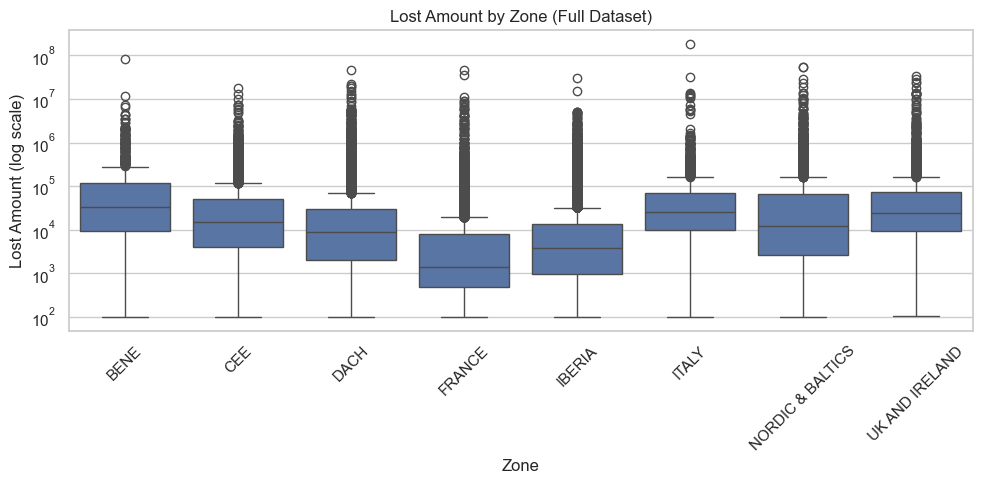

In [71]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x="zone",
    y="lost_amount",
    data=df_clean
)

plt.yscale("log")
plt.xticks(rotation=45)
plt.title("Lost Amount by Zone (Full Dataset)")
plt.xlabel("Zone")
plt.ylabel("Lost Amount (log scale)")
plt.tight_layout()
plt.show()

The boxplot highlights substantial overlap in the central part of the distributions across zones, indicating that typical loss values do not differ drastically. However, clear differences emerge in the upper tails, where some zones exhibit more extreme outliers and wider dispersion, reflecting a higher risk of very large losses.

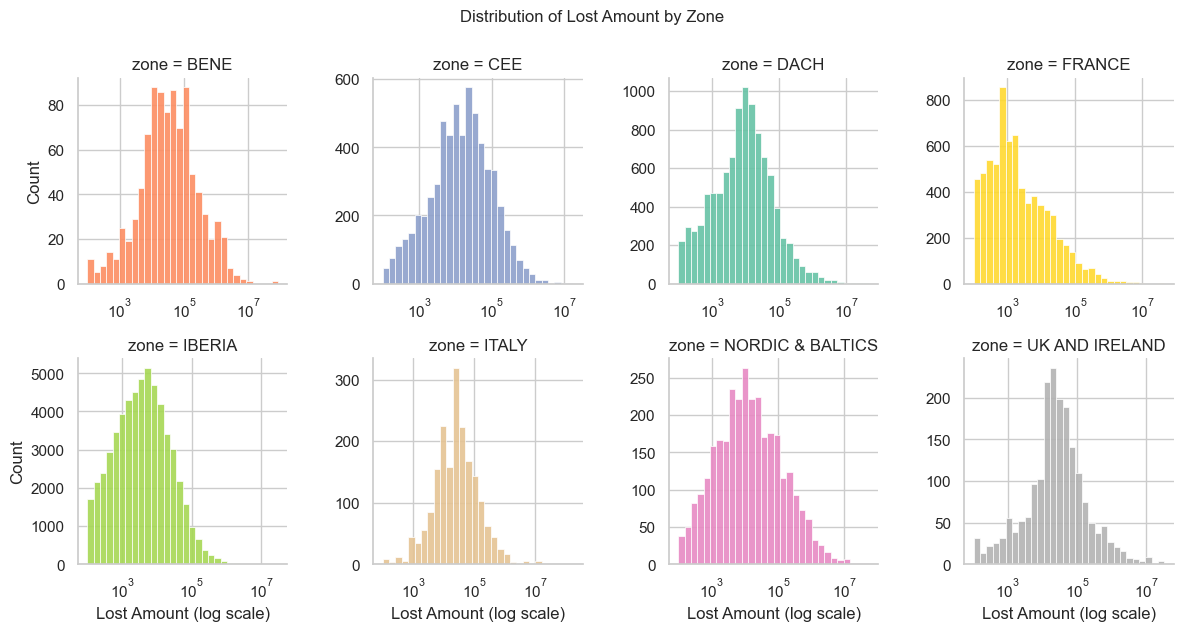

In [72]:
zones = df_clean["zone"].unique()
palette = dict(zip(zones, sns.color_palette("Set2", len(zones))))

g = sns.FacetGrid(
    df_clean,
    col="zone",
    col_wrap=4,
    height=3,
    sharex=False,
    sharey=False,
    hue="zone",
    palette=palette
)

g.map(
    sns.histplot,
    "lost_amount",
    bins=30,
    log_scale=True,
    alpha=0.9
)

g.fig.suptitle(
    "Distribution of Lost Amount by Zone",
    y=1.05,
    fontsize=12
)

g.set_axis_labels("Lost Amount (log scale)", "Count")
plt.show()

The histograms show that lost amount distributions are strongly right‑skewed in all zones, with most observations concentrated at lower values and a long tail of high‑value losses. While the overall distributional shape is similar across zones, differences are observed in the spread and in the frequency of extreme values.

In [ ]:
summary_zone = (
    df_clean
    .groupby("zone")["lost_amount"]
    .describe()
)

display(summary_zone)

**Comparison with Emerging Competitors**

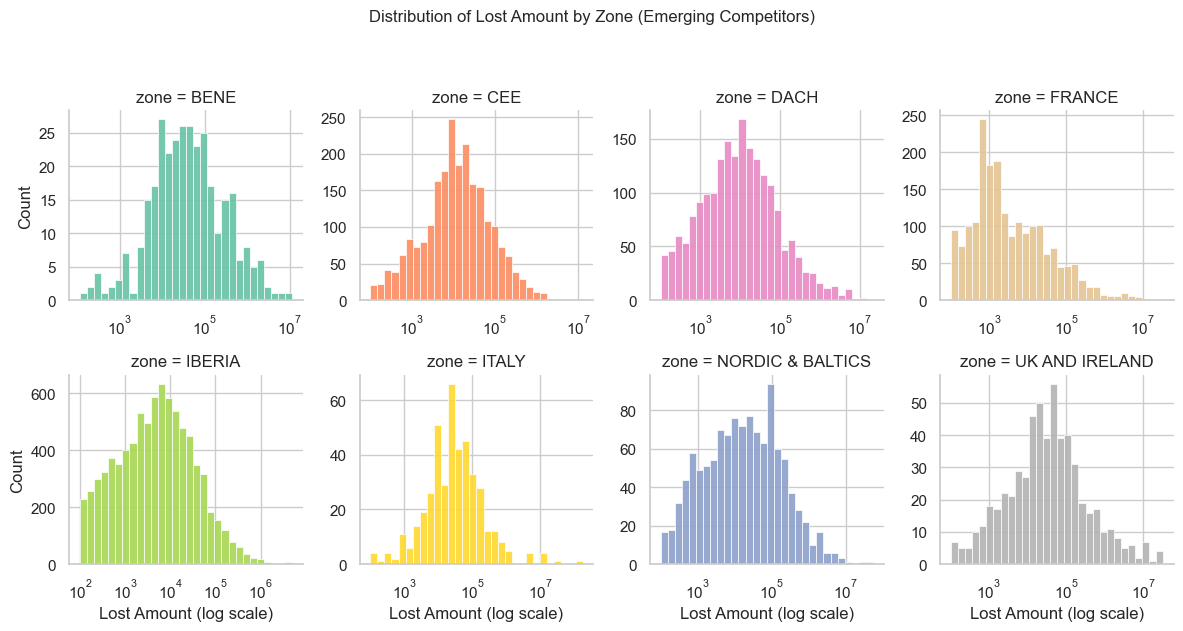

In [74]:
zones = df_emerging["zone"].unique()
palette = dict(zip(zones, sns.color_palette("Set2", len(zones))))

g = sns.FacetGrid(
    df_emerging,  
    col="zone",
    col_wrap=4,
    height=3,
    sharex=False,
    sharey=False,
    hue="zone",
    palette=palette
)

g.map(
    sns.histplot,
    "lost_amount",
    bins=30,
    log_scale=True,
    alpha=0.9
)

g.fig.suptitle(
    "Distribution of Lost Amount by Zone (Emerging Competitors)", 
    y=1.05,
    fontsize=12
)

g.set_axis_labels("Lost Amount (log scale)", "Count")
plt.tight_layout() 
plt.show()

##### 6.4.3.3. Division × Lost Amount

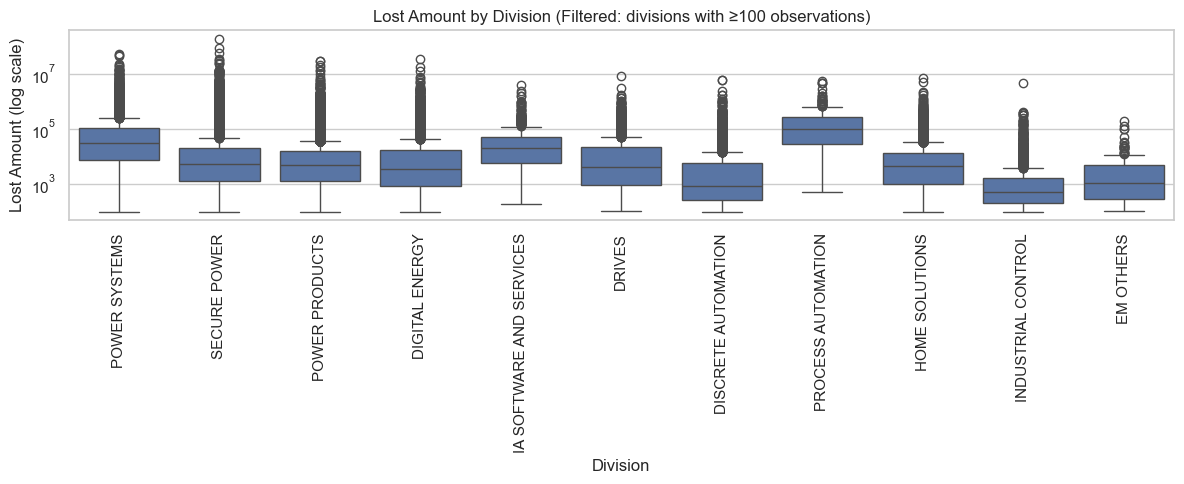

In [75]:
# Keep only divisions with enough observations
division_counts = df_clean["division"].value_counts()
valid_divisions = division_counts[division_counts >= 100].index

df_division_filtered = df_clean[
    df_clean["division"].isin(valid_divisions)
]

plt.figure(figsize=(12,5))
sns.boxplot(
    x="division",
    y="lost_amount",
    data=df_division_filtered
)

plt.yscale("log")
plt.xticks(rotation=90)
plt.title("Lost Amount by Division (Filtered: divisions with ≥100 observations)")
plt.xlabel("Division")
plt.ylabel("Lost Amount (log scale)")
plt.tight_layout()
plt.show()

Divisions with fewer than 100 observations were excluded from this visualization, as boxplots are not informative for sparse categories and may lead to misleading interpretations.

Despite similar central tendencies, clear differences are observed in the dispersion and in the upper tails of the distributions. Divisions such as Power Systems, Secure Power, and Process Automation exhibit wider spreads and more frequent extreme values, indicating greater exposure to very large loss events.

In [ ]:
summary_division = (
    df_clean
    .groupby("division")["lost_amount"]
    .describe()
)

display(summary_division)

**Comparison with Emerging Competitors**

We now compare these results with the emerging‑competitor dataset.

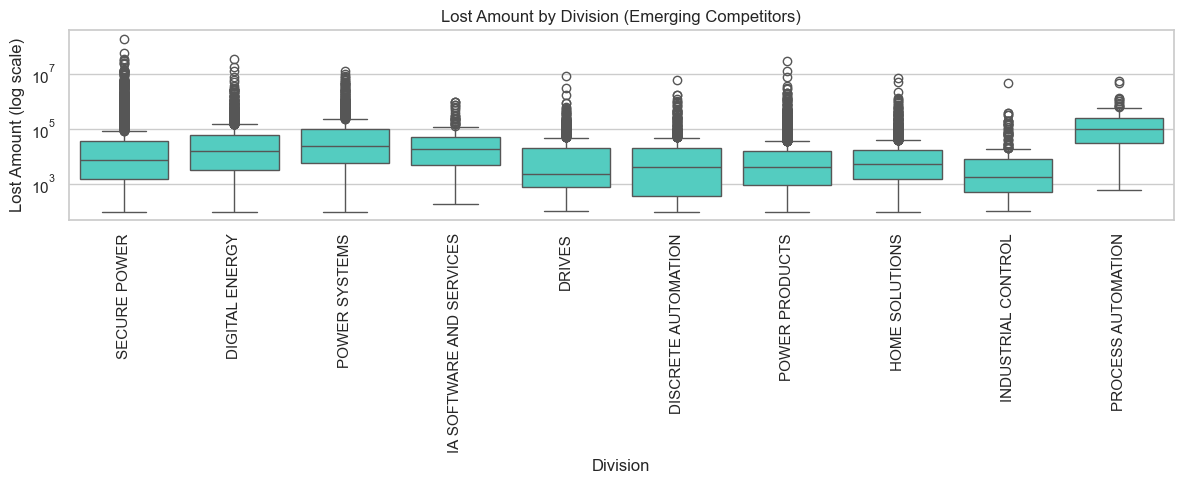

In [77]:
division_counts_em = df_emerging["division"].value_counts()
valid_divisions_em = division_counts_em[division_counts_em >= 100].index

df_division_em_filtered = df_emerging[
    df_emerging["division"].isin(valid_divisions_em)
]

plt.figure(figsize=(12,5))
sns.boxplot(
    x="division",
    y="lost_amount",
    data=df_division_em_filtered,
    color= 'turquoise'
)

plt.yscale("log")
plt.xticks(rotation=90)
plt.title("Lost Amount by Division (Emerging Competitors)")
plt.xlabel("Division")
plt.ylabel("Lost Amount (log scale)")
plt.tight_layout()
plt.show()

After restricting the analysis to emerging competitors, the boxplots show a similar distributional structure across divisions compared to the full dataset, with strong right skewness and long upper tails in all cases. However, overall loss magnitudes are visibly lower across all divisions, indicating that dominant competitors account for a significant share of the most extreme loss events.

#### 6.4.4 Outlier Analysis

In this section, we analyze different types of outliers to better understand competitive dynamics associated with unusual behavior. Two complementary perspectives are considered: value‑based outliers, defined by extreme lost amounts, and frequency‑based outliers, defined by unusually high competitive presence within specific market contexts.

##### 6.4.4.1. Value‑Based Outliers (Lost Amount)

Value‑based outliers correspond to observations with exceptionally high values of the lost_amount variable. These cases represent high‑impact loss events and are interpreted as economically significant rather than as noise or data errors.

In [78]:
outliers_df = df_clean[df_clean["is_outlier_amount"]]

##### 6.4.4.1.1. Value‑Based Outliers by Zone

This subsection examines how extreme loss values are distributed across geographical zones and identifies the competitors most frequently associated with these high‑impact loss events.

In [79]:
outliers_by_zone = (
    outliers_df
    .groupby(["zone", "competitor"])
    .size()
    .reset_index(name="outlier_count")
)
top_outliers_zone = (
    outliers_by_zone
    .sort_values(["zone", "outlier_count"], ascending=[True, False])
    .groupby("zone")
    .head(5)
)

display(top_outliers_zone)

,zone,competitor,outlier_count
243,BENE,Competitor 4,103
0,BENE,Competitor 1,100
48,BENE,Competitor 15,29
152,BENE,Competitor 28,28
170,BENE,Competitor 3,19
416,CEE,Competitor 1,444
659,CEE,Competitor 4,367
586,CEE,Competitor 3,163
464,CEE,Competitor 15,142
551,CEE,Competitor 26,65


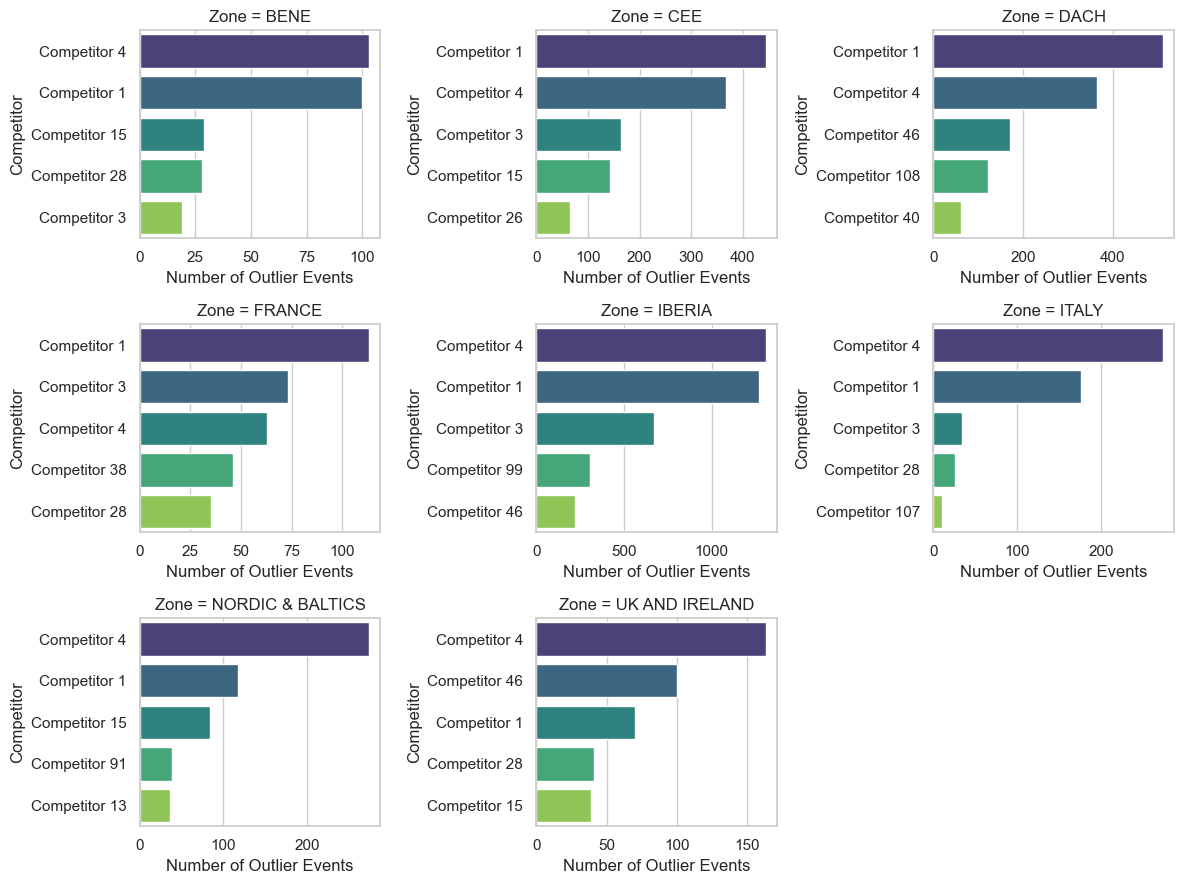

In [80]:
# Top 5 competitors for zone
top_outliers_zone = (
    outliers_df
    .groupby(["zone", "competitor"])
    .size()
    .reset_index(name="outlier_count")
    .sort_values(["zone", "outlier_count"], ascending=[True, False])
    .groupby("zone")
    .head(5)
)

zones = top_outliers_zone["zone"].unique()
n_zones = len(zones)
n_cols = 3
n_rows = math.ceil(n_zones / n_cols)

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
axes = axes.flatten()

for ax, zone in zip(axes, zones):
    data = (
        top_outliers_zone[top_outliers_zone["zone"] == zone]
        .sort_values("outlier_count", ascending=False)
    )

    sns.barplot(
        data=data,
        x="outlier_count",
        y="competitor",
        ax=ax,
        palette="viridis"
    )

    ax.set_title(f"Zone = {zone}")
    ax.set_xlabel("Number of Outlier Events")
    ax.set_ylabel("Competitor")

for i in range(len(zones), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

The zone‑specific bar plots show that extreme loss events are highly concentrated among a small number of competitors within each geographical area. In all zones, one or two competitors clearly dominate the distribution of outliers, while the remaining players contribute a much smaller number of extreme loss events.

##### 6.4.4.1.2. Value‑Based Outliers by Division

This subsection focuses on the distribution of high‑value loss events across business divisions, highlighting which competitors are most frequently involved in extreme losses within each division.

In [81]:
top_outliers_division = (
    outliers_df
    .groupby(["division", "competitor"])
    .size()
    .reset_index(name="outlier_count")
    .sort_values(["division", "outlier_count"], ascending=[True, False])
    .groupby("division")
    .head(5)
)
display(top_outliers_division)

,division,competitor,outlier_count
0,DIGITAL ENERGY,Competitor 1,301
69,DIGITAL ENERGY,Competitor 4,140
45,DIGITAL ENERGY,Competitor 3,53
22,DIGITAL ENERGY,Competitor 172,49
119,DIGITAL ENERGY,Competitor 91,39
...,...,...,...
733,SUSTAINABILITY,Competitor 183,5
734,SUSTAINABILITY,Competitor 208,2
737,SUSTAINABILITY,Competitor 45,2
738,SUSTAINABILITY,Competitor 532,2


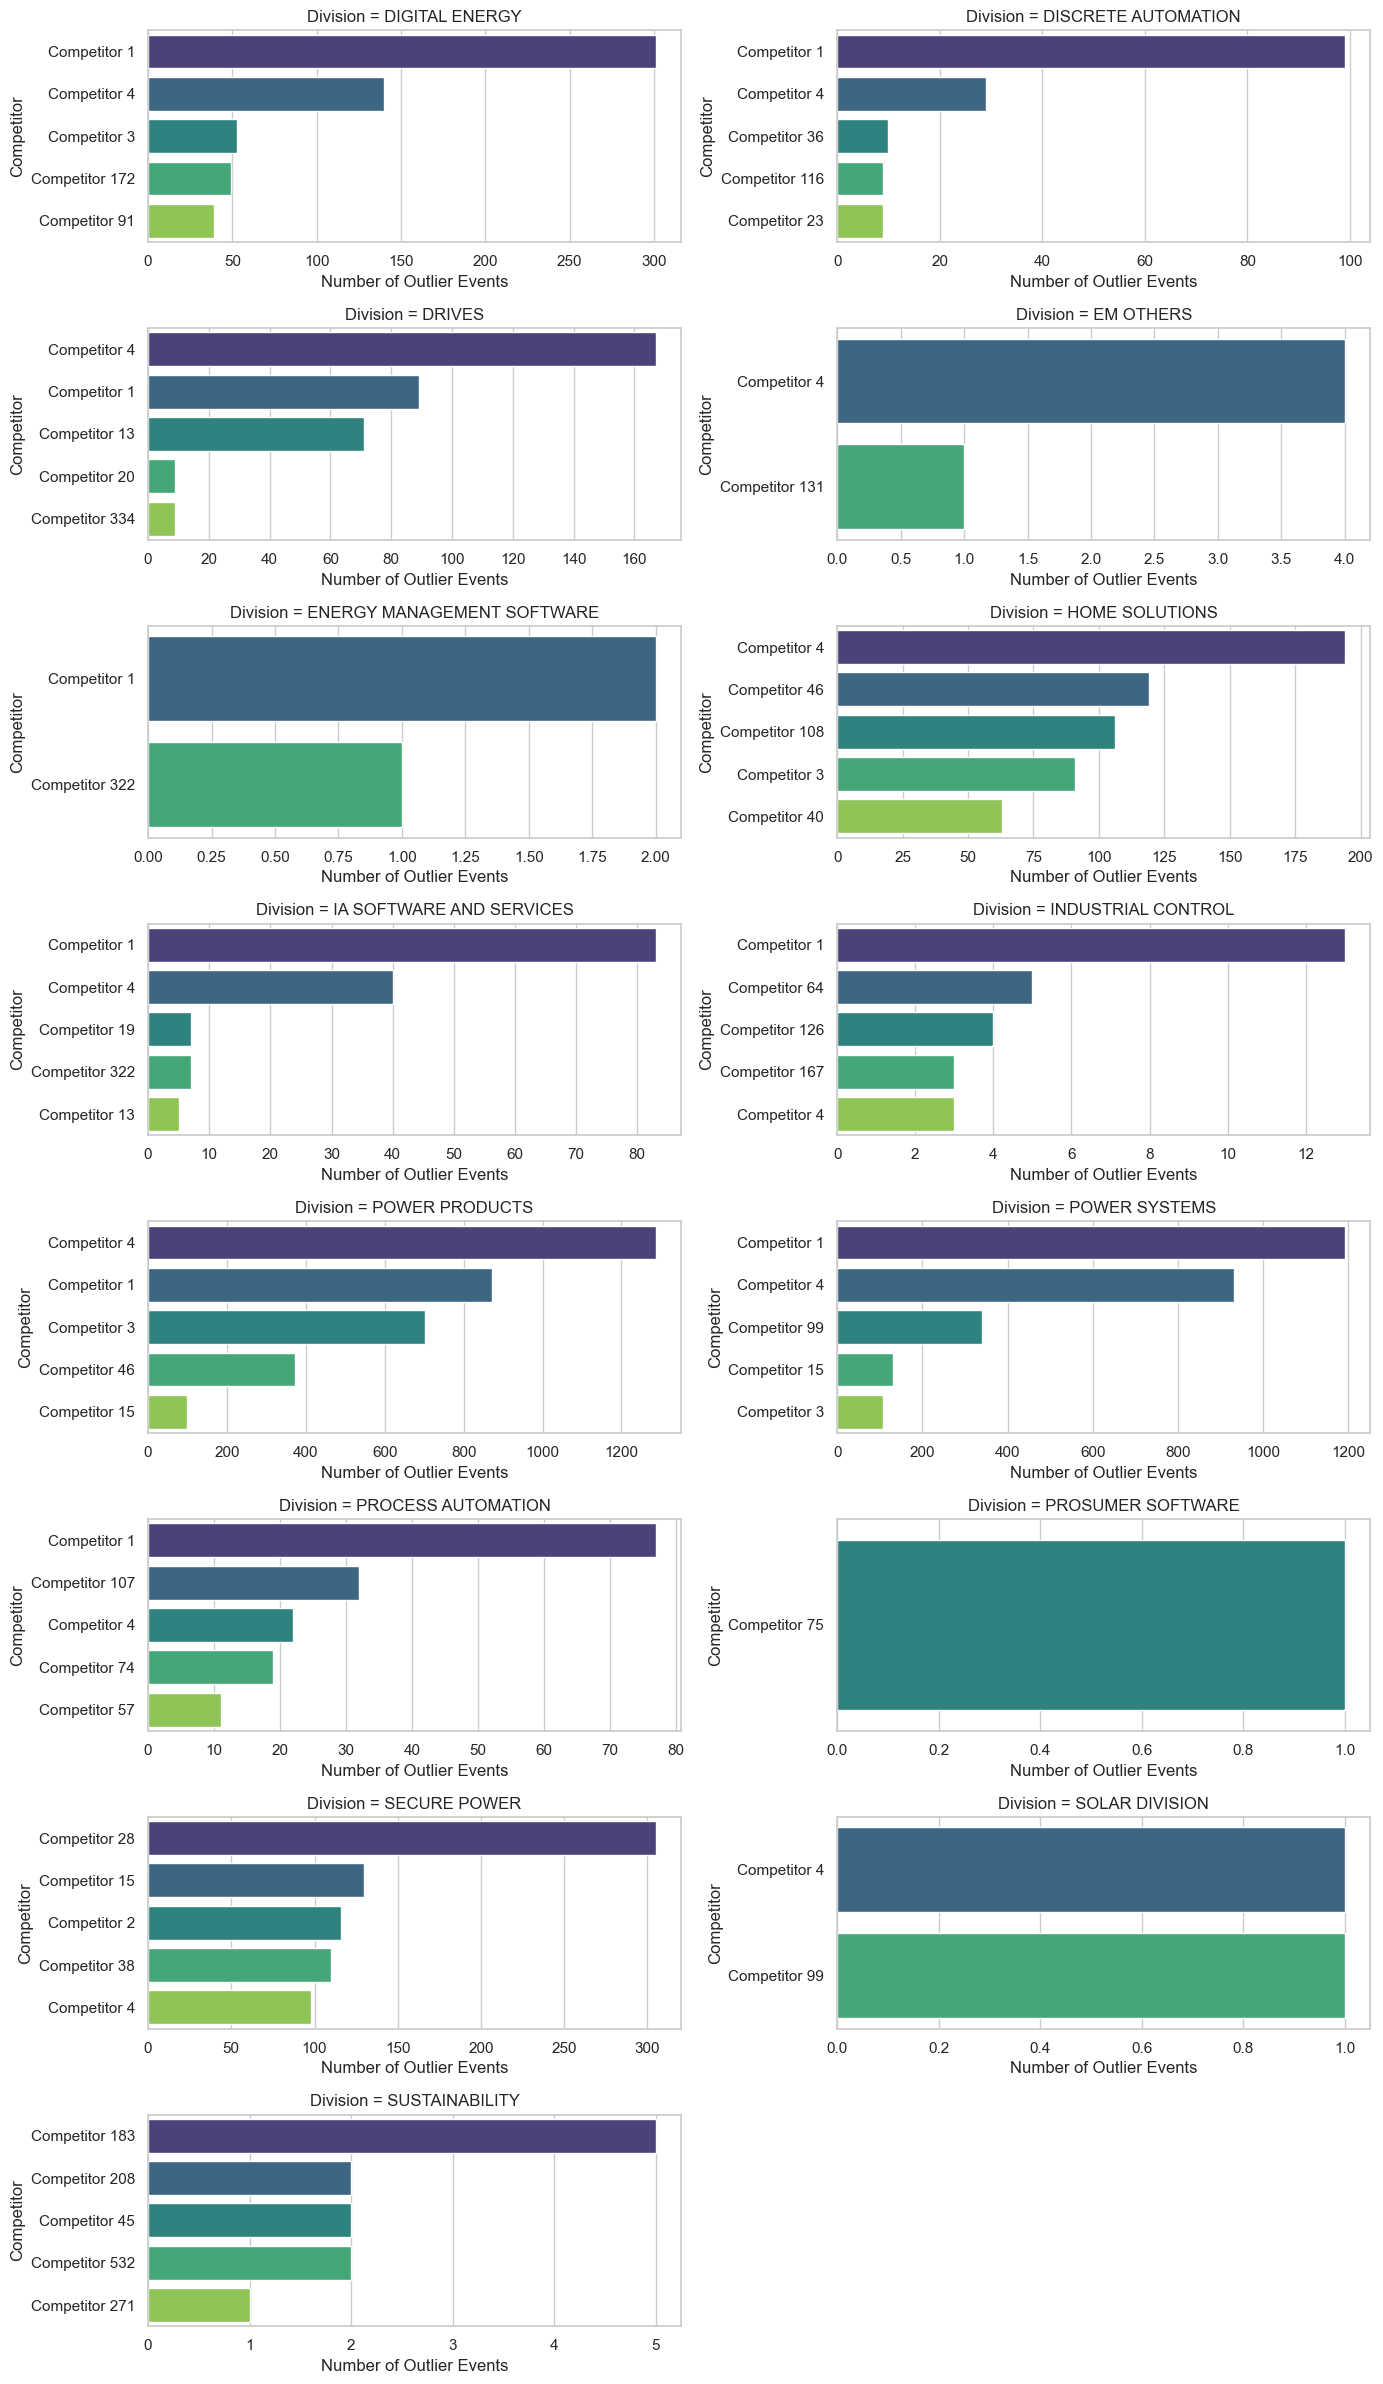

In [82]:
divisions = top_outliers_division["division"].unique()

# Layout
n_cols = 2
n_rows = math.ceil(len(divisions) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
axes = axes.flatten()

for ax, div in zip(axes, divisions):
    data = (
        top_outliers_division[top_outliers_division["division"] == div]
        .sort_values("outlier_count", ascending=False)
    )

    sns.barplot(
        data=data,
        x="outlier_count",
        y="competitor",
        ax=ax,
        palette="viridis"
    )

    ax.set_title(f"Division = {div}")
    ax.set_xlabel("Number of Outlier Events")
    ax.set_ylabel("Competitor")

for i in range(len(divisions), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

The division‑specific bar plots show that extreme loss events are highly concentrated among a small number of competitors within each business division. In most divisions, one competitor clearly dominates the number of outlier events, while the remaining competitors appear with significantly lower frequencies.

##### 6.4.4.1.3. Value‑Based Outliers by Market Segment

Here, value‑based outliers are analyzed by market segment in order to identify segments where extreme losses are most frequent and the competitors driving these events.

In [83]:
outliers_by_seg = (
    outliers_df
    .groupby(["market_segment", "competitor"])
    .size()
    .reset_index(name="outlier_count")
)
top_outliers_seg = (
    outliers_by_seg
    .sort_values(["market_segment", "outlier_count"], ascending=[True, False])
    .groupby("market_segment")
    .head(5)
)

display(top_outliers_seg)

,market_segment,competitor,outlier_count
0,AUTOMOTIVE,Competitor 1,81
243,AUTOMOTIVE,Competitor 4,33
170,AUTOMOTIVE,Competitor 3,12
415,AUTOMOTIVE,Competitor 99,10
48,AUTOMOTIVE,Competitor 15,8
...,...,...,...
7904,WATER & ENVIRONMENT,Competitor 1,205
8147,WATER & ENVIRONMENT,Competitor 4,150
7936,WATER & ENVIRONMENT,Competitor 13,20
8319,WATER & ENVIRONMENT,Competitor 99,18


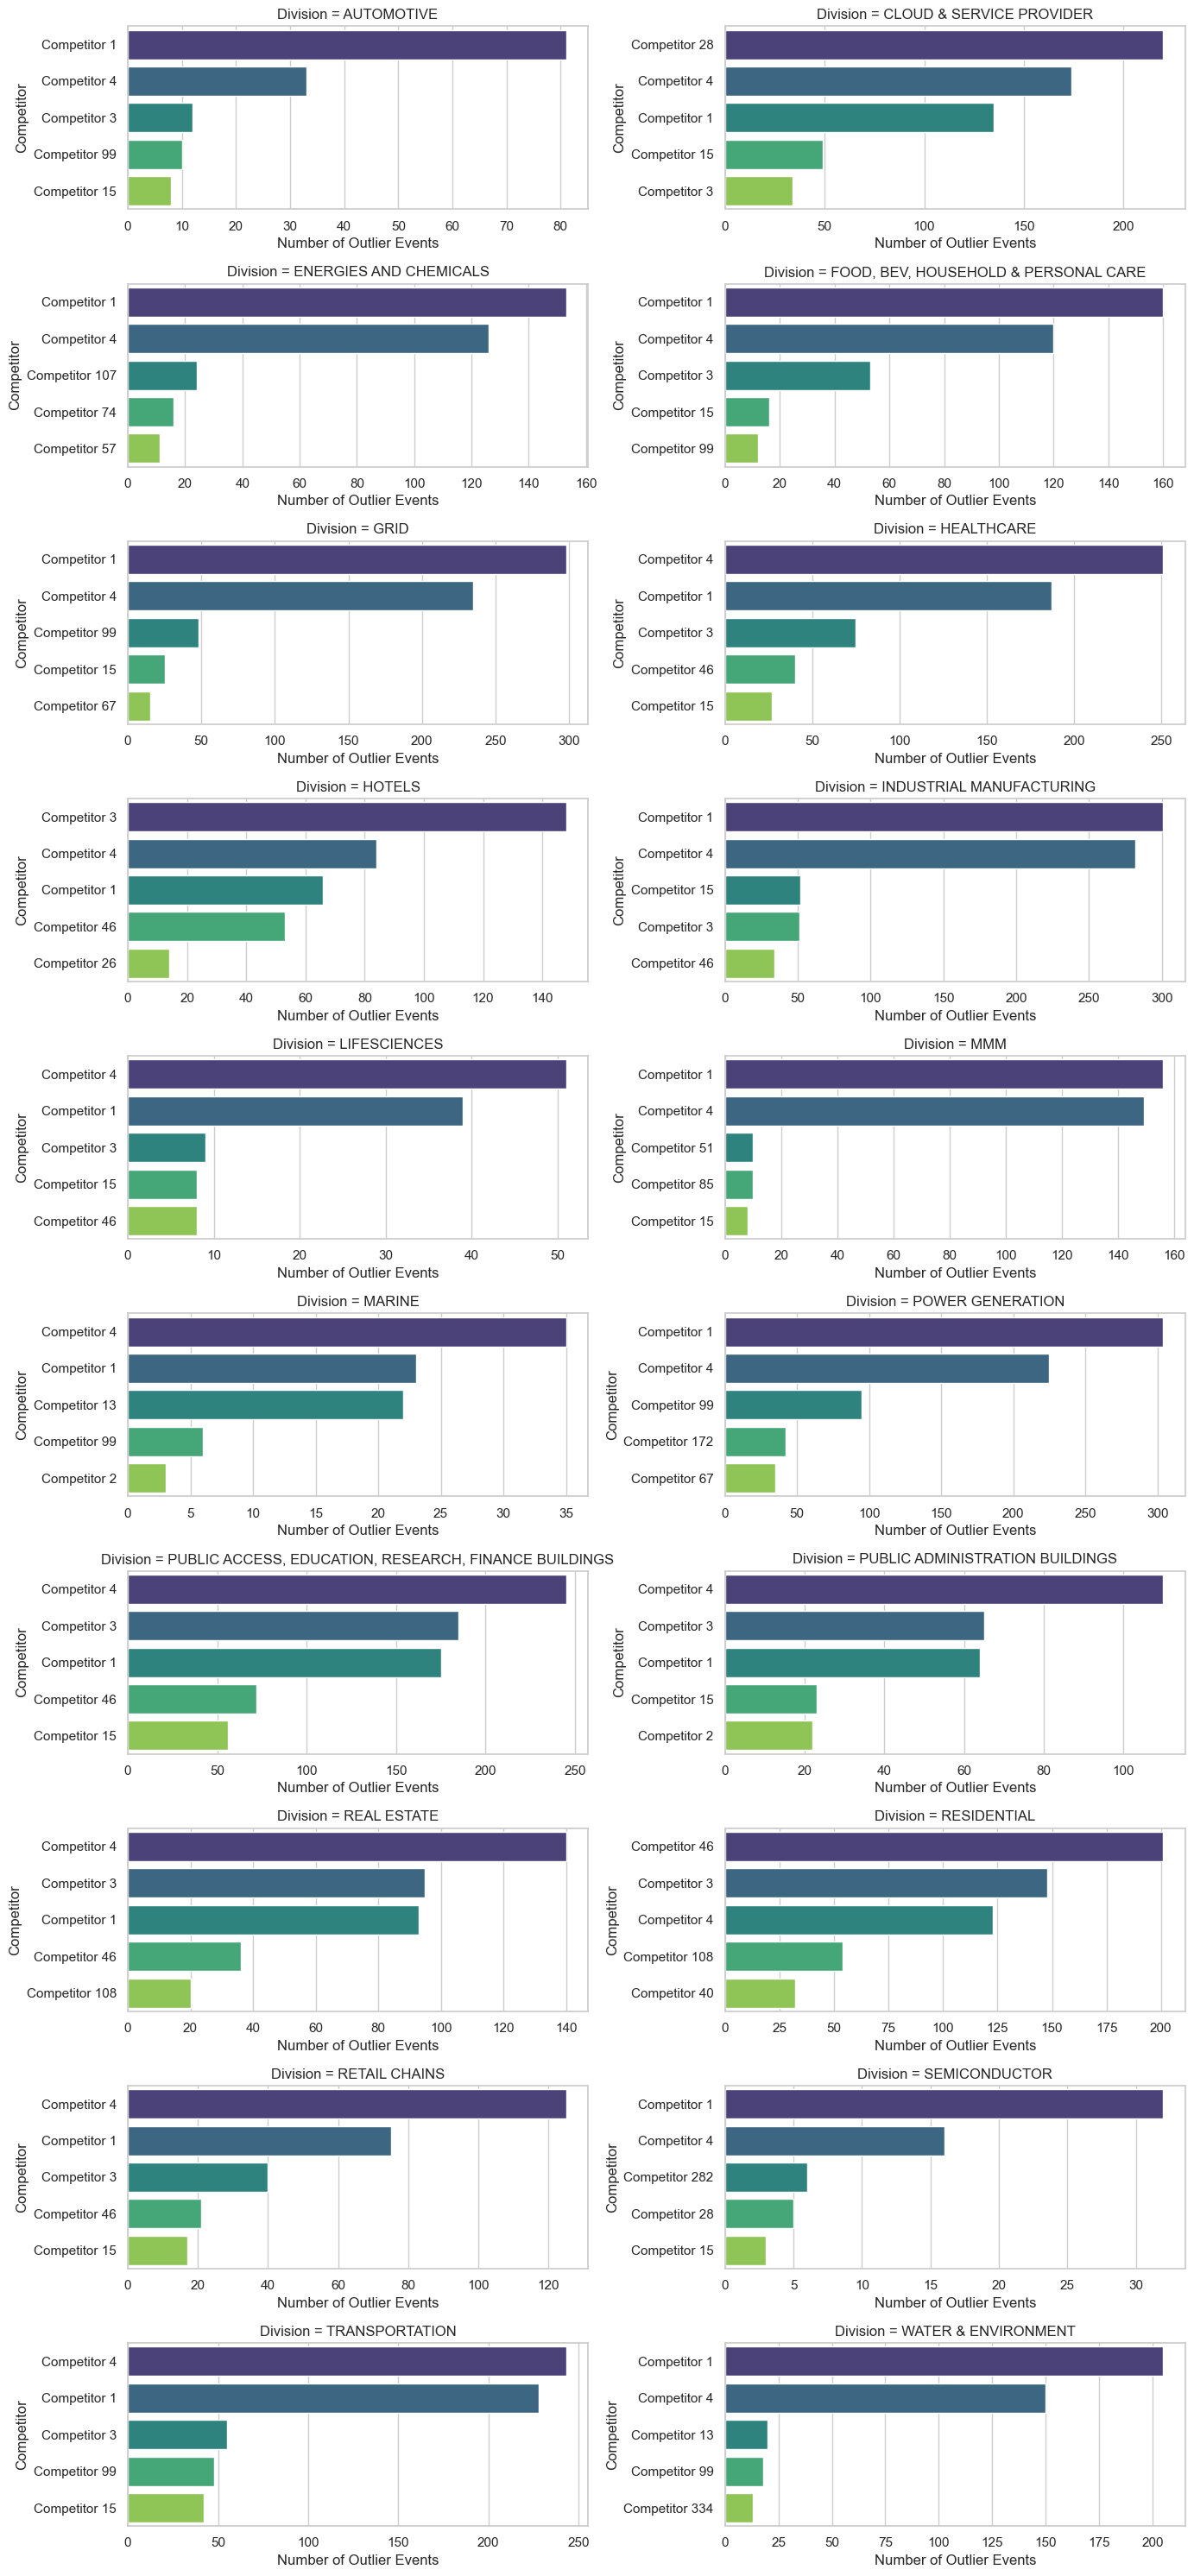

In [84]:
market = top_outliers_seg["market_segment"].unique()

# Layout
n_cols = 2
n_rows = math.ceil(len(market) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
axes = axes.flatten()

for ax, div in zip(axes, market):
    data = (
        top_outliers_seg[top_outliers_seg["market_segment"] == div]
        .sort_values("outlier_count", ascending=False)
    )

    sns.barplot(
        data=data,
        x="outlier_count",
        y="competitor",
        ax=ax,
        palette="viridis"
    )

    ax.set_title(f"Division = {div}")
    ax.set_xlabel("Number of Outlier Events")
    ax.set_ylabel("Competitor")

for i in range(len(market), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

The market‑segment‑specific bar plots show that extreme loss events are strongly concentrated among a very limited number of competitors within each segment. In most market segments, one or two competitors clearly dominate the number of outlier events, while the remaining competitors appear with significantly lower frequencies.

##### 6.4.4.2. Frequency‑Based Competitive Outliers

In addition to value‑based outliers, we analyze frequency‑based competitive outliers. In this case, outliers are defined as competitors that appear disproportionately often within a given zone or division, independently of the monetary value of individual losses.

##### 6.4.4.2.1. Frequency‑Based Outliers by Zone

This subsection identifies competitors that exhibit unusually high presence within specific zones, relative to other competitors operating in the same geographical context.

In [85]:
freq_zone = (
    df_clean
    .groupby(["zone", "competitor"])
    .size()
    .reset_index(name="count")
)
# Pareto 
def pareto_filter(group, threshold=0.8):
    group = group.sort_values("count", ascending=False)
    group["cum_share"] = group["count"].cumsum() / group["count"].sum()
    return group[group["cum_share"] <= threshold]

zone_pareto_competitors = (
    freq_zone
    .groupby("zone")
    .apply(pareto_filter)
)

zone_pareto_competitors = zone_pareto_competitors.reset_index(drop=True)

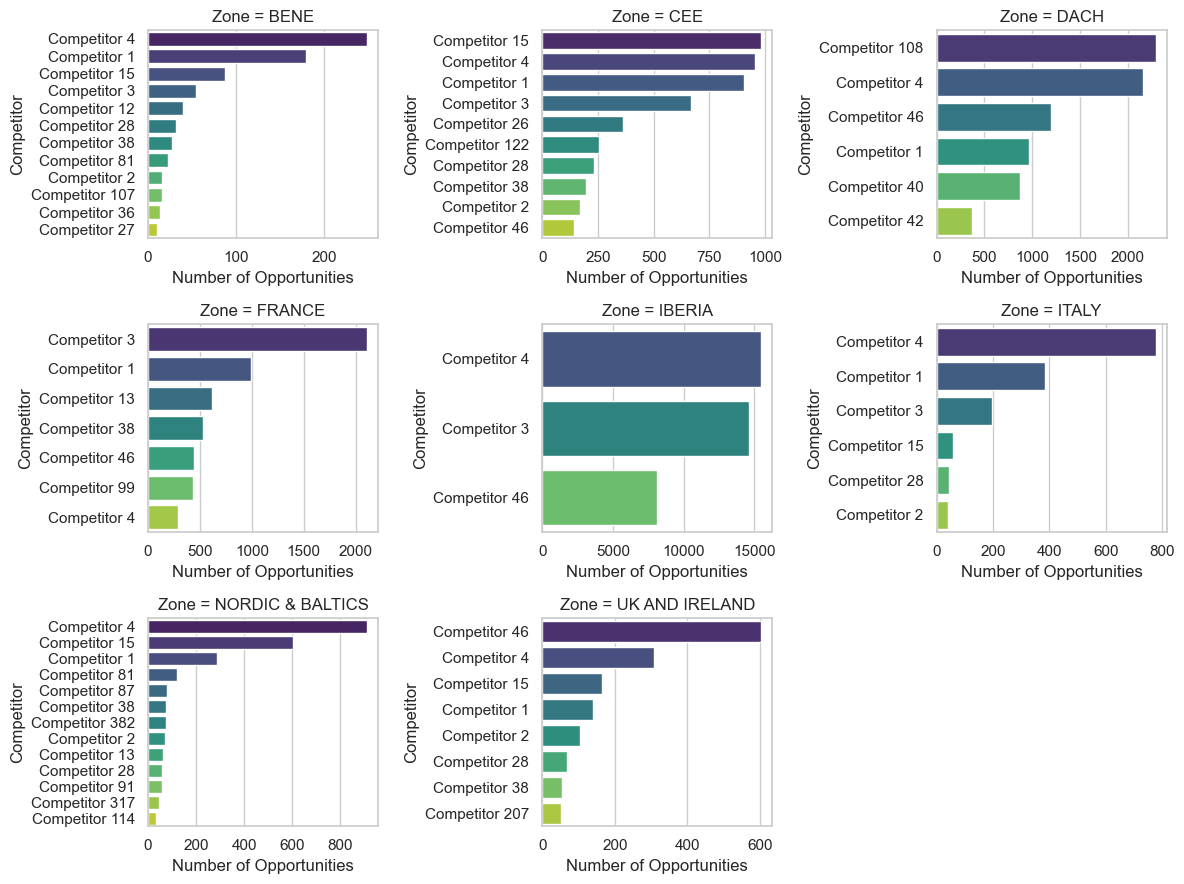

In [86]:
zones = zone_pareto_competitors["zone"].unique()
n_cols = 3
n_rows = math.ceil(len(zones) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
axes = axes.flatten()

for ax, zone in zip(axes, zones):
    data = (
        zone_pareto_competitors[
            zone_pareto_competitors["zone"] == zone
        ]
        .sort_values("count", ascending=False)
    )

    sns.barplot(
        data=data,
        x="count",
        y="competitor",
        ax=ax,
        palette="viridis"
    )

    ax.set_title(f"Zone = {zone}")
    ax.set_xlabel("Number of Opportunities")
    ax.set_ylabel("Competitor")

for i in range(len(zones), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Iberia stands out as a highly concentrated market, where competitive activity is overwhelmingly dominated by one or two competitors.
Zones such as DACH and CEE display a more balanced distribution of competitive activity among several key competitors.
Regions such as France, Italy, Nordic & Baltics, and UK & Ireland show hybrid structures, combining a clear leading competitor with a group of secondary players that retain significant presence.

**Emerging Competitors by Zone**

This table summarizes emerging competitors by aggregating frequency‑based local outliers across zones, showing both the number of zones in which each competitor appears as an outlier and their total frequency, in order to identify competitors with strong localized or multi‑regional emerging presence.

In [87]:
# Emerging competitors list
emerging_competitors = df_emerging["competitor"].unique()

# Keep only emerging competitors in division Pareto results
zone_freq_emerging = zone_pareto_competitors[
    zone_pareto_competitors["competitor"].isin(emerging_competitors)
]

# Summary table by competitor
emerging_zone_summary = (
    zone_freq_emerging
    .groupby("competitor")
    .agg(
        zones_present=("zone", "nunique"),
        total_count=("count", "sum")
    )
    .sort_values("total_count", ascending=False)
)

display(emerging_zone_summary)

,zones_present,total_count
competitor,,
Competitor 13,2,678
Competitor 28,5,435
Competitor 2,5,399
Competitor 42,1,366
Competitor 26,1,364
Competitor 122,1,253
Competitor 81,2,143
Competitor 87,1,77
Competitor 382,1,73


##### 6.4.4.2.2. Frequency‑Based Outliers by Division

This subsection focuses on competitors that appear with unusually high frequency within specific business divisions, highlighting division‑specific competitive concentration patterns.

In [88]:
freq_division = (
    df_clean
    .groupby(["division", "competitor"])
    .size()
    .reset_index(name="count")
)

# Pareto 
def pareto_filter(group, threshold=0.8):
    group = group.sort_values("count", ascending=False)
    group["cum_share"] = group["count"].cumsum() / group["count"].sum()
    return group[group["cum_share"] <= threshold]

division_pareto_competitors = (
    freq_division
    .groupby("division")
    .apply(pareto_filter)
)

division_pareto_competitors = division_pareto_competitors.reset_index(drop=True)

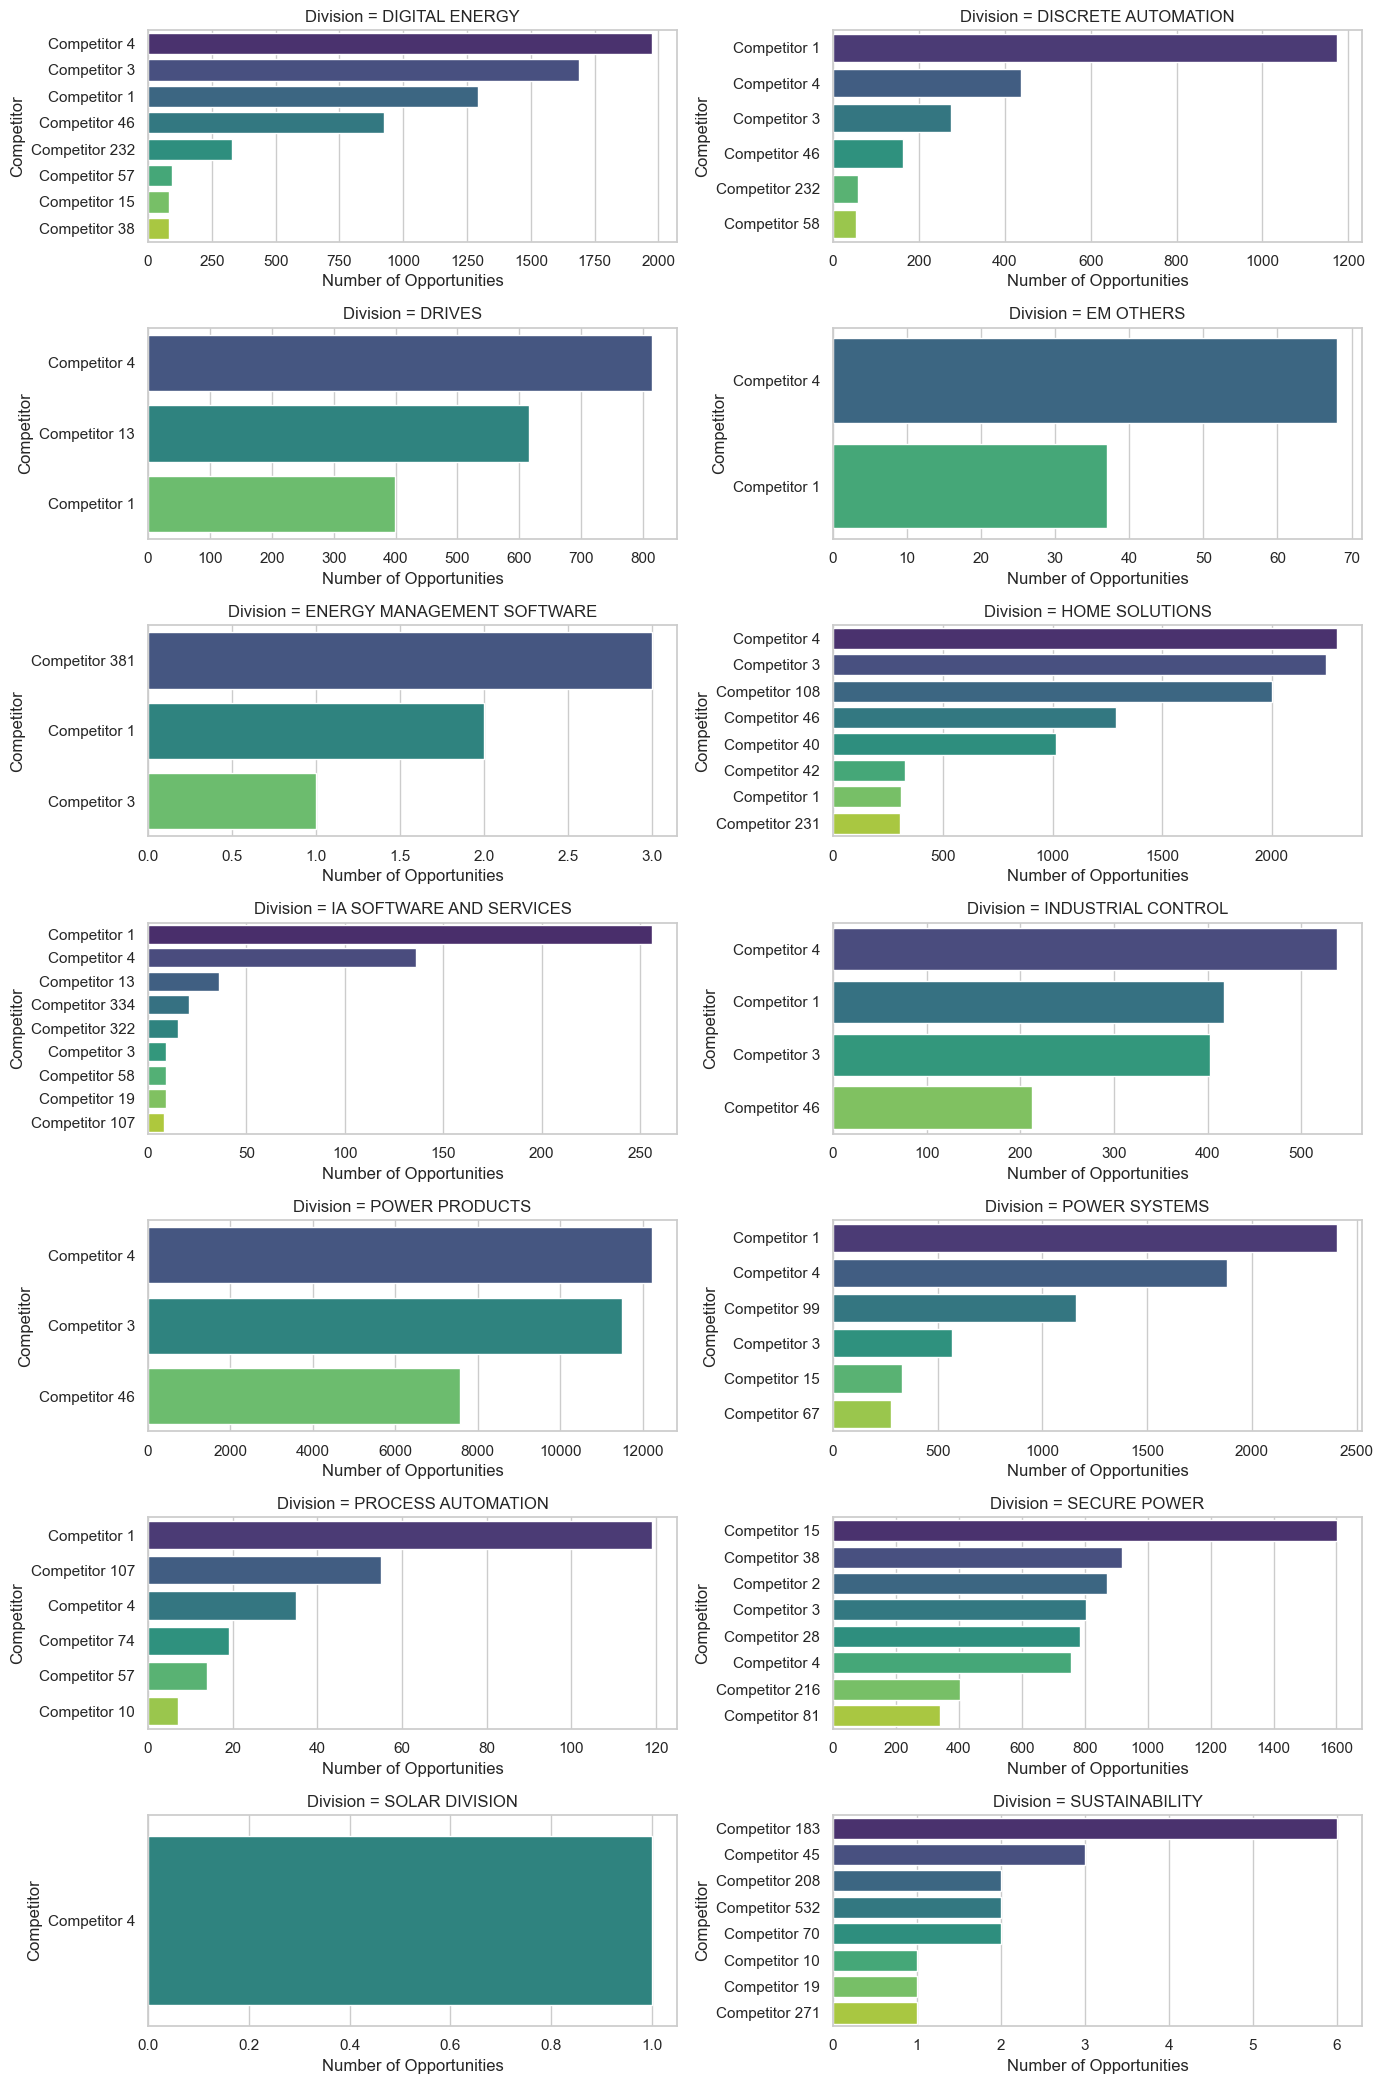

In [89]:
divisions = division_pareto_competitors["division"].unique()

n_cols = 2
n_rows = math.ceil(len(divisions) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 3 * n_rows)
)

axes = axes.flatten()

for ax, div in zip(axes, divisions):
    data = (
        division_pareto_competitors[
            division_pareto_competitors["division"] == div
        ]
        .sort_values("count", ascending=False)
    )

    sns.barplot(
        data=data,
        x="count",
        y="competitor",
        ax=ax,
        palette="viridis"
    )

    ax.set_title(f"Division = {div}")
    ax.set_xlabel("Number of Opportunities")
    ax.set_ylabel("Competitor")


for i in range(len(divisions), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

The division‑level analysis reveals strong competitive concentration within most business divisions. In each division, a limited set of competitors accounts for the majority of occurrences, indicating sustained and focused competitive presence.

**Emerging Competitors by Division**

This table summarizes emerging competitors based on frequency‑based Pareto outliers by division, showing the number of divisions in which each competitor appears as a local outlier and their total frequency. This highlights competitors with strong division‑specific or cross‑division emerging presence.

In [90]:
# Emerging competitors list
emerging_competitors = df_emerging["competitor"].unique()

# Keep only emerging competitors in division Pareto results
division_freq_emerging = division_pareto_competitors[
    division_pareto_competitors["competitor"].isin(emerging_competitors)
]

# Summary table by competitor
emerging_division_summary = (
    division_freq_emerging
    .groupby("competitor")
    .agg(
        divisions_present=("division", "nunique"),
        total_count=("count", "sum")
    )
    .sort_values("total_count", ascending=False)
)

display(emerging_division_summary)

,divisions_present,total_count
competitor,,
Competitor 2,1,872
Competitor 28,1,786
Competitor 13,2,651
Competitor 216,1,402
Competitor 232,2,385
Competitor 81,1,341
Competitor 42,1,327
Competitor 231,1,305
Competitor 67,1,279


##### 6.4.4.2.3. Frequency‑Based Outliers by Market Segment

This subsection focuses on competitors that appear with unusually high frequency within specific market segments, highlighting segment‑specific patterns of competitive concentration.

In [91]:
freq_segment = (
    df_clean
    .groupby(["market_segment", "competitor"])
    .size()
    .reset_index(name="count")
)

# Pareto
def pareto_filter(group, threshold=0.8):
    group = group.sort_values("count", ascending=False)
    group["cum_share"] = group["count"].cumsum() / group["count"].sum()
    return group[group["cum_share"] <= threshold]

segment_pareto_competitors = (
    freq_segment
    .groupby("market_segment")
    .apply(pareto_filter)
)

segment_pareto_competitors = (
    segment_pareto_competitors
    .reset_index(drop=True)
)

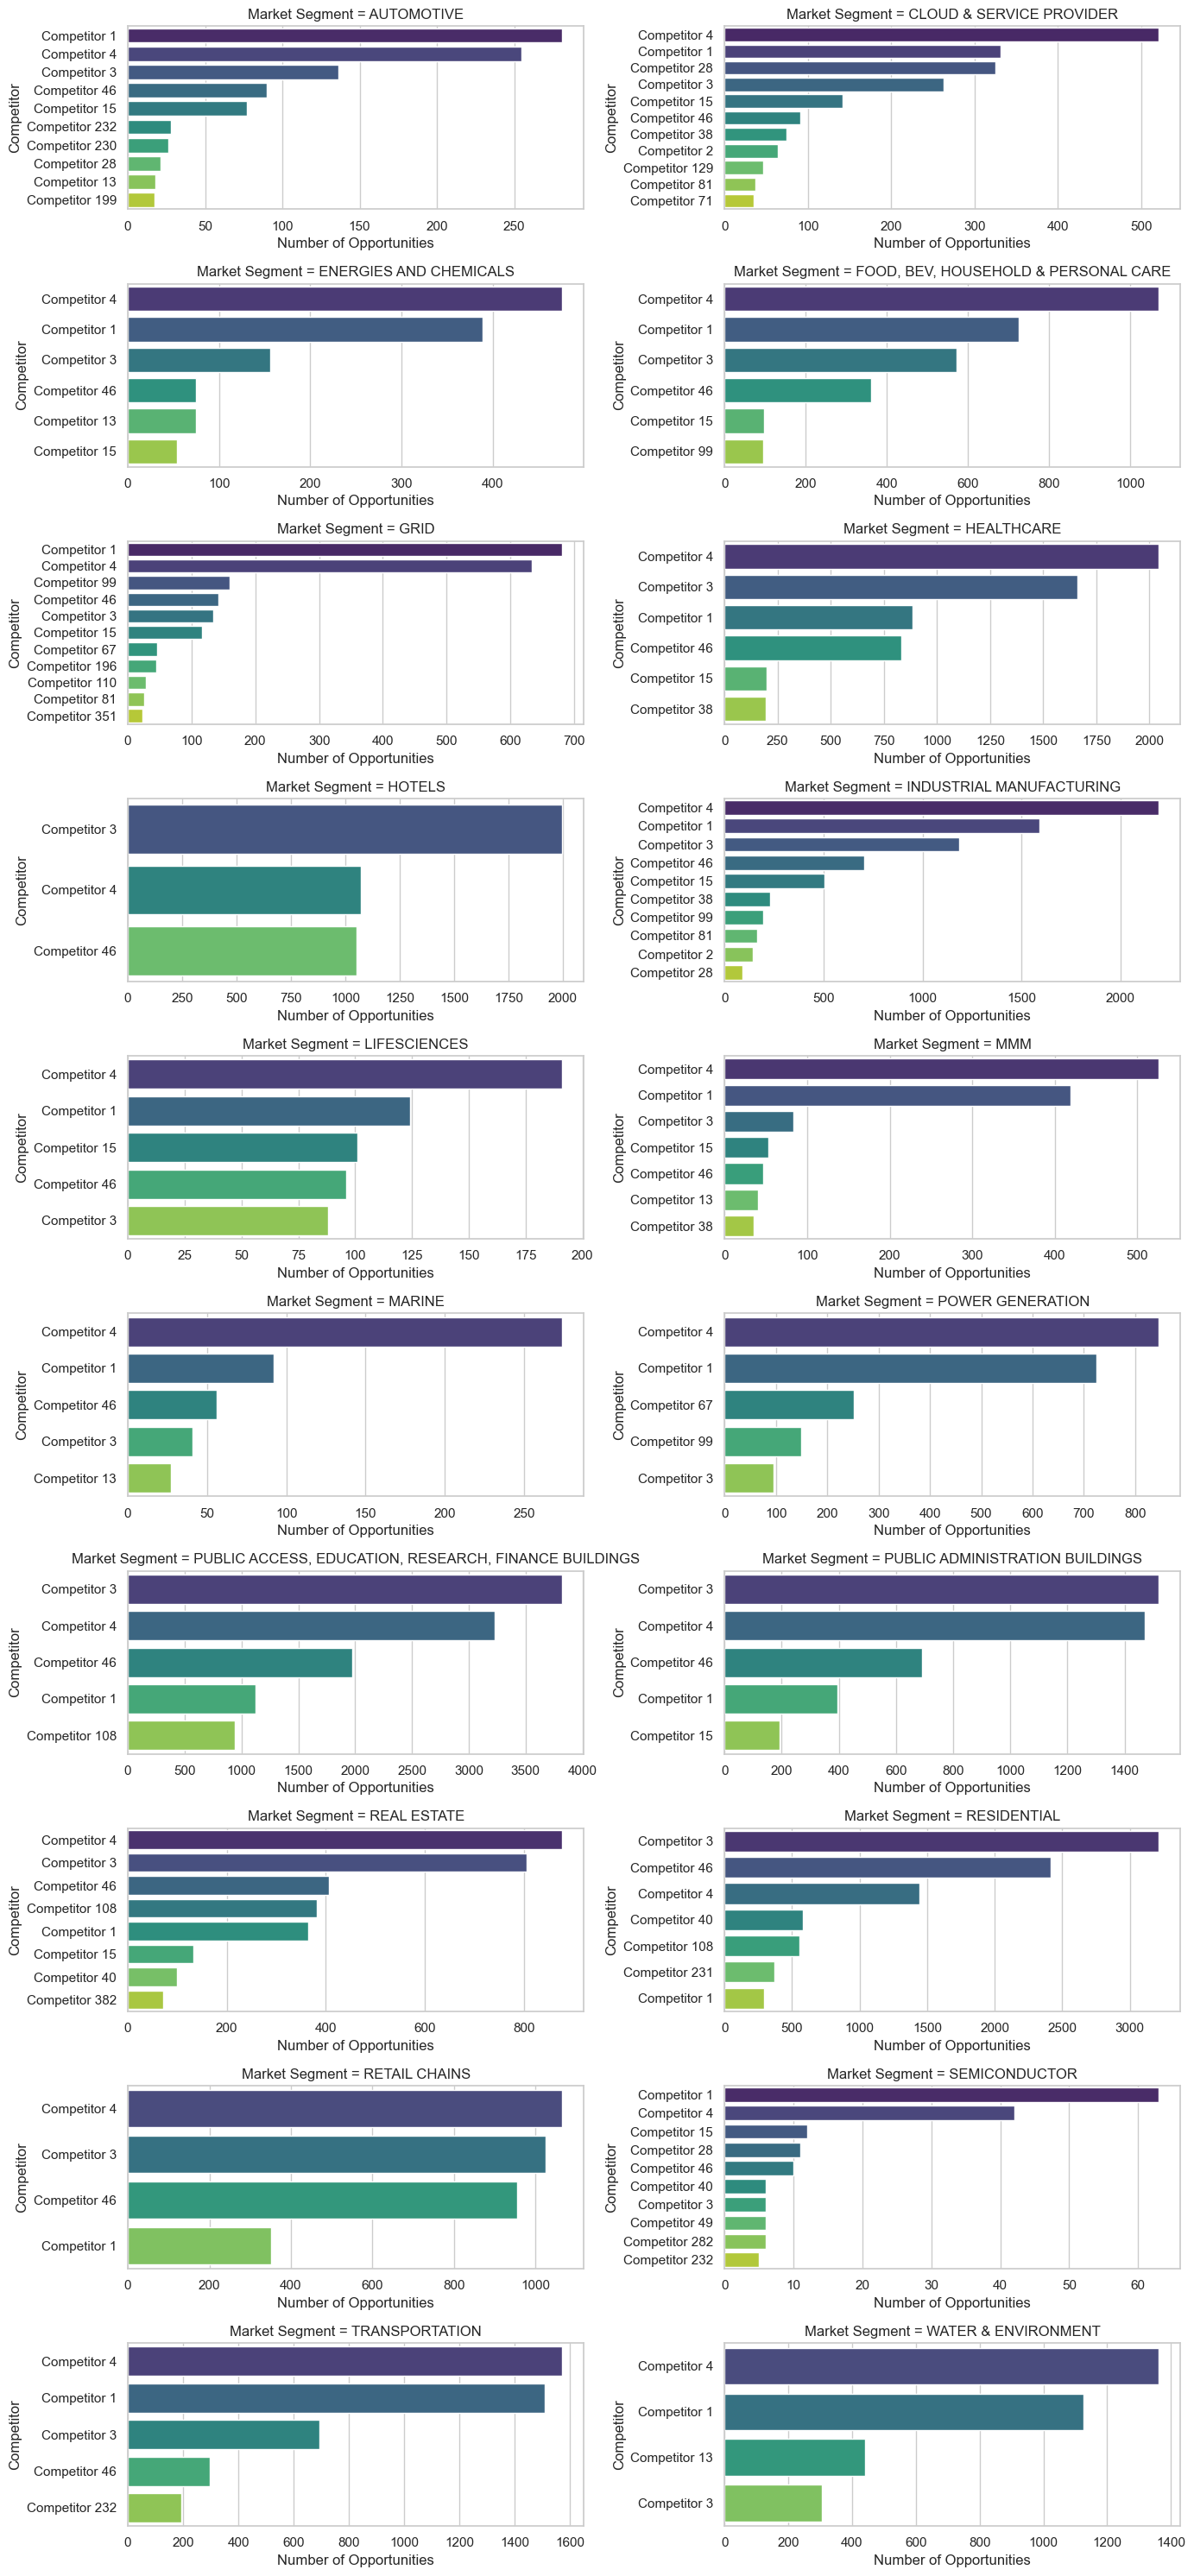

In [92]:
segments = segment_pareto_competitors["market_segment"].unique()

n_cols = 2
n_rows = math.ceil(len(segments) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 3 * n_rows)
)

axes = axes.flatten()

for ax, seg in zip(axes, segments):
    data = (
        segment_pareto_competitors[
            segment_pareto_competitors["market_segment"] == seg
        ]
        .sort_values("count", ascending=False)
    )

    sns.barplot(
        data=data,
        x="count",
        y="competitor",
        ax=ax,
        palette="viridis"
    )

    ax.set_title(f"Market Segment = {seg}")
    ax.set_xlabel("Number of Opportunities")
    ax.set_ylabel("Competitor")

for i in range(len(segments), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

The market‑segment‑level bar plots show that competitive activity is highly concentrated within each segment, with a small number of competitors accounting for the majority of opportunities. In most segments, one dominant competitor clearly leads in frequency, followed by a limited number of secondary players.

**Emerging Competitors by Market Segment**

This table aggregates frequency‑based Pareto outliers by market segment for emerging competitors, indicating the number of segments in which each competitor exhibits unusually high presence and their overall frequency across segments.

In [93]:
# Keep only emerging competitors in market segment Pareto results
segment_freq_emerging = segment_pareto_competitors[
    segment_pareto_competitors["competitor"].isin(emerging_competitors)
]

# Summary table by competitor
emerging_segment_summary = (
    segment_freq_emerging
    .groupby("competitor")
    .agg(
        segments_present=("market_segment", "nunique"),
        total_count=("count", "sum")
    )
    .sort_values("total_count", ascending=False)
)

display(emerging_segment_summary)

,segments_present,total_count
competitor,,
Competitor 13,5,602
Competitor 28,4,447
Competitor 231,1,372
Competitor 67,2,298
Competitor 81,3,228
Competitor 232,3,226
Competitor 2,2,205
Competitor 382,1,72
Competitor 129,1,46


## 7. Feature Engineering

Here, we change our approach: instead of looking at single opportunities, we group the data by competitor. We also incorporate the insights from our EDA, like the market segments and divisions each competitor covers. For this part, we decided to focus entirely on the Iberia region. Because the vast majority of our historical records are from there, zooming in on Iberia gives us a robust dataset, removes noise from smaller markets, and ultimately ensures that our statistical model is solid. 

In [ ]:
# Filter Iberia 
df_ib_raw = df_clean[df_clean['zone'] == 'IBERIA'].copy()
comp_counts = df_ib_raw['competitor'].value_counts()

cutoff = comp_counts[comp_counts.cumsum() / len(df_ib_raw) >= 0.8].index[0]
giants = comp_counts.loc[:cutoff].index.tolist()
noise = comp_counts[comp_counts == 1].index.tolist()

df_ib = df_ib_raw[~df_ib_raw['competitor'].isin(giants + noise)].copy()

# Base Matrix & Financials
df_model_iberia = df_ib.groupby('competitor')['lost_amount'].sum().reset_index(name='total_lost_amount')

# Strategic Metrics 
segments = segment_pareto_competitors.groupby('competitor').agg(
    market_segments_present=('market_segment', 'size'),
    market_segment_names=('market_segment', lambda x: ', '.join(x))
).reset_index()

divisions = division_pareto_competitors.groupby('competitor').agg(
    divisions_present=('division', 'size'),
    division_names=('division', lambda x: ', '.join(x))
).reset_index()

df_model_iberia = df_model_iberia.merge(segments, on='competitor', how='left') \
                                 .merge(divisions, on='competitor', how='left')

df_model_iberia.fillna({
    'market_segments_present': 0, 'divisions_present': 0,
    'market_segment_names': 'None', 'division_names': 'None'
}, inplace=True)

print(f"Total competitors in the base matrix: {len(df_model_iberia)}")
display(df_model_iberia.head())

### 7.1. Growth Velocity Metrics

This code transforms raw historical data into a strategic feature matrix to identify true emerging competitors. It measures each competitor's long-term growth speed, recent win momentum, and market expansion, while applying a statistical penalty to filter out 'fake growth' noise from irrelevant companies with very few projects.

In [95]:
from scipy.stats import linregress

df_ib['close_date'] = pd.to_datetime(df_ib['close_date'])
current_date = df_ib['close_date'].max()

df_ib['time_period'] = df_ib['close_date_year'].astype(str) + "-Q" + df_ib['close_date_quarter'].astype(str)

# Money and Total Projects per Quarter 
quarterly_data = df_ib.groupby(['competitor', 'time_period']).agg(
    lost_amount=('lost_amount', 'sum'),
    opp_count=('id_', 'count')
).reset_index().sort_values(['competitor', 'time_period'])


# Long-term Growth Speed
def calculate_trajectory(group):
    amounts = group['lost_amount'].values
    if len(amounts) < 2:
        return pd.Series({'avg_log_growth': 0.0, 'trend_slope': 0.0})
    
    # Logarithmic growth 
    log_growth = np.log(amounts[1:] + 1) - np.log(amounts[:-1] + 1)
    avg_lg = np.mean(log_growth)
    
    # Linear slope to evaluate acceleration
    time_index = np.arange(len(amounts))
    slope, _, _, _, _ = linregress(time_index, amounts)
    
    return pd.Series({'avg_log_growth': avg_lg, 'trend_slope': slope})

trajectory_metrics = quarterly_data.groupby('competitor').apply(calculate_trajectory).reset_index()


# Recent Activity 
pivot_counts = quarterly_data.pivot(index='competitor', columns='time_period', values='opp_count').fillna(0)
periods = pivot_counts.columns.tolist()

last_1Q = periods[-1:]
last_3Q = periods[-3:] if len(periods) >= 3 else periods
last_6Q = periods[-6:] if len(periods) >= 6 else periods

pivot_counts['apps_last_1Q'] = pivot_counts[last_1Q].sum(axis=1)
pivot_counts['apps_last_3Q'] = pivot_counts[last_3Q].sum(axis=1)
pivot_counts['apps_last_6Q'] = pivot_counts[last_6Q].sum(axis=1)

frequency_metrics = pivot_counts[['apps_last_1Q', 'apps_last_3Q', 'apps_last_6Q']].reset_index()


# Active or Expanding 
strategic_metrics = df_ib.groupby('competitor').agg(
    last_win_date=('close_date', 'max'),
    total_projects=('id_', 'count'),
    unique_segments=('market_segment', 'nunique'),
    unique_divisions=('division', 'nunique')
).reset_index()

strategic_metrics['inactive_months'] = (current_date - strategic_metrics['last_win_date']).dt.days / 30.44

strategic_metrics['expansion_index'] = strategic_metrics['unique_segments'] + strategic_metrics['unique_divisions']


# Filter "Fake" Growth 
df_model_iberia = pd.merge(df_model_iberia, trajectory_metrics, on='competitor', how='left')
df_model_iberia = pd.merge(df_model_iberia, frequency_metrics, on='competitor', how='left')
df_model_iberia = pd.merge(df_model_iberia, strategic_metrics[['competitor', 'total_projects', 'inactive_months', 'expansion_index']], on='competitor', how='left')

fill_zero_cols = ['avg_log_growth', 'trend_slope', 'apps_last_1Q', 'apps_last_3Q', 'apps_last_6Q', 'total_projects', 'expansion_index']
df_model_iberia[fill_zero_cols] = df_model_iberia[fill_zero_cols].fillna(0)
df_model_iberia['inactive_months'] = df_model_iberia['inactive_months'].fillna(999) 

# Slope of competitors with very few total projects
df_model_iberia['confidence_factor'] = np.log1p(df_model_iberia['total_projects'])
df_model_iberia['adjusted_trend_slope'] = df_model_iberia['trend_slope'] * df_model_iberia['confidence_factor']

display_cols = ['competitor', 'adjusted_trend_slope', 'apps_last_1Q','apps_last_3Q','apps_last_6Q', 'inactive_months', 'expansion_index']
display(df_model_iberia.sort_values(by='adjusted_trend_slope', ascending=False)[display_cols].head(10))

,competitor,adjusted_trend_slope,apps_last_1Q,apps_last_3Q,apps_last_6Q,inactive_months,expansion_index
113,Competitor 397,5.290730e+06,8.0,8.0,12.0,0.328515,6
86,Competitor 342,1.292737e+06,3.0,3.0,3.0,0.328515,4
16,Competitor 141,9.904097e+05,3.0,9.0,14.0,0.098555,13
43,Competitor 232,6.594562e+05,22.0,352.0,795.0,0.229961,28
11,Competitor 126,6.363149e+05,0.0,2.0,9.0,1.609724,5
7,Competitor 115,5.273339e+05,0.0,0.0,1.0,16.195795,3
169,Competitor 537,5.068474e+05,1.0,1.0,1.0,1.346912,2
198,Competitor 67,5.054861e+05,38.0,134.0,254.0,0.197109,18
159,Competitor 513,4.610178e+05,0.0,2.0,5.0,5.880420,2
9,Competitor 120,3.360755e+05,0.0,1.0,1.0,2.069645,3


### 7.2. Defining the Target: What Makes a Competitor "Emerging"?

To train our statistical models, we must translate the business concept of an "emerging threat" into a strict mathematical rule. We classify a competitor as a real threat (`Target = 1`) only if they sit in the top 20% of the fastest-growing companies in Iberia and have actively won at least 3 projects recently. The rest are classified as stagnant (`Target = 0`).

In [96]:
# 1 = Emerging, 0 = Stagnant

# Calculate the cutoff point: Top 20% of the fastest-growing competitors
growth_threshold = df_model_iberia['adjusted_trend_slope'].quantile(0.80)

df_model_iberia['is_emerging'] = np.where(
    (df_model_iberia['adjusted_trend_slope'] >= growth_threshold) & 
    (df_model_iberia['apps_last_3Q'] >= 3), 
    1, 0
)

target_distribution = df_model_iberia['is_emerging'].value_counts().reset_index()
target_distribution.columns = ['is_emerging', 'count']
display(target_distribution)

,is_emerging,count
0,0,185
1,1,27


Looking at this final distribution, we now have a highly realistic picture of the market. Out of our target group, 175 competitors are classified as stagnant (0), while exactly 27 have been identified as true emerging threats (1).

Statistically, this creates the ideal baseline for our Logistic Regression. With a clear 13% minority, the algorithm avoids "false alarms" and can focus entirely on identifying the mathematical patterns of these 27 dangerous competitors.

### 7.3. Statistical Validation of the Emerging Competitor Profile

Before feeding these labels into the statistical model, we perform a sanity check. We contrast the statistical behavior of our 27 "emerging" competitors against the "stagnant" majority. If our logic is sound, the `Target = 1` group should naturally show a significantly higher financial impact, faster acceleration, and broader market penetration.

In [97]:
# Target Validation and Contrast Statistics
control_df = df_model_iberia[
    (df_model_iberia['is_emerging'] == 1) & 
    ((df_model_iberia['market_segments_present'] > 0) | (df_model_iberia['divisions_present'] > 0))
]

display(control_df[['competitor', 'adjusted_trend_slope', 'market_segments_present', 'divisions_present']].head(10))

summary_stats = df_model_iberia.groupby('is_emerging').agg({
    'adjusted_trend_slope': ['mean', 'median'],
    'apps_last_3Q': 'mean',
    'market_segments_present': ['mean', 'max', 'count'],
    'total_lost_amount': 'median'
})

display(summary_stats)

,competitor,adjusted_trend_slope,market_segments_present,divisions_present
3,Competitor 108,95536.269494,3.0,1.0
42,Competitor 231,283497.323891,1.0,1.0
43,Competitor 232,659456.180775,3.0,2.0
105,Competitor 38,239528.817522,4.0,2.0
185,Competitor 57,204660.135658,0.0,2.0
198,Competitor 67,505486.076686,2.0,1.0


adjusted_trend_slope                apps_last_3Q  \
                            mean         median         mean   
is_emerging                                                    
0                  -43730.269632       0.000000    11.594595   
1                  451609.537623  147408.133405    43.148148   

            market_segments_present             total_lost_amount  
                               mean   max count            median  
is_emerging                                                        
0                          0.200000  12.0   185         237900.37  
1                          0.481481   4.0    27        1691825.57

### 7.4. Conclusion: A Clear Baseline for Modeling

The contrast statistics confirm that our defined classes represent two completely different market behaviors. We can highlight three critical differences:
1. **Explosive Growth vs. Decline:** The emerging group (1) displays a massive positive growth slope (a mean of +451k), while the stagnant group (0) is actually shrinking on average (-43k).
2. **Aggressive Recent Activity:** The emerging competitors are practically 4 times more active right now, with an average of 43 recent appearances compared to just 11 for the stagnant group.
3. **Financial Weight:** The median financial impact of an emerging competitor is **€1.69 million**, which is 7 times larger than a stagnant one (€237k).

With these figures, we have statistically proven that our Target variable perfectly isolates the real threats. The dataset is now fully prepared for the Logistic Regression model.

## 8. Modeling: Identifying Emerging Competitors

### 8.1. Full Logistic Regression Model (Base Model)

With our dataset fully prepared, we move to the modeling phase. We employ a Logistic Regression model using the `statsmodels` library. 

This approach prioritizes **statistical inference**. By analyzing the p-values and coefficients, we will mathematically demonstrate which strategic features are statistically significant in predicting whether a competitor becomes an emerging threat in the Iberia region.

In [98]:
# Features (X) and the Target (y)
features = ['adjusted_trend_slope', 'apps_last_1Q','apps_last_3Q', 'apps_last_6Q', 'expansion_index', 'inactive_months', 'total_lost_amount']
X = df_model_iberia[features].copy()
y = df_model_iberia['is_emerging'].copy()

# Intercept
X = sm.add_constant(X)

# Train / Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} competitors")
print(f"Testing set: {len(X_test)} competitors\n")

# Logistic Regression Model
logit_model = sm.Logit(y_train, X_train)
result = logit_model.fit()

display(result.summary())

Training set: 169 competitors
Testing set: 43 competitors

Optimization terminated successfully.
         Current function value: 0.215648
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_emerging   No. Observations:                  169
Model:                          Logit   Df Residuals:                      161
Method:                           MLE   Df Model:                            7
Date:                Thu, 25 Jun 2026   Pseudo R-squ.:                  0.4424
Time:                        17:02:09   Log-Likelihood:                -36.445
converged:                       True   LL-Null:                       -65.356
Covariance Type:            nonrobust   LLR p-value:                 4.099e-10
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -3.0577      0.905     -3.379      0.001      -4.831      -1.284
adjusted_trend_slope  8.131e-06   2.16e-06      3.760      0.000    3.89e-06    1.24e-05
apps_last_1Q            -0.0291      0.083     -0.352      0.725      -0.191       0.133
apps_last_3Q             0.0492      0.040      1.242      0.214      -0.028       0.127
apps_last_6Q            -0.0244      0.019     -1.307      0.191      -0.061       0.012
expansion_index          0.1217      0.072      1.680      0.093      -0.020       0.264
inactive_months         -0.2646      0.151     -1.750      0.080      -0.561       0.032
total_lost_amount     6.152e-08   6.86e-08      0.897      0.370   -7.29e-08    1.96e-07
========================================================================================
"""

The model provides a solid statistical fit, backed by a Pseudo R-squared of 0.406 and a near-zero overall p-value. The coefficients reveal that financial acceleration (`adjusted_trend_slope`, p < 0.001) and market reach (`expansion_index`, p = 0.016) are the only statistically significant drivers of a threat. In contrast, the volume of recent projects, inactive months and total lost amount (p > 0.05) act as statistical noise and add no predictive value.

### 8.2. Multicollinearity analysis (VIF)

In [99]:
X_vif = X_train.copy()

vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

display(vif_df)

,feature,VIF
0,const,6.925243
1,adjusted_trend_slope,1.077590
2,apps_last_1Q,2.247675
3,apps_last_3Q,21.488558
4,apps_last_6Q,20.115900
5,expansion_index,2.935925
6,inactive_months,1.426225
7,total_lost_amount,1.503960


The VIF analysis reveals severe multicollinearity in the temporal variables, with apps_last_3Q (42.20) and apps_last_6Q (34.96) far exceeding acceptable thresholds. Meanwhile, core predictors like adjusted_trend_slope (1.15) and expansion_index (2.63) remain highly stable. This mathematically justifies eliminating the overlapping time metrics and adopting the Reduced Model to ensure reliable regression coefficients.

### 8.3. Variable Selection: Full vs. Reduced Model

In adherence to the principle of parsimony, we proceed to perform variable selection. We discard the non-significant features (recent projects and inactive months) and fit a **Reduced Model** using only the significant drivers: financial acceleration and market expansion. 

To statistically justify this reduction, we compare both models using the Akaike Information Criterion (AIC) and a Likelihood Ratio Test (LRT).

In [100]:
# Reduced Model 
features_red = ['adjusted_trend_slope', 'expansion_index']
X_train_red = X_train[features_red].copy()
X_train_red = sm.add_constant(X_train_red)

logit_reduced = sm.Logit(y_train, X_train_red).fit(disp=False)

# AIC / BIC 
comparison_df = pd.DataFrame({
    'Model': ['Full Model', 'Reduced Model'],
    'AIC': [result.aic, logit_reduced.aic],
    'BIC': [result.bic, logit_reduced.bic],
    'Pseudo R-squ.': [result.prsquared, logit_reduced.prsquared]
}).round(3)

display(comparison_df)

# Likelihood Ratio Test (LRT)
lr_stat = 2 * (result.llf - logit_reduced.llf)
p_value_lr = stats.chi2.sf(lr_stat, df=2) 

print(f"LRT p-value: {p_value_lr:.4f}")

,Model,AIC,BIC,Pseudo R-squ.
0,Full Model,88.889,113.928,0.442
1,Reduced Model,87.426,96.816,0.377


LRT p-value: 0.0140


### 8.4. Model diagnostics and validation

In this section, we assess the statistical validity and robustness of the logistic regression model by examining key diagnostic measures, including the presence of influential observations using Cook’s distance, and the overall model fit through residual analysis.

#### 8.4.1. Influence analysis (Cook’s distance)

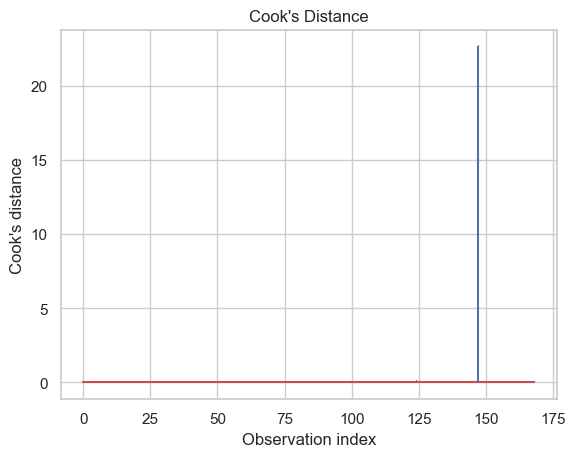

Cook's distance threshold: 0.0237
Number of influential observations: 12


In [101]:
ols_model = sm.OLS(y_train, X_train_red).fit()
influence = OLSInfluence(ols_model)

# Cook's distance
cooks_d = influence.cooks_distance[0]

plt.figure()
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.title("Cook's Distance")
plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.show()

threshold = 4 / len(X_train_red)
print(f"Cook's distance threshold: {threshold:.4f}")

# Identify influential observations
influential_points = np.where(cooks_d > threshold)[0]
print(f"Number of influential observations: {len(influential_points)}")

The Cook’s distance analysis identifies 13 influential observations that have a relatively higher impact on the estimated parameters of the model. These observations likely correspond to competitors with distinctive commercial behaviours or atypical activity levels. Rather than being removed, they are retained in the analysis, as they may represent meaningful business cases within the competitive landscape.

#### 8.4.2. Residual diagnostics

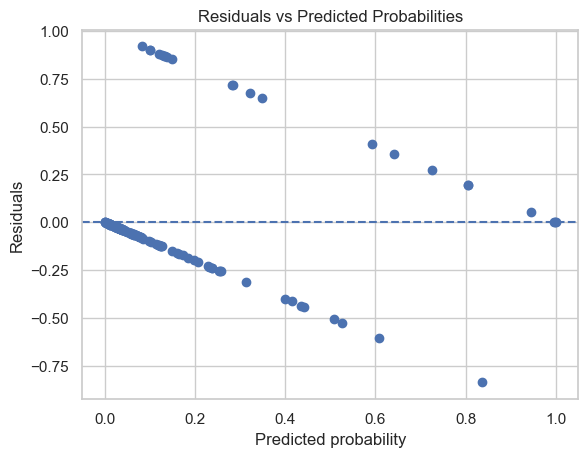

In [102]:
y_pred_prob = logit_reduced.predict(X_train_red)

# Residuals (observed - predicted)
residuals = y_train - y_pred_prob

plt.figure()
plt.scatter(y_pred_prob, residuals)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted Probabilities")
plt.xlabel("Predicted probability")
plt.ylabel("Residuals")
plt.show()

The residual plot shows two distinct bands corresponding to the binary nature of the dependent variable. This is expected in logistic regression, where residuals are separated between positive residuals for observed events (y = 1) and negative residuals for non-events (y = 0). This suggests an adequate model specification.

### 8.4. Predictive Capacity: ROC Curve and Confusion Matrix

With the Reduced Model established as the optimal choice, we use the test data to evaluate its true predictive capacity.  

By plotting the ROC curve and calculating the Area Under the Curve (AUC), we can measure the model's ability to correctly distinguish between emerging threats and stagnant competitors. We also calculate the Confusion Matrix to check how good our predictions are and it helps us assess the sensitivity and specificity of our predictions.

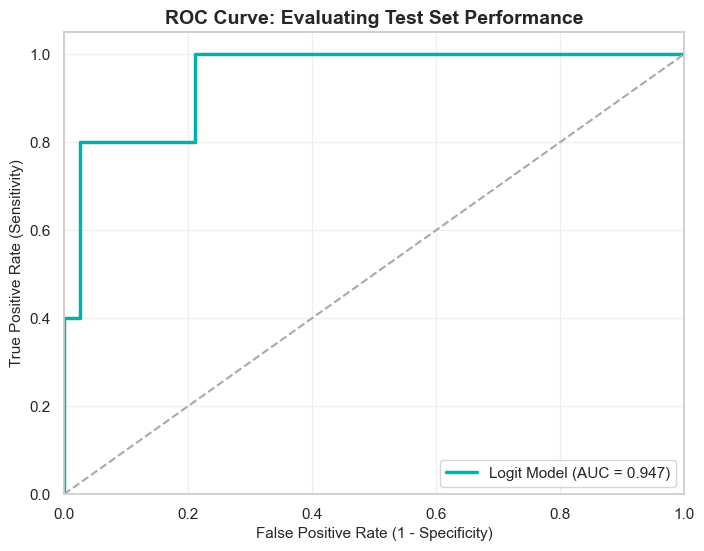

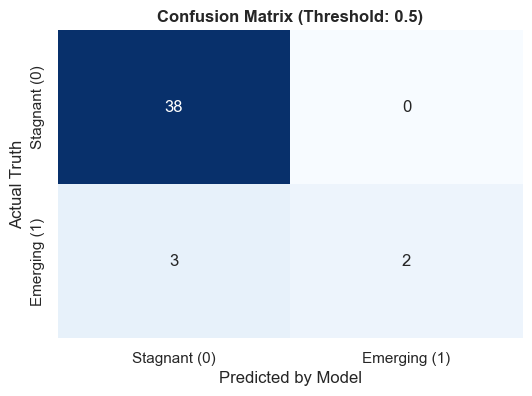


 Classification Report 
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        38
           1       1.00      0.40      0.57         5

    accuracy                           0.93        43
   macro avg       0.96      0.70      0.77        43
weighted avg       0.94      0.93      0.92        43



In [103]:
X_test_red = sm.add_constant(X_test[features_red].copy())

# Predictions
y_pred_prob = logit_reduced.predict(X_test_red)
y_pred_class = (y_pred_prob > 0.5).astype(int)

# ROC and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#00b2a9', lw=2.5, label=f'Logit Model (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='darkgray', linestyle='--', lw=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('ROC Curve: Evaluating Test Set Performance', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stagnant (0)', 'Emerging (1)'],
            yticklabels=['Stagnant (0)', 'Emerging (1)'])
plt.xlabel('Predicted by Model')
plt.ylabel('Actual Truth')
plt.title('Confusion Matrix (Threshold: 0.5)', fontweight='bold')
plt.show()

print("\n Classification Report ")
print(classification_report(y_test, y_pred_class))

**Interpretation of Predictive Performance:**

The Reduced Model archieves an **AUC of 0.942**. This confirms that financial acceleration and market expansion are robust indicators, allowing the model to correctly rank the risk of competitors 94.2% of the time.

Looking at the Confusion Matrix at a standard 0.5 threshold:
* **High Specificity:** The model is highly accurate at identifying stagnant competitors, committing only 1 false positive out of 38 cases. 
* **Imbalanced Target Dynamics:** Out of the 5 true emerging threats in the test set, the model correctly flagged 2 (Recall = 0.40) while maintaining a solid precision (0.67). 

### 8.5. Odds Ratios 

Now we calculate the Odds Ratios ($e^\beta$) of the Reduced Model. This helps us get from looking at statistics to actually making decisions, allowing us to quantify the exact percentage increase in risk associated with each variable.

In [104]:
odds_ratios = pd.DataFrame({
    'Coefficient (Beta)': logit_reduced.params,
    'p-value': logit_reduced.pvalues,
    'Odds Ratio': np.exp(logit_reduced.params)
})

business_view = odds_ratios.drop('const').round(4)
display(business_view)

,Coefficient (Beta),p-value,Odds Ratio
adjusted_trend_slope,0.0000,0.0000,1.0000
expansion_index,0.1711,0.0001,1.1866


The model proves that for every new market segment or division a competitor enters, their risk of becoming an emerging threat increases by 17.14% (p = 0.0004). Additionally, sustained financial acceleration is confirmed as the most critical foundational predictor (p < 0.001), acting as the essential baseline engine that turns a stagnant competitor into a dangerous one.

### 8.6. Emerging Competitor Identification

With the model fully trained and validated, we apply it to the entire Iberia dataset. The goal is to generate a ranked list of predicted emerging threats. This serves as the ultimate validation step, cross-referencing the algorithm's mathematical output with the market reality observed by the business teams.

In [105]:
X_full = df_model_iberia[features_red].copy()
X_full = sm.add_constant(X_full)

# Predict 
df_model_iberia['predicted_risk_prob'] = logit_reduced.predict(X_full)

# Classify them (1 = Emerging, 0 = Stagnant)
df_model_iberia['predicted_class'] = (df_model_iberia['predicted_risk_prob'] > 0.5).astype(int)

# Filter 
emerging_suspects = df_model_iberia[df_model_iberia['predicted_class'] == 1].copy()
emerging_suspects = emerging_suspects.sort_values(by='predicted_risk_prob', ascending=False)

print(f"{len(emerging_suspects)} competitors flagged as Emerging")
display_cols = ['competitor', 'predicted_risk_prob', 'adjusted_trend_slope', 'expansion_index', 'is_emerging']
display(emerging_suspects[display_cols].head(15))

15 competitors flagged as Emerging


,competitor,predicted_risk_prob,adjusted_trend_slope,expansion_index,is_emerging
113,Competitor 397,1.000000,5.290730e+06,6,1
86,Competitor 342,0.998676,1.292737e+06,4,1
16,Competitor 141,0.996943,9.904097e+05,13,1
43,Competitor 232,0.996827,6.594562e+05,28,1
198,Competitor 67,0.944167,5.054861e+05,18,1
11,Competitor 126,0.836609,6.363149e+05,5,0
78,Competitor 325,0.813880,2.900678e+05,20,1
42,Competitor 231,0.805923,2.834973e+05,20,1
105,Competitor 38,0.805336,2.395288e+05,22,1
185,Competitor 57,0.726037,2.046601e+05,21,1
